# Mito Uber

- 78b60b70-129a-4a6d-b15f-825b241eec66.h5ad Tabula Sapiens, **Immune** compartment,
- pnas.1808790115.sd01 SURFI
- MitoCarta

In [1]:
import warnings, time, json, re
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams["figure.dpi"] = 96
sns.set_context("notebook")

RAW   = Path("../data/78b60b70-129a-4a6d-b15f-825b241eec66.h5ad")
MITOX = Path("../data/Human.MitoCarta3.0.xls")
OUT   = Path("out_tabula_mito"); OUT.mkdir(exist_ok=True)

CONFIG = dict(
    target_sum   = 1e4,
    min_cells    = 10,
    chunk        = 15_000,
    assays_keep  = ("10x 3' v3", "10x 5' v2"),          # Smart-seq excluded from the main analysis
    drop_lineages = ("erythrocyte", "erythroid lineage cell",
                     "erythroid progenitor cell", "platelet"),
    lowrna_lineages = ("granulocyte", "neutrophil", "basophil", "mast cell"),
    topN_A = 25,
    topN_B = 25,
    topN_hvg = 40,
    min_organs_for_SD = 3,
)
PATHWAYS = ["OXPHOS", "SLC25A carriers", "Fatty acid oxidation", "Amino acid metabolism",
            "Detoxification", "Calcium homeostasis", "Fusion", "Fission", "Trafficking"]
# display name -> last segment of the MitoCarta hierarchy (sheet C MitoPathways)
PATHWAY_LEAF = {
    "OXPHOS": "OXPHOS",
    "SLC25A carriers": "SLC25A family",
    "Fatty acid oxidation": "Fatty acid oxidation",
    "Amino acid metabolism": "Amino acid metabolism",
    "Detoxification": "Detoxification",
    "Calcium homeostasis": "Calcium homeostasis",
    "Fusion": "Fusion",
    "Fission": "Fission",
    "Trafficking": "Trafficking",
}
print(json.dumps({k:(list(v) if isinstance(v,tuple) else v) for k,v in CONFIG.items()}, indent=1))

{
 "target_sum": 10000.0,
 "min_cells": 10,
 "chunk": 15000,
 "assays_keep": [
  "10x 3' v3",
  "10x 5' v2"
 ],
 "drop_lineages": [
  "erythrocyte",
  "erythroid lineage cell",
  "erythroid progenitor cell",
  "platelet"
 ],
 "lowrna_lineages": [
  "granulocyte",
  "neutrophil",
  "basophil",
  "mast cell"
 ],
 "topN_A": 25,
 "topN_B": 25,
 "topN_hvg": 40,
 "min_organs_for_SD": 3
}


1 · `obs` and `organ × cell type` groups

In [2]:
def _cat(h, key):
    g = h["obs"][key]
    cats = [c.decode() if isinstance(c, bytes) else c for c in g["categories"][:]]
    return pd.Categorical.from_codes(g["codes"][:], cats)

t0 = time.time()
with h5py.File(RAW, "r") as h:
    obs = pd.DataFrame({
        "organ"  : _cat(h, "tissue_in_publication"),
        "lineage": _cat(h, "cell_type"),
        "assay"  : _cat(h, "assay"),
        "donor"  : _cat(h, "donor_id"),
    })
    var_ens  = np.array([x.decode().split(".")[0] for x in h["var/_index"][:]])
    fn = h["var/feature_name"]
    var_sym  = np.array(pd.Categorical.from_codes(fn["codes"][:],
                        [c.decode() for c in fn["categories"][:]]).astype(str))
    var_mt   = h["var/mt"][:].astype(bool) if "mt" in h["var"] else np.zeros(len(var_ens), bool)
    n_cells_total, n_genes_total = h["raw/X"].attrs["shape"]
print(f"obs {obs.shape} loaded in {time.time()-t0:.1f}s · matrix {n_cells_total}x{n_genes_total}")
print(obs["assay"].value_counts().to_string())

obs (592317, 4) loaded in 0.2s · matrix 592317x60606


assay
10x 3' v3     508731
10x 5' v2      61994
Smart-seq2     21570
Smart-seq3        22


In [3]:
# cell mask: 10x assays + drop cell types without mitochondria
keep_assay = obs["assay"].astype(str).isin(CONFIG["assays_keep"]).to_numpy()
keep_lin   = ~obs["lineage"].astype(str).isin(CONFIG["drop_lineages"]).to_numpy()
cell_keep  = keep_assay & keep_lin
print(f"cells: {cell_keep.sum():,} kept / {len(obs):,}  "
      f"(assay-drop {int((~keep_assay).sum()):,} · lineage-drop {int((~keep_lin).sum()):,})")

grp_key = obs["organ"].astype(str) + " | " + obs["lineage"].astype(str)
tmp = obs.assign(_k=grp_key, _keep=cell_keep).query("_keep")
gsz = tmp.groupby("_k", observed=True)
meta = pd.DataFrame({
    "n_cells" : gsz.size(),
    "n_donors": gsz["donor"].nunique(),
    "n_assays": gsz["assay"].nunique(),
}).reset_index().rename(columns={"_k": "group"})
meta[["organ", "lineage"]] = meta["group"].str.split(" | ", n=1, regex=False, expand=True)
meta = meta[meta["n_cells"] >= CONFIG["min_cells"]].reset_index(drop=True)
meta["single_donor"] = meta["n_donors"].eq(1)
meta["single_assay"] = meta["n_assays"].eq(1)
meta["low_rna"]      = meta["lineage"].isin(CONFIG["lowrna_lineages"])
G = len(meta)
gid_of = {g: i for i, g in enumerate(meta["group"])}
group_id = np.full(len(obs), -1, np.int64)
sel = cell_keep & grp_key.isin(set(gid_of)).to_numpy()
group_id[sel] = grp_key[sel].map(gid_of).to_numpy()

print(f"organ x cell-type groups kept: {G}  ·  cells in groups: {(group_id>=0).sum():,}")
print(f"  flag single_donor: {meta.single_donor.sum()}  ·  single_assay: {meta.single_assay.sum()}"
      f"  ·  low_rna: {meta.low_rna.sum()}")
meta.head(8)

cells: 554,908 kept / 592,317  (assay-drop 21,592 · lineage-drop 16,078)


organ x cell-type groups kept: 339  ·  cells in groups: 554,689
  flag single_donor: 18  ·  single_assay: 255  ·  low_rna: 50


,group,n_cells,n_donors,n_assays,organ,lineage,single_donor,single_assay,low_rna
0,Bladder | B cell,449,5,1,Bladder,B cell,False,True,False
1,"Bladder | CD4-positive, alpha-beta T cell",2095,6,1,Bladder,"CD4-positive, alpha-beta T cell",False,True,False
2,"Bladder | CD8-positive, alpha-beta T cell",4409,6,1,Bladder,"CD8-positive, alpha-beta T cell",False,True,False
3,Bladder | T cell,780,6,1,Bladder,T cell,False,True,False
4,Bladder | macrophage,3012,6,1,Bladder,macrophage,False,True,False
5,Bladder | mast cell,1464,6,1,Bladder,mast cell,False,True,True
6,Bladder | mature NK T cell,95,6,1,Bladder,mature NK T cell,False,True,False
7,Bladder | monocyte,4628,6,1,Bladder,monocyte,False,True,False


Tabula dataset

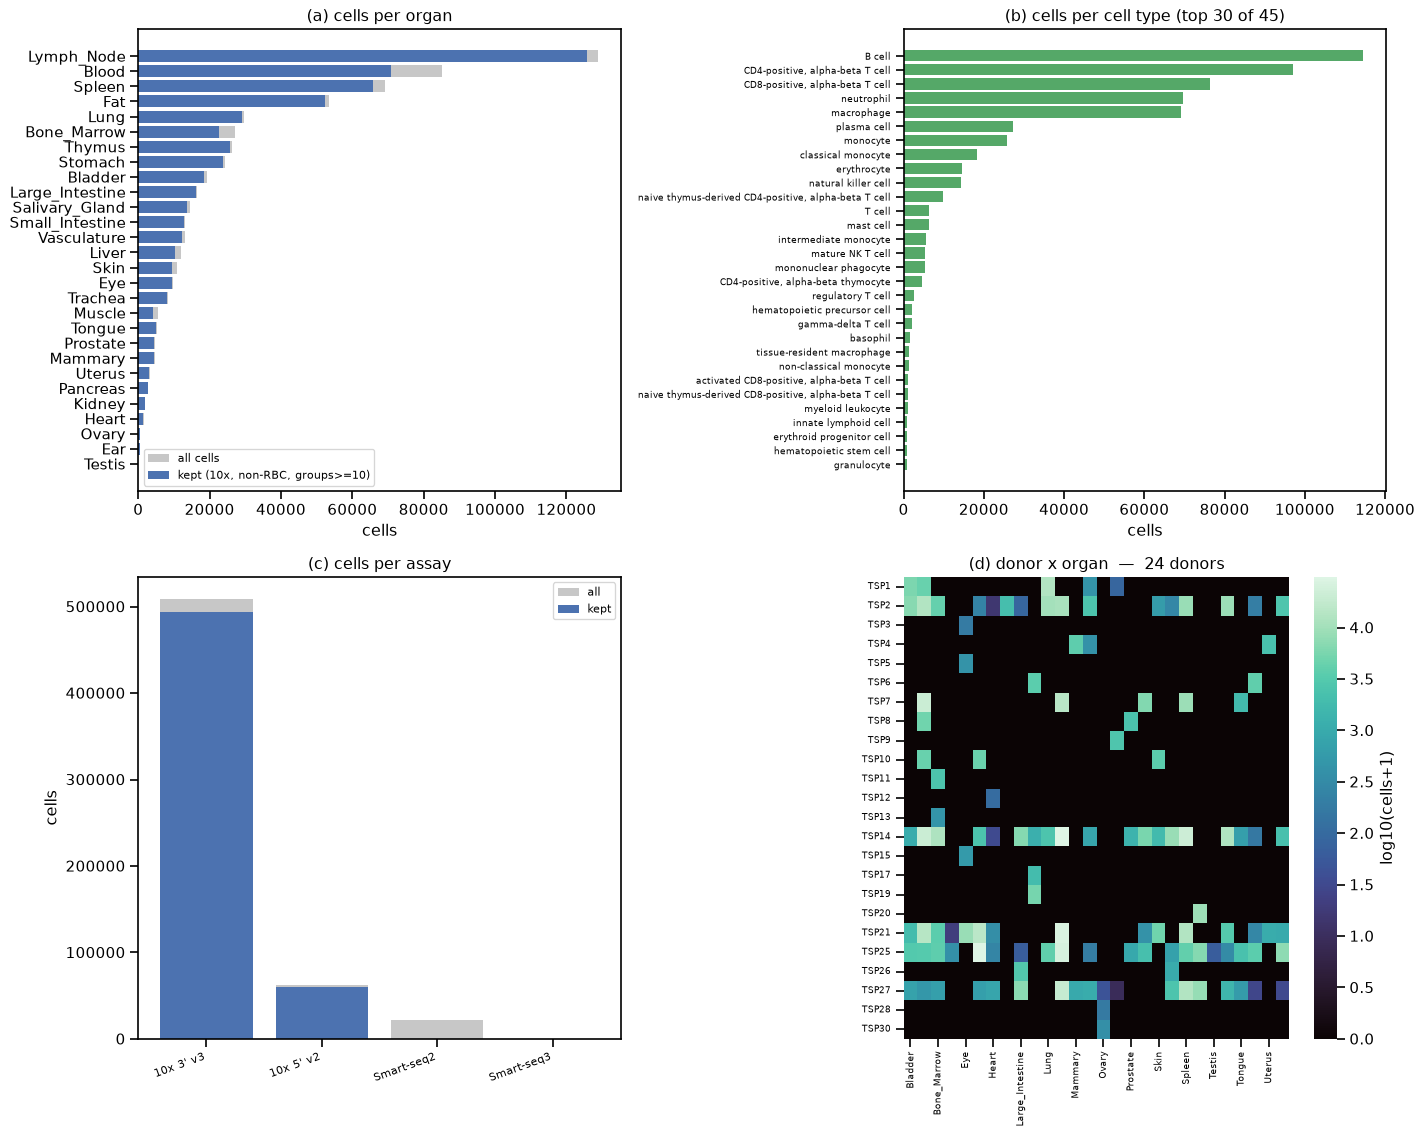

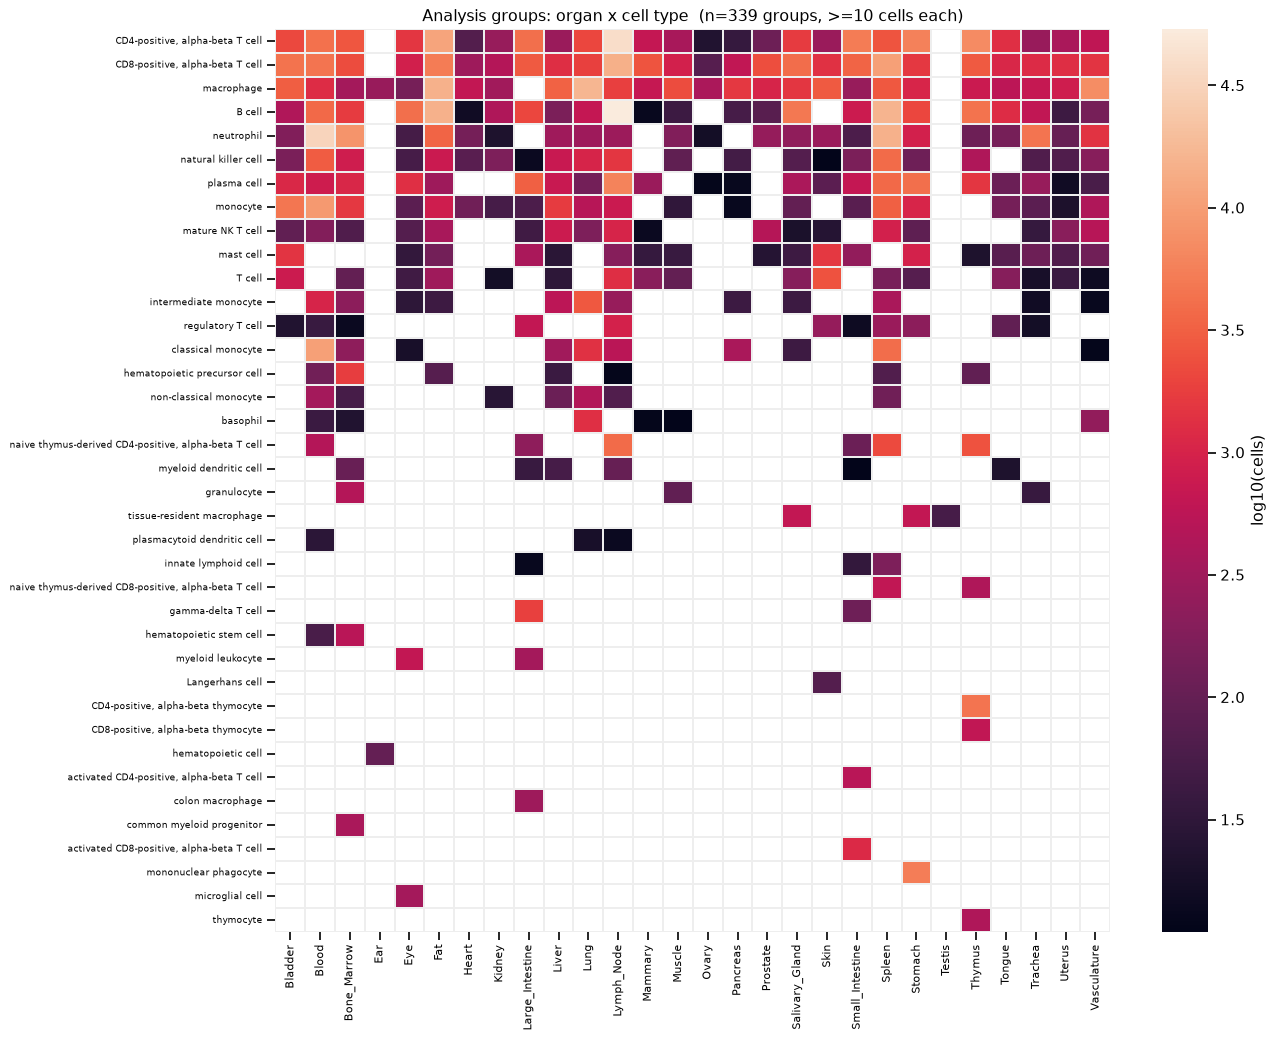

organs: 28 · cell types: 45 · donors: 24 · assays: 4


In [4]:
kept_mask = group_id >= 0
o_all = obs["organ"].value_counts()
o_kept = obs.loc[kept_mask, "organ"].value_counts().reindex(o_all.index).fillna(0)
l_all = obs["lineage"].value_counts()
a_all = obs["assay"].value_counts()

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
# (a) cells per organ, kept vs dropped
ax = axs[0, 0]
ax.barh(o_all.index[::-1], o_all.values[::-1], color="#c7c7c7", label="all cells")
ax.barh(o_kept.index[::-1], o_kept.values[::-1], color="#4C72B0", label="kept (10x, non-RBC, groups>=10)")
ax.set(xlabel="cells", title="(a) cells per organ"); ax.legend(fontsize=8)
# (b) cells per cell type (top 30)
ax = axs[0, 1]
top_l = l_all.head(30)
ax.barh(top_l.index[::-1], top_l.values[::-1], color="#55A868")
ax.set(xlabel="cells", title="(b) cells per cell type (top 30 of %d)" % l_all.size)
ax.tick_params(axis="y", labelsize=7)
# (c) cells per assay
ax = axs[1, 0]
kept_assay_ct = obs.loc[kept_mask, "assay"].value_counts().reindex(a_all.index).fillna(0)
ax.bar(range(a_all.size), a_all.values, color="#c7c7c7", label="all")
ax.bar(range(a_all.size), kept_assay_ct.values, color="#4C72B0", label="kept")
ax.set_xticks(range(a_all.size)); ax.set_xticklabels(a_all.index, rotation=20, ha="right", fontsize=8)
ax.set(ylabel="cells", title="(c) cells per assay"); ax.legend(fontsize=8)
# (d) donor x organ cell counts (log)
ax = axs[1, 1]
do = obs.groupby(["donor", "organ"], observed=True).size().unstack(fill_value=0)
sns.heatmap(np.log10(do + 1), cmap="mako", ax=ax, cbar_kws={"label": "log10(cells+1)"})
ax.set(title="(d) donor x organ  —  %d donors" % do.shape[0], xlabel="", ylabel="")
ax.tick_params(axis="x", labelsize=7); ax.tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.savefig(OUT / "S1_tabula_overview.png", dpi=150); plt.show()

# organ x cell-type matrix of the 339 analysis groups (cell counts, log)
mat = meta.pivot_table(index="lineage", columns="organ", values="n_cells", aggfunc="sum")
mat = mat.loc[mat.notna().sum(1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(np.log10(mat), cmap="rocket", ax=ax,
            cbar_kws={"label": "log10(cells)"}, linewidths=.3, linecolor="#eee")
ax.set(title="Analysis groups: organ x cell type  (n=%d groups, >=10 cells each)" % len(meta),
       xlabel="", ylabel="")
ax.tick_params(axis="x", labelsize=8, rotation=90); ax.tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.savefig(OUT / "S1b_group_matrix.png", dpi=150); plt.show()
print(f"organs: {obs['organ'].nunique()} · cell types: {obs['lineage'].nunique()} · "
      f"donors: {obs['donor'].nunique()} · assays: {obs['assay'].nunique()}")

2 · MitoCarta 3.0 genes and pathways

In [5]:
mc = pd.read_excel(MITOX, sheet_name="A Human MitoCarta3.0")
mito_sym = set(mc["Symbol"].astype(str))
mito_ens = set()
for v in mc["EnsemblGeneID_mapping_version_20200130"].astype(str):
    for p in v.replace(" ", "").split("|"):
        if p.startswith("ENSG"):
            mito_ens.add(p.split(".")[0])

in_mito = np.isin(var_sym, list(mito_sym)) | np.isin(var_ens, list(mito_ens))
mito_pos = np.where(in_mito)[0]                       # column positions in the full matrix
P = len(mito_pos)
mito_sym_kept = var_sym[mito_pos]
sym2local = {}
for j, s in enumerate(mito_sym_kept):
    sym2local.setdefault(s, j)                        # first occurrence
print(f"MitoCarta genes mapped in the matrix: {P}  (MitoCarta3.0 = {len(mc)})")

# --- sheet C MitoPathways: hierarchy + gene list per leaf node ---
cmp_ = pd.read_excel(MITOX, sheet_name="C MitoPathways", header=None).iloc[1:]
leaf2genes = {}
for _, r in cmp_.iterrows():
    hier, genes = str(r[2]), str(r[3])
    leaf = hier.split(">")[-1].strip()
    gl = [g.strip() for g in genes.split(",") if g.strip() and g != "nan"]
    if gl:
        leaf2genes[leaf] = gl

pathway_local = {}     # pathway -> array of local indices (0..P-1) of the measured genes
pathway_symbols = {}
for name in PATHWAYS:
    leaf = PATHWAY_LEAF[name]
    assert leaf in leaf2genes, f"node '{leaf}' not found in sheet C MitoPathways"
    syms = leaf2genes[leaf]
    loc = sorted({sym2local[s] for s in syms if s in sym2local})
    pathway_local[name] = np.array(loc, dtype=int)
    pathway_symbols[name] = [s for s in syms if s in sym2local]

# OXPHOS variant without the mtDNA-encoded genes (MT-*)
mt_local = {j for j, p in enumerate(mito_pos) if var_mt[p]}
pathway_local["OXPHOS (no MT-)"] = np.array(sorted(set(pathway_local["OXPHOS"].tolist()) - mt_local), dtype=int)

cov = pd.DataFrame({
    "pathway": PATHWAYS + ["OXPHOS (no MT-)"],
    "n_genes_mitocarta": [len(leaf2genes[PATHWAY_LEAF[n]]) for n in PATHWAYS] + [np.nan],
    "n_genes_measured":  [len(pathway_local[n]) for n in PATHWAYS] + [len(pathway_local["OXPHOS (no MT-)"])],
})
cov.to_csv(OUT / "pathway_coverage.csv", index=False)

# overlap between pathways (shared genes)
ov = pd.DataFrame(
    np.array([[len(set(pathway_local[a]).intersection(pathway_local[b]))
               for b in PATHWAYS] for a in PATHWAYS], dtype=int),
    index=PATHWAYS, columns=PATHWAYS)
print(cov.to_string(index=False))
print("\nshared genes between pathways:\n", ov.to_string())
gene2path = {}
for name in PATHWAYS:
    for s in pathway_symbols[name]:
        gene2path.setdefault(s, []).append(name)

MitoCarta genes mapped in the matrix: 1138  (MitoCarta3.0 = 1136)


              pathway  n_genes_mitocarta  n_genes_measured
               OXPHOS              169.0               167
      SLC25A carriers               51.0                51
 Fatty acid oxidation               44.0                44
Amino acid metabolism               90.0                90
       Detoxification               51.0                51
  Calcium homeostasis               24.0                24
               Fusion                9.0                 9
              Fission               15.0                15
          Trafficking                7.0                 7
      OXPHOS (no MT-)                NaN               154

shared genes between pathways:
                        OXPHOS  SLC25A carriers  Fatty acid oxidation  Amino acid metabolism  Detoxification  Calcium homeostasis  Fusion  Fission  Trafficking
OXPHOS                    167                0                     0                      0               0                    0       0        0            0


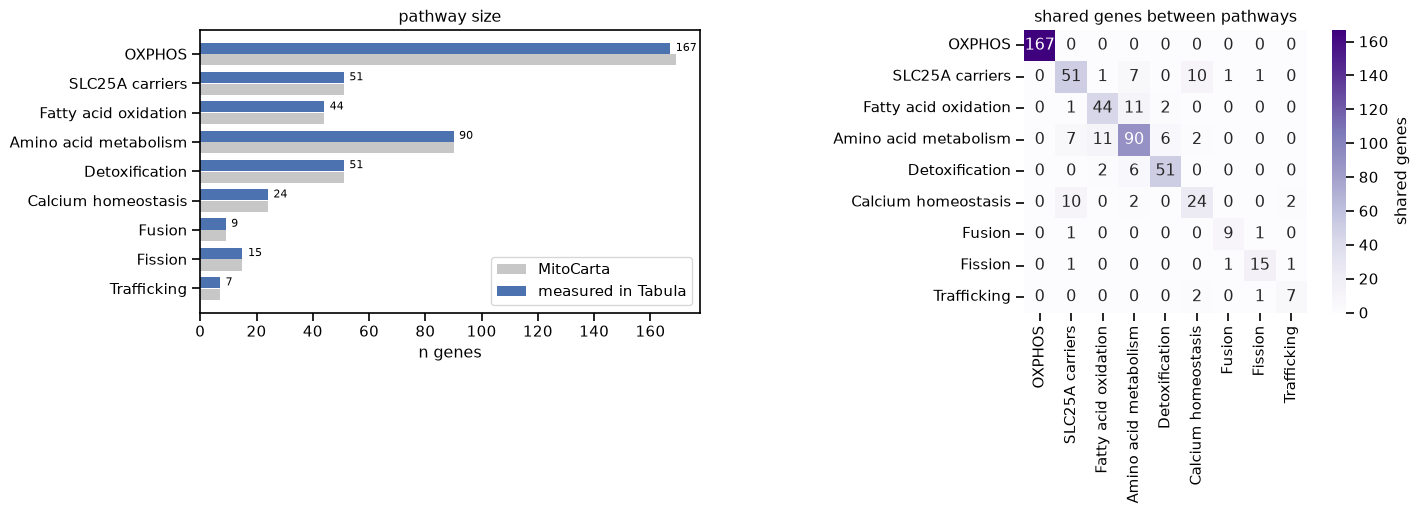

In [6]:
# pathway sizes (MitoCarta vs measured) and gene overlap between the 9 pathways
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5))
cc = cov[cov["pathway"].isin(PATHWAYS)].set_index("pathway")
ax = axs[0]
y = np.arange(len(cc))
ax.barh(y + .2, cc["n_genes_mitocarta"], height=.38, color="#c7c7c7", label="MitoCarta")
ax.barh(y - .2, cc["n_genes_measured"], height=.38, color="#4C72B0", label="measured in Tabula")
ax.set_yticks(y); ax.set_yticklabels(cc.index); ax.invert_yaxis()
ax.set(xlabel="n genes", title="pathway size"); ax.legend()
for i, (m, me) in enumerate(zip(cc["n_genes_mitocarta"], cc["n_genes_measured"])):
    ax.text(me + 2, i - .2, int(me), va="center", fontsize=8)
sns.heatmap(ov, annot=True, fmt="d", cmap="Purples", square=True, ax=axs[1],
            cbar_kws={"label": "shared genes"})
axs[1].set_title("shared genes between pathways")
plt.tight_layout(); plt.savefig(OUT / "S2_pathway_sizes_overlap.png", dpi=150); plt.show()

3 ·Streaming pass over the raw counts

In [7]:
donor_code = obs["donor"].cat.codes.to_numpy()          # 0..n_donors-1
donor_names = list(obs["donor"].cat.categories)
D = len(donor_names)

npz_path = OUT / "stream_accum.npz"
FORCE = False
_need = ("sum_log", "n_by_grp", "sum_raw", "tot_by_grp", "sum_raw_donor", "tot_by_donor", "n_by_donor")
if npz_path.exists() and not FORCE and all(k in np.load(npz_path, allow_pickle=True) for k in _need):
    z = np.load(npz_path, allow_pickle=True)
    sum_log, n_by_grp, sum_raw, tot_by_grp = z["sum_log"], z["n_by_grp"], z["sum_raw"], z["tot_by_grp"]
    sum_raw_donor, tot_by_donor, n_by_donor = z["sum_raw_donor"], z["tot_by_donor"], z["n_by_donor"]
    print("loaded from cache:", npz_path.name)
else:
    sum_log    = np.zeros((G, P), np.float64)
    sum_raw    = np.zeros((G, P), np.float64)
    tot_by_grp = np.zeros(G, np.float64)
    n_by_grp   = np.zeros(G, np.int64)
    sum_raw_donor = np.zeros((D, P), np.float64)         # donor-level pseudobulk (kept cells only)
    tot_by_donor  = np.zeros(D, np.float64)
    n_by_donor    = np.zeros(D, np.int64)
    CH = CONFIG["chunk"]; ts = CONFIG["target_sum"]
    with h5py.File(RAW, "r") as h:
        Xg = h["raw/X"]; indptr = Xg["indptr"]; data_ds = Xg["data"]; idx_ds = Xg["indices"]
        ncol = Xg.attrs["shape"][1]
        t0 = time.time()
        for a in range(0, n_cells_total, CH):
            b = min(a + CH, n_cells_total)
            gids = group_id[a:b]
            if (gids >= 0).sum() == 0:
                continue
            ip = indptr[a:b + 1].astype(np.int64); s, e = int(ip[0]), int(ip[-1])
            X = sp.csr_matrix((data_ds[s:e], idx_ds[s:e], ip - s), shape=(b - a, ncol))
            tot = np.asarray(X.sum(1)).ravel()
            v = (gids >= 0) & (tot > 0)
            gi = gids[v]
            di = donor_code[a:b][v]
            Xm = X[v][:, mito_pos].toarray().astype(np.float64)     # (nv, P) raw counts
            Xl = np.log1p(Xm * (ts / tot[v, None]))                 # (nv, P) normalized log1p
            np.add.at(sum_log,       gi, Xl)
            np.add.at(sum_raw,       gi, Xm)
            np.add.at(tot_by_grp,    gi, tot[v])
            np.add.at(n_by_grp,      gi, 1)
            np.add.at(sum_raw_donor, di, Xm)
            np.add.at(tot_by_donor,  di, tot[v])
            np.add.at(n_by_donor,    di, 1)
            if (a // CH) % 5 == 0:
                print(f"  {b:>7,}/{n_cells_total:,}  ({time.time()-t0:5.1f}s)")
    np.savez_compressed(npz_path, sum_log=sum_log, n_by_grp=n_by_grp,
                        sum_raw=sum_raw, tot_by_grp=tot_by_grp,
                        sum_raw_donor=sum_raw_donor, tot_by_donor=tot_by_donor, n_by_donor=n_by_donor)
    print("saved:", npz_path.name)

assert (n_by_grp == meta["n_cells"].to_numpy()).all(), "per-group cell count is inconsistent"
print(f"donor-level pseudobulk: {int((n_by_donor > 0).sum())} donors, "
      f"{int(n_by_donor.sum()):,} cells")

loaded from cache: stream_accum.npz
donor-level pseudobulk: 23 donors, 554,689 cells


In [8]:
# mean log1p matrix per group  [G x P]
grp_mean = pd.DataFrame(sum_log / n_by_grp[:, None], index=meta["group"], columns=mito_sym_kept)
grp_mean.to_csv(OUT / "A_group_mean_log1p.csv")
print("grp_mean:", grp_mean.shape)
grp_mean.iloc[:4, :5]

grp_mean: (339, 1138)


,BAD,LAP3,NDUFAF7,ARF5,POLDIP2
group,,,,,
Bladder | B cell,0.077030,0.253564,0.119486,0.135344,0.090162
"Bladder | CD4-positive, alpha-beta T cell",0.099576,0.201060,0.182851,0.206011,0.070327
"Bladder | CD8-positive, alpha-beta T cell",0.077798,0.203795,0.198921,0.166153,0.064780
Bladder | T cell,0.080042,0.185963,0.148654,0.164445,0.062638


4 ·Pathway scoring (size-corrected)

 z-score each gene across the profiles, then for each pathway take the
**mean** of the z-scores of its genes (equal weight ⇒ pathways comparable). `overall` = sum of the 9 scores. `*_rawsum` = sum of the raw log1p values (no correction) for comparison.

In [9]:
def score_pathways(mat, pathway_local, pathways):
    # mat: DataFrame [profiles x genes] (mean log1p). Returns (z_scores_df, rawsum_df).
    X = mat.to_numpy()
    mu, sd = X.mean(0), X.std(0)
    sd[sd == 0] = 1.0
    Z = (X - mu) / sd
    zsc, rsc = {}, {}
    for p in pathways:
        loc = pathway_local[p]
        zsc[p] = Z[:, loc].mean(1)
        rsc[p] = X[:, loc].sum(1)
    zdf = pd.DataFrame(zsc, index=mat.index)
    zdf["overall"] = zdf[pathways].sum(1)
    rdf = pd.DataFrame(rsc, index=mat.index).add_suffix("_rawsum")
    rdf["overall_rawsum"] = rdf.sum(1)
    return zdf, rdf

scoreA, scoreA_raw = score_pathways(grp_mean, pathway_local, PATHWAYS)
scoreA_full = meta.set_index("group").join(scoreA).join(scoreA_raw)
scoreA_full.to_csv(OUT / "A_pathway_scores_by_group.csv")
scoreA_full[["organ","lineage","n_cells","n_donors"] + PATHWAYS + ["overall"]].head(6)

,organ,lineage,n_cells,n_donors,OXPHOS,SLC25A carriers,Fatty acid oxidation,Amino acid metabolism,Detoxification,Calcium homeostasis,Fusion,Fission,Trafficking,overall
group,,,,,,,,,,,,,,
Bladder | B cell,Bladder,B cell,449,5,-0.085855,0.110544,-0.294365,-0.097332,-0.134094,0.227316,0.206944,0.055039,-0.292901,-0.304704
"Bladder | CD4-positive, alpha-beta T cell",Bladder,"CD4-positive, alpha-beta T cell",2095,6,0.057842,-0.090084,-0.221893,-0.033556,-0.103398,-0.023157,-0.125876,-0.046818,-0.343481,-0.930421
"Bladder | CD8-positive, alpha-beta T cell",Bladder,"CD8-positive, alpha-beta T cell",4409,6,-0.167772,-0.141012,-0.320824,-0.137977,-0.142144,-0.165458,-0.241662,-0.123915,-0.289406,-1.730171
Bladder | T cell,Bladder,T cell,780,6,-0.119016,-0.135608,-0.396152,-0.164728,-0.188262,-0.089415,-0.206897,-0.233768,-0.412820,-1.946665
Bladder | macrophage,Bladder,macrophage,3012,6,-0.432532,-0.008257,-0.150884,0.005681,0.103622,-0.092230,-0.221670,-0.283784,0.471915,-0.608140
Bladder | mast cell,Bladder,mast cell,1464,6,-0.026424,-0.367418,-0.481548,-0.279182,0.062545,-0.363561,-0.312596,-0.315793,-0.052444,-2.136421


A `organ × cell type` groups kept separate

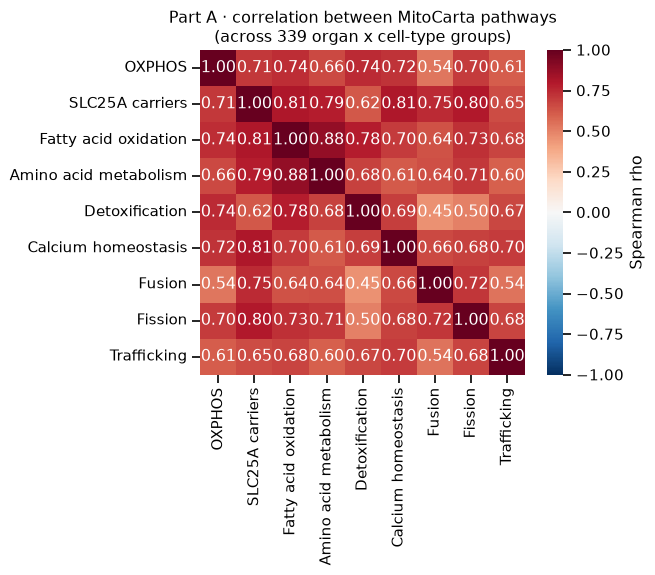

In [10]:
# A1 · correlation between the 9 pathways (across organ x cell-type groups)
corrA = scoreA[PATHWAYS].corr(method="spearman")
corrA.to_csv(OUT / "A1_pathway_correlation.csv")
fig, ax = plt.subplots(figsize=(7.2, 6))
sns.heatmap(corrA, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Part A · correlation between MitoCarta pathways\n(across %d organ x cell-type groups)" % len(scoreA))
plt.tight_layout(); plt.savefig(OUT / "A1_pathway_correlation.png", dpi=150); plt.show()

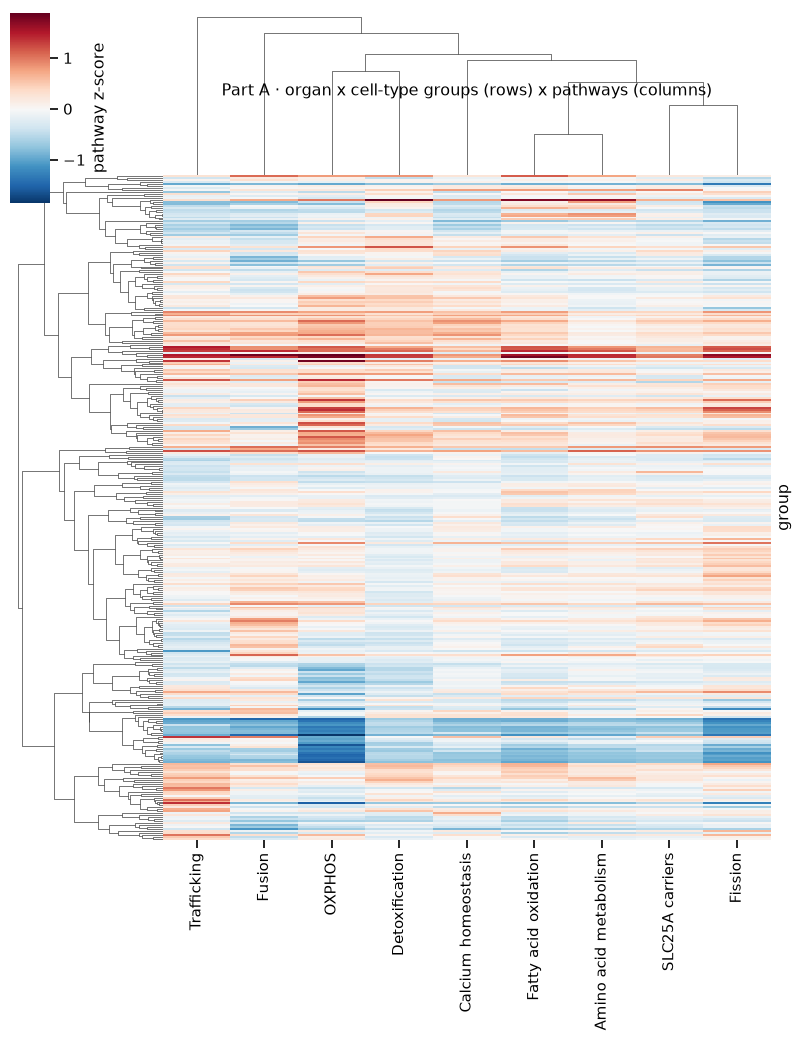

In [11]:
# A1b · group x group similarity (clustermap on the 9 z-scores)
cg = sns.clustermap(scoreA[PATHWAYS], cmap="RdBu_r", center=0, figsize=(8.5, 11),
                    metric="correlation", method="average",
                    yticklabels=(len(scoreA) <= 80), xticklabels=True,
                    cbar_kws={"label": "pathway z-score"})
cg.ax_heatmap.set_title("Part A · organ x cell-type groups (rows) x pathways (columns)", pad=60)
cg.savefig(OUT / "A1b_group_clustermap.png", dpi=150); plt.show()

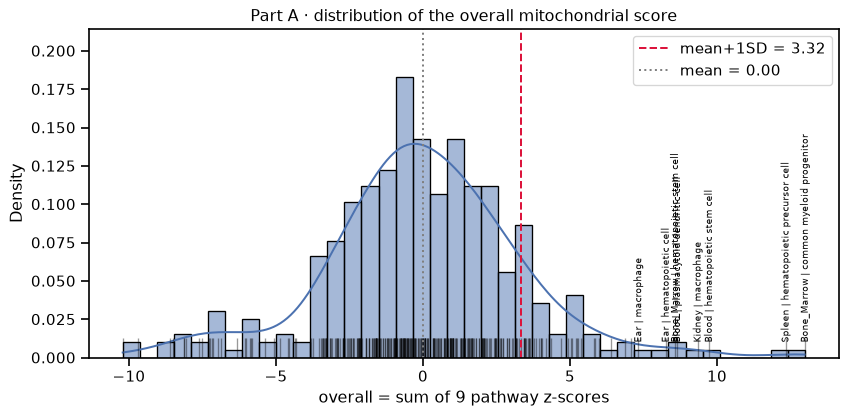

groups above mean+1SD: 44 / 339


In [12]:
# A2 · distribution of the 'overall' score — where to cut?
ov = scoreA["overall"]
cut = ov.mean() + ov.std()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(ov, bins=40, kde=True, stat="density", color="#4C72B0", ax=ax)
sns.rugplot(ov, height=0.06, color="k", alpha=.4, ax=ax)
ax.axvline(cut, color="crimson", ls="--", label=f"mean+1SD = {cut:.2f}")
ax.axvline(ov.mean(), color="grey", ls=":", label=f"mean = {ov.mean():.2f}")
for g in ov.nlargest(8).index:
    ax.annotate(g, (ov[g], 0.01), rotation=90, fontsize=7, ha="center", va="bottom")
ax.set(xlabel="overall = sum of 9 pathway z-scores", title="Part A · distribution of the overall mitochondrial score")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "A2_overall_distribution.png", dpi=150); plt.show()
print(f"groups above mean+1SD: {(ov > cut).sum()} / {len(ov)}")

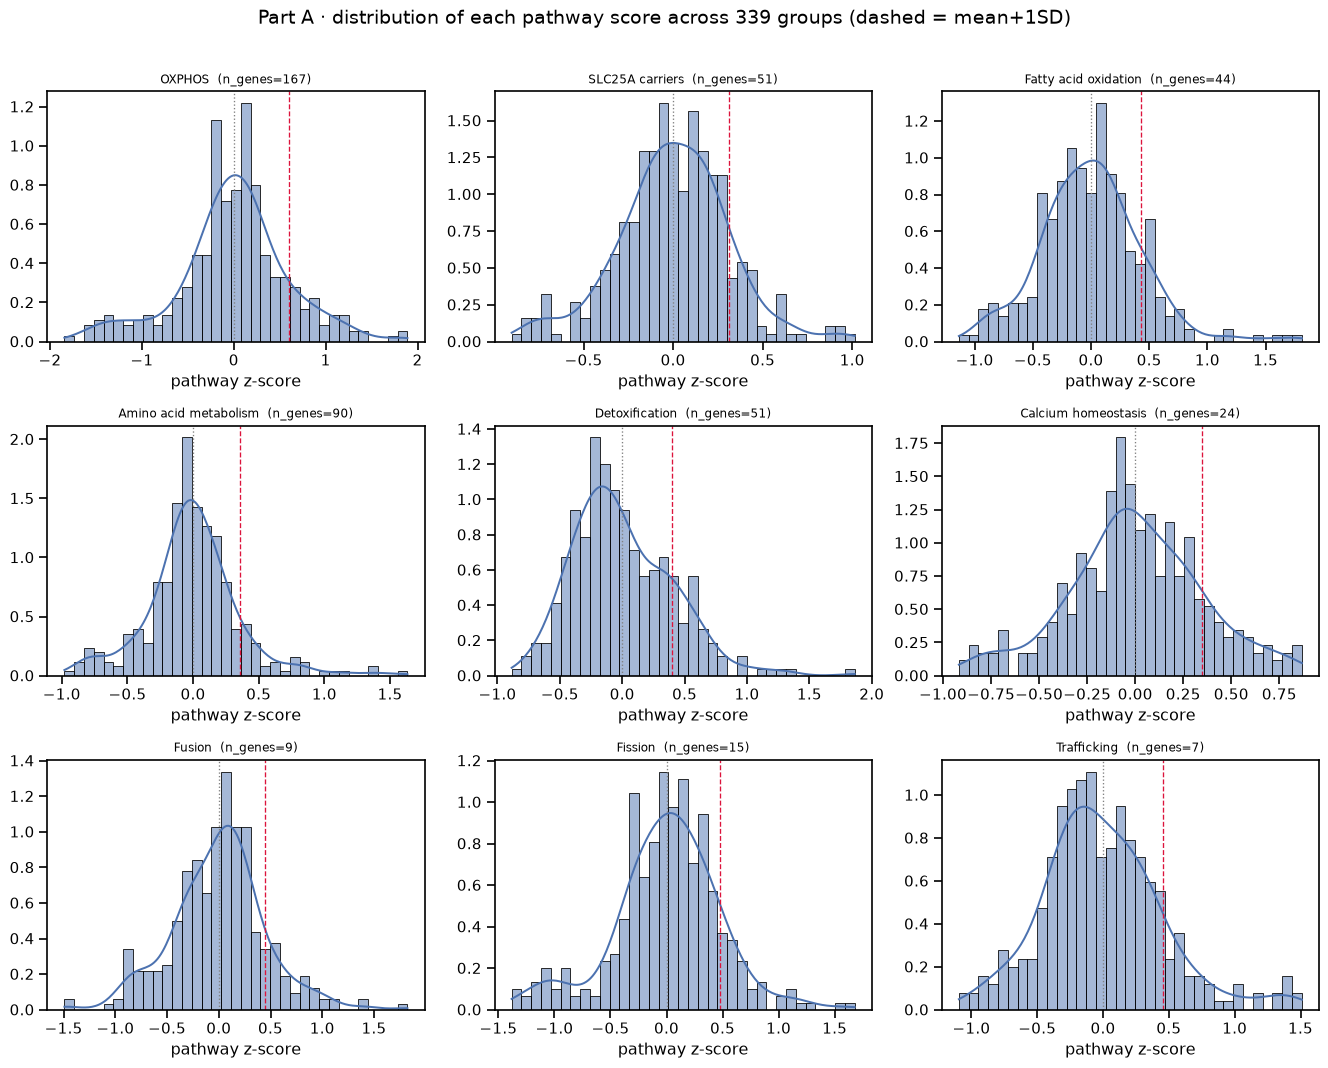

In [13]:
# A2b · per-pathway score distributions across the organ x cell-type groups (3x3)
fig, axs = plt.subplots(3, 3, figsize=(14, 11), sharex=False)
for ax, p in zip(axs.ravel(), PATHWAYS):
    s = scoreA[p]
    sns.histplot(s, bins=35, kde=True, stat="density", color="#4C72B0", ax=ax)
    ax.axvline(s.mean() + s.std(), color="crimson", ls="--", lw=1)
    ax.axvline(s.mean(), color="grey", ls=":", lw=1)
    ax.set_title(f"{p}  (n_genes={len(pathway_local[p])})", fontsize=9)
    ax.set_xlabel("pathway z-score"); ax.set_ylabel("")
fig.suptitle("Part A · distribution of each pathway score across %d groups "
             "(dashed = mean+1SD)" % len(scoreA), y=1.01)
plt.tight_layout(); plt.savefig(OUT / "A2b_pathway_distributions.png", dpi=150); plt.show()

In [14]:
# A3 · TOP 25 organ x cell-type groups by 'overall' score
cols = ["organ","lineage","n_cells","n_donors","n_assays",
        "single_donor","single_assay","low_rna"] + PATHWAYS + ["overall"]
topA = scoreA_full.sort_values("overall", ascending=False).head(CONFIG["topN_A"])[cols].round(3)
topA.to_csv(OUT / "A3_top25_groups.csv")
topA

,organ,lineage,n_cells,n_donors,n_assays,single_donor,single_assay,low_rna,OXPHOS,SLC25A carriers,Fatty acid oxidation,Amino acid metabolism,Detoxification,Calcium homeostasis,Fusion,Fission,Trafficking,overall
group,,,,,,,,,,,,,,,,,,
Bone_Marrow | common myeloid progenitor,Bone_Marrow,common myeloid progenitor,388,6,2,False,False,False,1.890,0.958,1.575,1.401,1.321,0.833,1.823,1.678,1.510,12.990
Spleen | hematopoietic precursor cell,Spleen,hematopoietic precursor cell,68,5,2,False,False,False,1.771,1.014,1.812,1.388,1.297,0.708,1.411,1.513,1.419,12.334
Blood | hematopoietic stem cell,Blood,hematopoietic stem cell,57,6,2,False,False,False,1.038,0.626,1.407,1.166,1.083,0.624,1.390,1.093,1.297,9.726
Kidney | macrophage,Kidney,macrophage,331,1,1,True,True,False,1.003,0.692,1.726,1.633,1.863,0.825,0.709,0.554,0.341,9.345
Blood | plasmacytoid dendritic cell,Blood,plasmacytoid dendritic cell,29,6,1,False,True,False,1.163,0.663,1.184,0.827,0.714,0.581,0.874,1.147,1.489,8.642
Bone_Marrow | hematopoietic stem cell,Bone_Marrow,hematopoietic stem cell,530,6,2,False,False,False,1.032,0.594,1.152,0.981,0.956,0.381,0.863,1.225,1.389,8.574
Ear | hematopoietic cell,Ear,hematopoietic cell,100,2,1,False,True,False,1.178,0.853,0.598,1.109,0.652,0.766,1.052,0.844,1.208,8.260
Ear | macrophage,Ear,macrophage,276,2,1,False,True,False,1.401,0.422,0.504,0.607,0.997,0.720,0.781,0.712,1.179,7.326
Pancreas | monocyte,Pancreas,monocyte,13,2,1,False,True,False,1.811,0.384,0.871,0.545,0.969,0.692,0.103,0.349,1.340,7.064


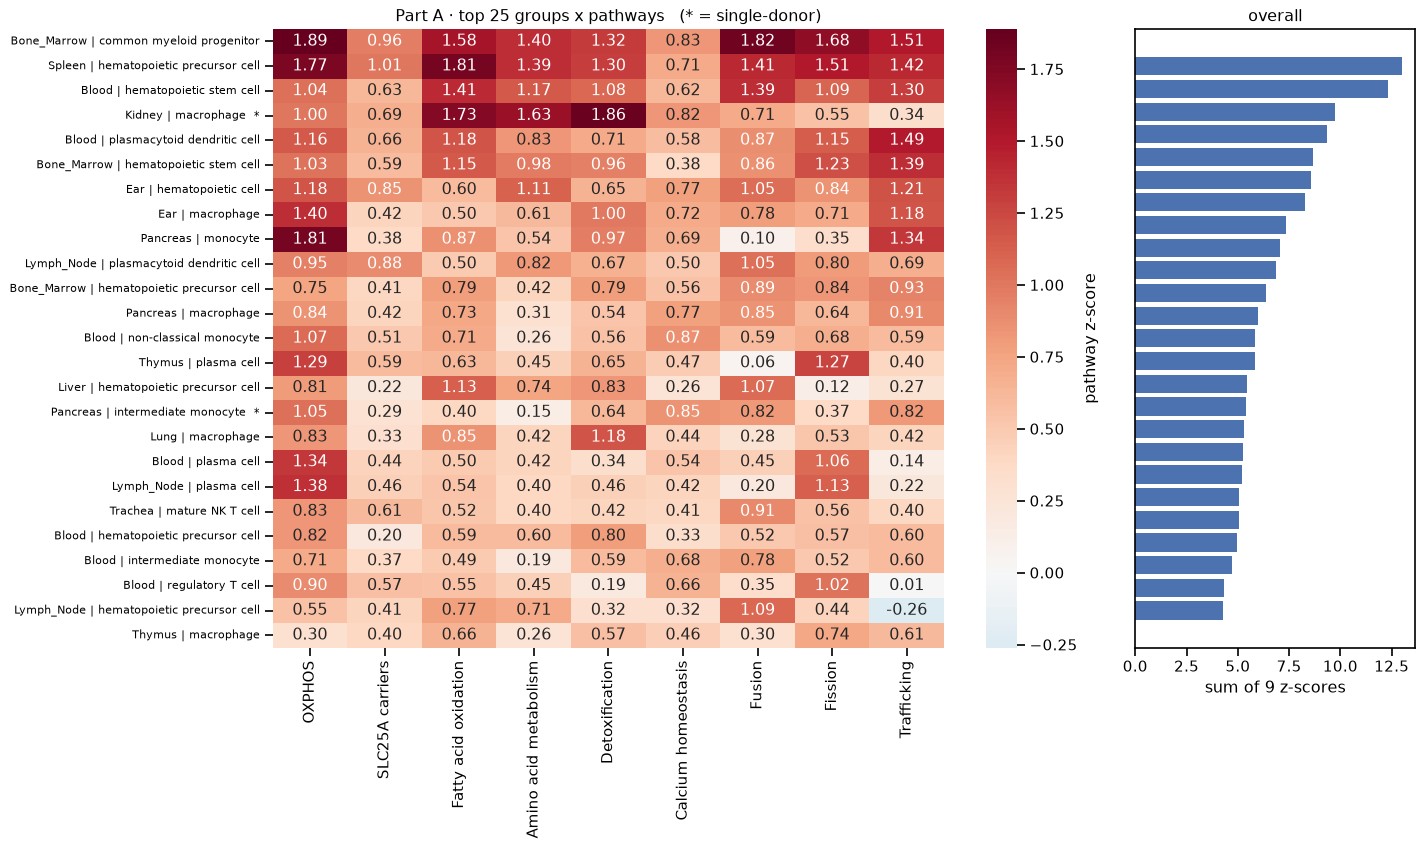

In [15]:
# A3b · heatmap of the TOP 25 groups x 9 pathways (z-scores) + overall bar
tt = scoreA_full.sort_values("overall", ascending=False).head(CONFIG["topN_A"])
lab = [f"{r.organ} | {r.lineage}" + ("  *" if r.single_donor else "") for r in tt.itertuples()]
fig, axs = plt.subplots(1, 2, figsize=(15, 9), gridspec_kw={"width_ratios": [3, 1]})
sns.heatmap(tt[PATHWAYS].set_axis(lab), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axs[0], cbar_kws={"label": "pathway z-score"})
axs[0].set_title("Part A · top %d groups x pathways   (* = single-donor)" % CONFIG["topN_A"])
axs[0].set_ylabel(""); axs[0].tick_params(axis="y", labelsize=8)
axs[1].barh(range(len(tt))[::-1], tt["overall"].values, color="#4C72B0")
axs[1].set_yticks([]); axs[1].set_title("overall"); axs[1].set_xlabel("sum of 9 z-scores")
plt.tight_layout(); plt.savefig(OUT / "A3b_top25_heatmap.png", dpi=150); plt.show()

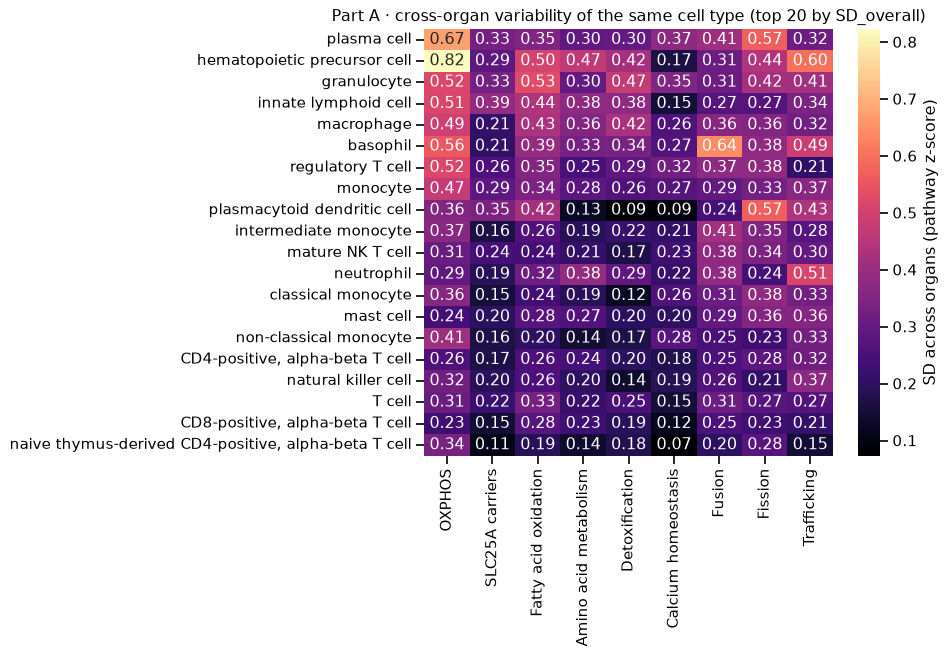

,lineage,n_organs,n_cells_tot,mean_overall,SD_overall,SD_OXPHOS,SD_SLC25A carriers,SD_Fatty acid oxidation,SD_Amino acid metabolism,SD_Detoxification,SD_Calcium homeostasis,SD_Fusion,SD_Fission,SD_Trafficking
0,plasma cell,22,25838,-0.728,3.458,0.674,0.331,0.351,0.295,0.298,0.374,0.406,0.571,0.318
1,hematopoietic precursor cell,7,2138,5.783,3.090,0.823,0.288,0.504,0.465,0.418,0.165,0.314,0.440,0.598
2,granulocyte,3,606,-3.575,2.948,0.518,0.330,0.528,0.298,0.473,0.349,0.315,0.416,0.412
3,innate lymphoid cell,3,212,-0.268,2.881,0.513,0.385,0.435,0.378,0.377,0.151,0.272,0.270,0.341
4,macrophage,26,66592,2.579,2.763,0.491,0.212,0.430,0.360,0.424,0.259,0.363,0.358,0.324
5,basophil,6,1639,-1.264,2.652,0.559,0.207,0.391,0.328,0.336,0.266,0.641,0.380,0.485
6,regulatory T cell,11,2562,0.792,2.566,0.518,0.256,0.355,0.250,0.289,0.324,0.375,0.379,0.209
7,monocyte,21,24363,0.859,2.555,0.474,0.290,0.344,0.281,0.262,0.270,0.294,0.326,0.367
8,plasmacytoid dendritic cell,3,62,6.518,2.319,0.356,0.345,0.418,0.127,0.087,0.092,0.244,0.569,0.434
9,intermediate monocyte,12,5448,1.951,2.181,0.367,0.164,0.263,0.191,0.218,0.210,0.410,0.349,0.275


In [16]:
# A4 · how much does THE SAME CELL TYPE vary from organ to organ
rows = []
for lin, sub in scoreA_full.groupby("lineage"):
    if sub["organ"].nunique() < CONFIG["min_organs_for_SD"]:
        continue
    r = {"lineage": lin, "n_organs": sub["organ"].nunique(), "n_cells_tot": int(sub["n_cells"].sum()),
         "organs": ", ".join(sorted(sub["organ"])), "SD_overall": sub["overall"].std()}
    for p in PATHWAYS:
        r[f"SD_{p}"] = sub[p].std()
    r["mean_overall"] = sub["overall"].mean()
    rows.append(r)
crossSD = pd.DataFrame(rows).sort_values("SD_overall", ascending=False).reset_index(drop=True)
crossSD.to_csv(OUT / "A4_crossorgan_SD_by_lineage.csv", index=False)

sd_cols = [f"SD_{p}" for p in PATHWAYS]
plot_df = crossSD.head(20).set_index("lineage")[sd_cols].rename(columns=lambda c: c[3:])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(plot_df, annot=True, fmt=".2f", cmap="magma", cbar_kws={"label": "SD across organs (pathway z-score)"}, ax=ax)
ax.set_title("Part A · cross-organ variability of the same cell type (top 20 by SD_overall)")
ax.set_ylabel(""); plt.tight_layout(); plt.savefig(OUT / "A4_crossorgan_SD.png", dpi=150); plt.show()
crossSD[["lineage","n_organs","n_cells_tot","mean_overall","SD_overall"] + sd_cols].round(3).head(20)

PART B pseudobulk collapsed **per cell type** (across organs)


In [17]:
COLLAPSE = {
    # T
    "CD4-positive, alpha-beta T cell": "CD4 T cell",
    "activated CD4-positive, alpha-beta T cell": "CD4 T cell",
    "naive thymus-derived CD4-positive, alpha-beta T cell": "CD4 T cell",
    "T follicular helper cell": "CD4 T cell",
    "regulatory T cell": "CD4 T cell",
    "CD8-positive, alpha-beta T cell": "CD8 T cell",
    "activated CD8-positive, alpha-beta T cell": "CD8 T cell",
    "naive thymus-derived CD8-positive, alpha-beta T cell": "CD8 T cell",
    "gamma-delta T cell": "gamma-delta T cell",
    "mature NK T cell": "NKT cell",
    "T cell": "T cell (unspec.)",
    "CD4-positive, alpha-beta thymocyte": "thymocyte",
    "CD8-positive, alpha-beta thymocyte": "thymocyte",
    "thymocyte": "thymocyte",
    # NK / ILC
    "natural killer cell": "NK cell",
    "innate lymphoid cell": "innate lymphoid cell",
    # B
    "B cell": "B cell",
    "plasma cell": "plasma cell",
    # mono / macro / DC
    "monocyte": "monocyte", "classical monocyte": "monocyte",
    "non-classical monocyte": "monocyte", "intermediate monocyte": "monocyte",
    "macrophage": "macrophage", "colon macrophage": "macrophage",
    "tissue-resident macrophage": "macrophage",
    "microglial cell": "microglial cell",
    "Langerhans cell": "Langerhans cell",
    "myeloid dendritic cell": "myeloid dendritic cell",
    "plasmacytoid dendritic cell": "plasmacytoid dendritic cell",
    "mononuclear phagocyte": "mononuclear phagocyte (unspec.)",
    # granulocytes / mast
    "granulocyte": "granulocyte", "neutrophil": "granulocyte", "basophil": "granulocyte",
    "mast cell": "mast cell",
    # progenitors
    "common myeloid progenitor": "myeloid progenitor",
    "hematopoietic stem cell": "HSC / precursor",
    "hematopoietic precursor cell": "HSC / precursor",
    "hematopoietic cell": "HSC / precursor",
    # generic
    "myeloid cell": "myeloid cell (unspec.)", "myeloid leukocyte": "myeloid cell (unspec.)",
    "leukocyte": "leukocyte (unspec.)",
}
GENERIC = {"T cell (unspec.)", "mononuclear phagocyte (unspec.)", "myeloid cell (unspec.)", "leukocyte (unspec.)"}

meta_b = meta.copy()
meta_b["celltype"] = meta_b["lineage"].map(COLLAPSE)
unmapped = sorted(meta_b.loc[meta_b["celltype"].isna(), "lineage"].unique())
assert not unmapped, f"lineages not mapped in COLLAPSE: {unmapped}"

# pseudobulk: sum raw counts and total counts per collapsed cell type
ct_index = sorted(meta_b["celltype"].unique())
ct2i = {c: i for i, c in enumerate(ct_index)}
raw_by_ct = np.zeros((len(ct_index), P), np.float64)
tot_by_ct = np.zeros(len(ct_index), np.float64)
for gi, ct in enumerate(meta_b["celltype"]):
    raw_by_ct[ct2i[ct]] += sum_raw[gi]
    tot_by_ct[ct2i[ct]] += tot_by_grp[gi]

pb_log = pd.DataFrame(np.log1p(raw_by_ct * (CONFIG["target_sum"] / tot_by_ct[:, None])),
                      index=ct_index, columns=mito_sym_kept)
ct_meta = (meta_b.groupby("celltype")
           .agg(n_groups=("group", "size"), n_cells=("n_cells", "sum"),
                n_organs=("organ", "nunique"), n_donors=("n_donors", "max"),
                organs=("organ", lambda s: ", ".join(sorted(set(s)))))
           .reset_index())
ct_meta["generic_label"] = ct_meta["celltype"].isin(GENERIC)
pb_log.to_csv(OUT / "B_pseudobulk_log1p.csv")
ct_meta.to_csv(OUT / "B_celltype_meta.csv", index=False)
print(f"collapsed cell types: {len(ct_index)}")
ct_meta

collapsed cell types: 22


,celltype,n_groups,n_cells,n_organs,n_donors,organs,generic_label
0,B cell,24,111878,24,9,"Bladder, Blood, Bone_Marrow, Eye, Fat, Heart, ...",False
1,CD4 T cell,44,106532,26,8,"Bladder, Blood, Bone_Marrow, Eye, Fat, Heart, ...",False
2,CD8 T cell,29,75782,26,9,"Bladder, Blood, Bone_Marrow, Eye, Fat, Heart, ...",False
3,HSC / precursor,10,2825,8,8,"Blood, Bone_Marrow, Ear, Fat, Liver, Lymph_Nod...",False
4,Langerhans cell,1,71,1,3,Skin,False
5,NK cell,22,13434,22,9,"Bladder, Blood, Bone_Marrow, Eye, Fat, Heart, ...",False
6,NKT cell,18,5117,18,8,"Bladder, Blood, Bone_Marrow, Eye, Fat, Large_I...",False
7,T cell (unspec.),17,6049,17,6,"Bladder, Bone_Marrow, Eye, Fat, Kidney, Liver,...",True
8,gamma-delta T cell,2,1966,2,5,"Large_Intestine, Small_Intestine",False
9,granulocyte,32,69947,24,9,"Bladder, Blood, Bone_Marrow, Eye, Fat, Heart, ...",False


In [18]:
# pathway scoring on the pseudobulk
scoreB, scoreB_raw = score_pathways(pb_log, pathway_local, PATHWAYS)
scoreB_full = ct_meta.set_index("celltype").join(scoreB).join(scoreB_raw)
scoreB_full.to_csv(OUT / "B_pathway_scores_by_celltype.csv")
scoreB_full[["n_groups","n_cells","n_organs","generic_label"] + PATHWAYS + ["overall"]].round(3)

,n_groups,n_cells,n_organs,generic_label,OXPHOS,SLC25A carriers,Fatty acid oxidation,Amino acid metabolism,Detoxification,Calcium homeostasis,Fusion,Fission,Trafficking,overall
celltype,,,,,,,,,,,,,,
B cell,24,111878,24,False,-0.097,0.028,-0.225,-0.091,-0.320,-0.048,0.369,0.156,-0.455,-0.682
CD4 T cell,44,106532,26,False,0.073,-0.115,-0.169,-0.020,-0.280,0.031,-0.023,0.179,-0.275,-0.599
CD8 T cell,29,75782,26,False,0.134,0.101,0.059,0.144,-0.149,0.041,0.109,0.350,-0.037,0.754
HSC / precursor,10,2825,8,False,0.733,0.346,0.805,0.479,0.712,0.388,0.797,0.578,0.657,5.495
Langerhans cell,1,71,1,False,-0.693,-0.585,-0.808,-0.475,-0.280,-0.366,-1.215,-1.100,-0.333,-5.854
NK cell,22,13434,22,False,0.314,0.441,0.368,0.330,-0.043,-0.012,0.345,0.535,0.061,2.339
NKT cell,18,5117,18,False,0.111,0.188,0.293,0.258,-0.067,-0.057,0.055,0.255,-0.184,0.853
T cell (unspec.),17,6049,17,True,-0.427,-0.124,-0.331,-0.021,-0.351,0.152,-0.148,-0.315,-0.198,-1.763
gamma-delta T cell,2,1966,2,False,-0.245,0.151,-0.213,-0.111,-0.401,-0.085,0.236,0.020,-0.261,-0.908


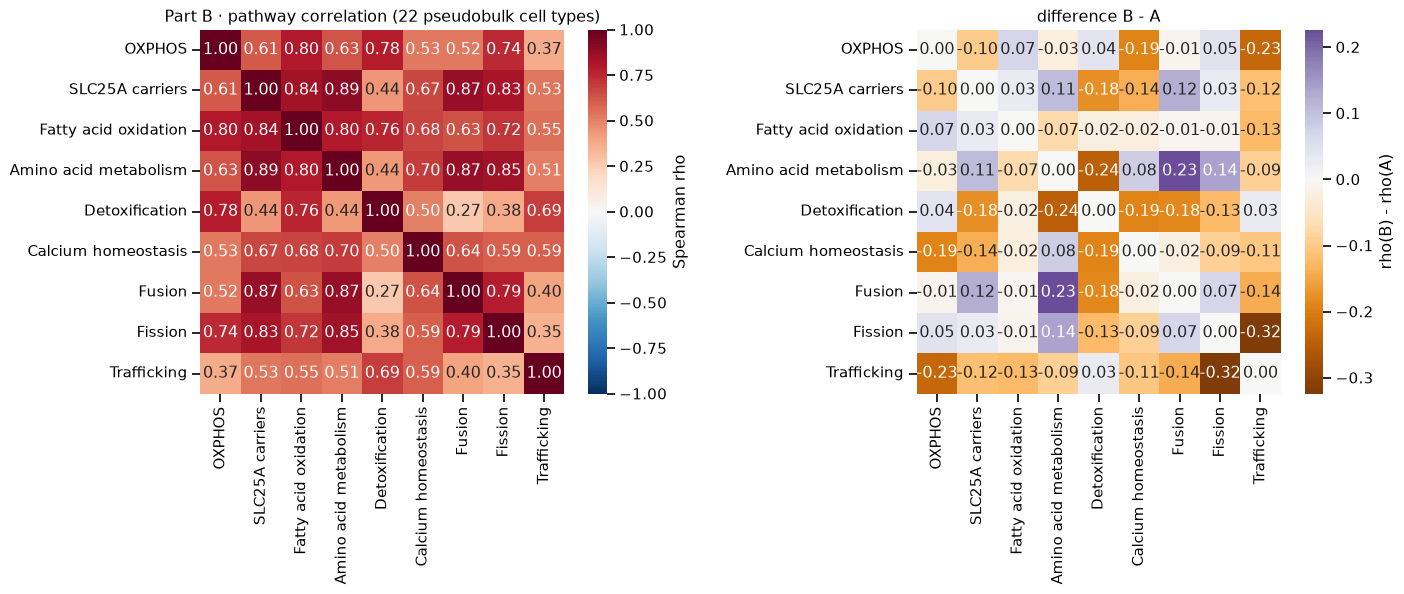

In [19]:
# B1 · correlation between pathways (across pseudobulk cell types)
corrB = scoreB[PATHWAYS].corr(method="spearman")
corrB.to_csv(OUT / "B1_pathway_correlation.csv")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(corrB, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=axes[0], cbar_kws={"label": "Spearman rho"})
axes[0].set_title("Part B · pathway correlation (%d pseudobulk cell types)" % len(scoreB))
sns.heatmap(corrB - corrA, annot=True, fmt=".2f", cmap="PuOr", center=0, square=True, ax=axes[1],
            cbar_kws={"label": "rho(B) - rho(A)"})
axes[1].set_title("difference B - A")
plt.tight_layout(); plt.savefig(OUT / "B1_pathway_correlation.png", dpi=150); plt.show()

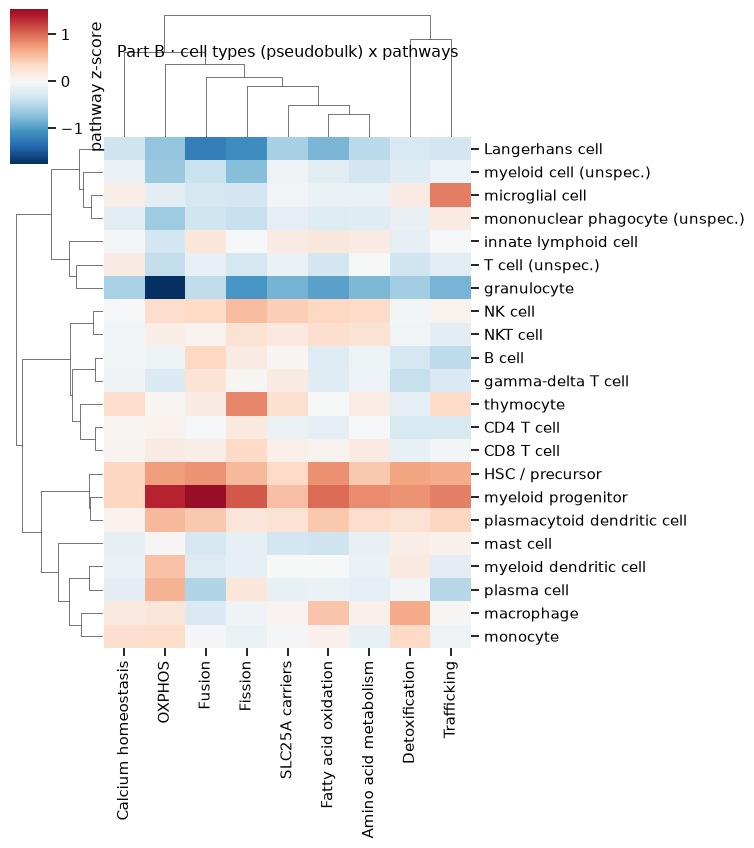

In [20]:
# B1b · clustermap cell types x pathways
cg = sns.clustermap(scoreB[PATHWAYS], cmap="RdBu_r", center=0, figsize=(8, 9),
                    metric="correlation", method="average",
                    cbar_kws={"label": "pathway z-score"})
cg.ax_heatmap.set_title("Part B · cell types (pseudobulk) x pathways", pad=60)
cg.savefig(OUT / "B1b_celltype_clustermap.png", dpi=150); plt.show()

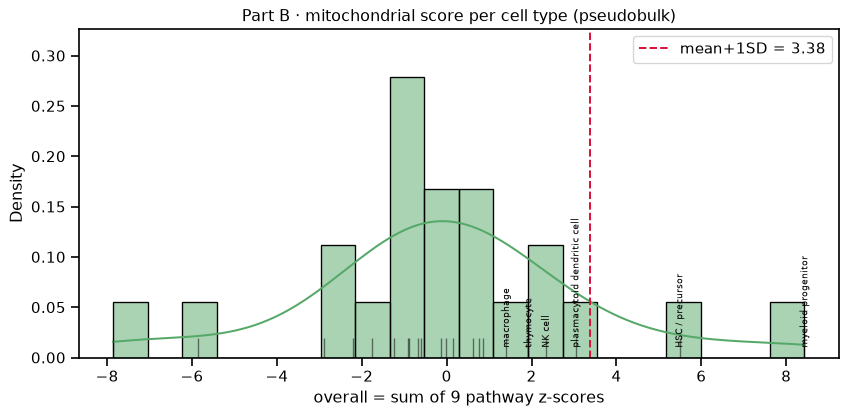

In [21]:
# B2 · overall distribution across pseudobulk cell types
ovb = scoreB["overall"]
cutb = ovb.mean() + ovb.std()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(ovb, bins=20, kde=True, stat="density", color="#55A868", ax=ax)
sns.rugplot(ovb, height=0.06, color="k", alpha=.5, ax=ax)
ax.axvline(cutb, color="crimson", ls="--", label=f"mean+1SD = {cutb:.2f}")
for c in ovb.nlargest(6).index:
    ax.annotate(c, (ovb[c], 0.01), rotation=90, fontsize=7, ha="center", va="bottom")
ax.set(xlabel="overall = sum of 9 pathway z-scores", title="Part B · mitochondrial score per cell type (pseudobulk)")
ax.legend(); plt.tight_layout(); plt.savefig(OUT / "B2_overall_distribution.png", dpi=150); plt.show()

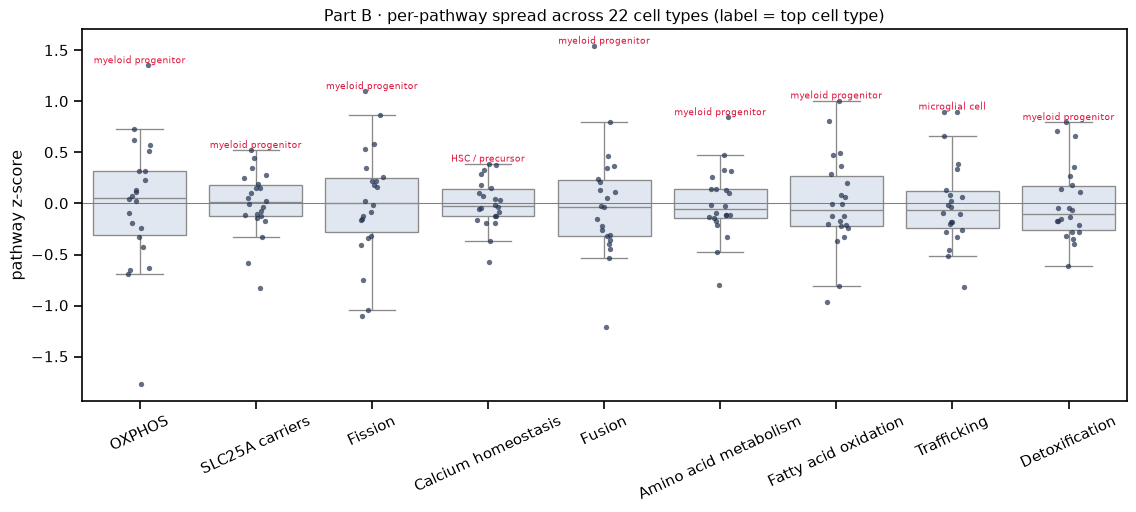

In [22]:
# B2b · spread of each pathway score across the pseudobulk cell types (box + points)
long = scoreB[PATHWAYS].reset_index().melt(id_vars="index", var_name="pathway", value_name="z")
fig, ax = plt.subplots(figsize=(12, 5.5))
order = scoreB[PATHWAYS].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=long, x="pathway", y="z", order=order, color="#dfe7f2", fliersize=0, ax=ax)
sns.stripplot(data=long, x="pathway", y="z", order=order, color="#22314f", size=4, alpha=.7, ax=ax)
for p in PATHWAYS:
    top_ct = scoreB[p].idxmax()
    ax.annotate(top_ct, (order.index(p), scoreB.loc[top_ct, p]), fontsize=7,
                ha="center", va="bottom", color="crimson")
ax.axhline(0, color="grey", lw=.8)
ax.set(xlabel="", ylabel="pathway z-score",
       title="Part B · per-pathway spread across %d cell types (label = top cell type)" % len(scoreB))
ax.tick_params(axis="x", rotation=25); plt.tight_layout()
plt.savefig(OUT / "B2b_pathway_spread.png", dpi=150); plt.show()

In [23]:
# B3 · TOP 25 cell types by 'overall'
colsB = ["n_groups","n_cells","n_organs","n_donors","generic_label"] + PATHWAYS + ["overall"]
topB = scoreB_full.sort_values("overall", ascending=False).head(CONFIG["topN_B"])[colsB].round(3)
topB.to_csv(OUT / "B3_top25_celltypes.csv")
topB

,n_groups,n_cells,n_organs,n_donors,generic_label,OXPHOS,SLC25A carriers,Fatty acid oxidation,Amino acid metabolism,Detoxification,Calcium homeostasis,Fusion,Fission,Trafficking,overall
celltype,,,,,,,,,,,,,,,
myeloid progenitor,1,388,1,6,False,1.352,0.522,1.006,0.843,0.795,0.379,1.542,1.099,0.893,8.430
HSC / precursor,10,2825,8,8,False,0.733,0.346,0.805,0.479,0.712,0.388,0.797,0.578,0.657,5.495
plasmacytoid dendritic cell,3,62,3,6,False,0.572,0.249,0.474,0.314,0.269,0.076,0.469,0.224,0.389,3.037
NK cell,22,13434,22,9,False,0.314,0.441,0.368,0.330,-0.043,-0.012,0.345,0.535,0.061,2.339
thymocyte,3,5616,1,5,False,0.040,0.283,-0.009,0.127,-0.176,0.323,0.133,0.869,0.338,1.927
macrophage,30,68250,28,9,False,0.234,0.052,0.496,0.104,0.662,0.178,-0.264,-0.084,0.020,1.399
NKT cell,18,5117,18,8,False,0.111,0.188,0.293,0.258,-0.067,-0.057,0.055,0.255,-0.184,0.853
CD8 T cell,29,75782,26,9,False,0.134,0.101,0.059,0.144,-0.149,0.041,0.109,0.350,-0.037,0.754
monocyte,50,48134,21,9,False,0.314,-0.036,0.079,-0.144,0.362,0.293,-0.037,-0.123,-0.096,0.614


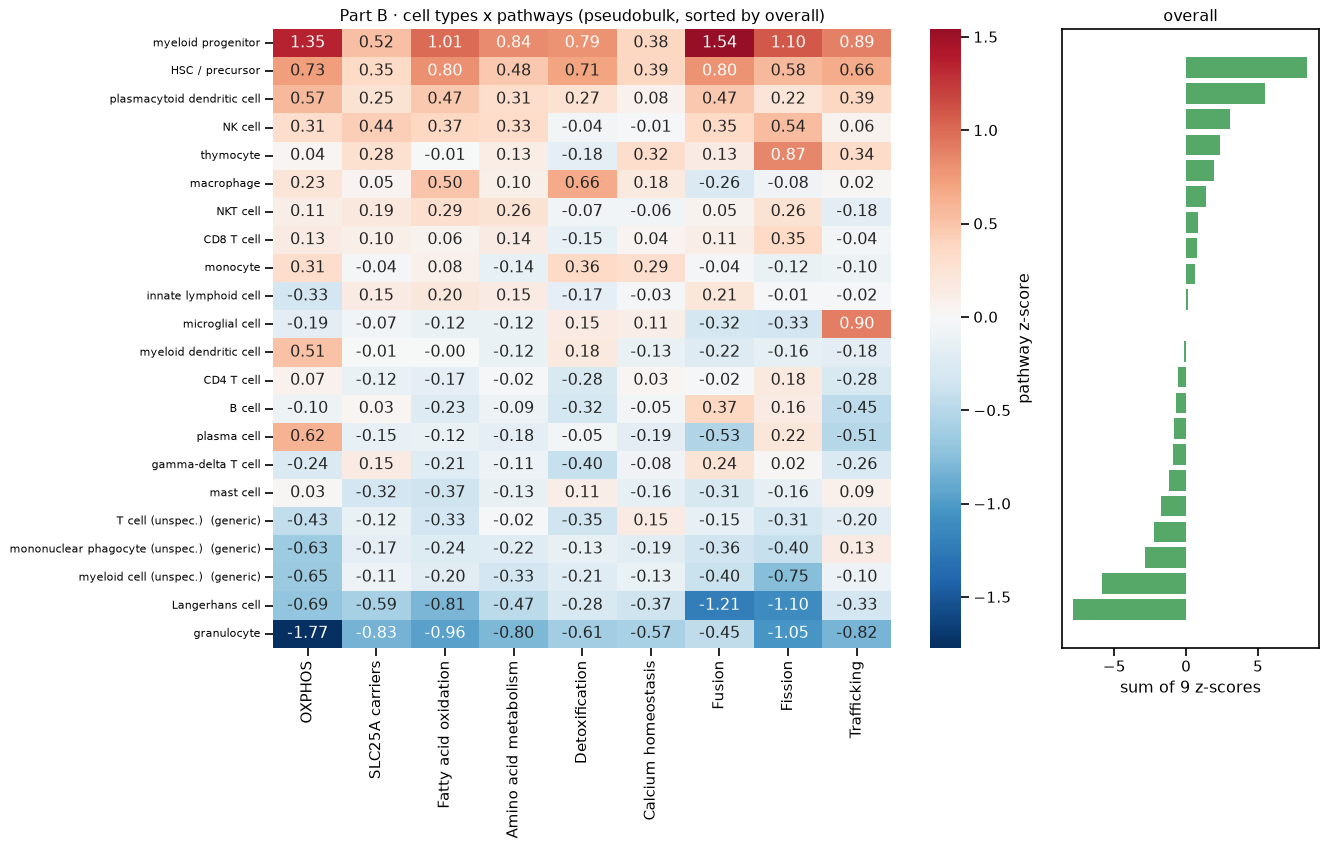

In [24]:
# B3b · heatmap of cell types x 9 pathways (z-scores), sorted by overall, + overall bar
tb = scoreB_full.sort_values("overall", ascending=False).head(CONFIG["topN_B"])
lab = [c + ("  (generic)" if g else "") for c, g in zip(tb.index, tb["generic_label"])]
fig, axs = plt.subplots(1, 2, figsize=(14, 9), gridspec_kw={"width_ratios": [3, 1]})
sns.heatmap(tb[PATHWAYS].set_axis(lab), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axs[0], cbar_kws={"label": "pathway z-score"})
axs[0].set_title("Part B · cell types x pathways (pseudobulk, sorted by overall)")
axs[0].set_ylabel(""); axs[0].tick_params(axis="y", labelsize=8)
axs[1].barh(range(len(tb))[::-1], tb["overall"].values, color="#55A868")
axs[1].set_yticks([]); axs[1].set_title("overall"); axs[1].set_xlabel("sum of 9 z-scores")
plt.tight_layout(); plt.savefig(OUT / "B3b_celltype_heatmap.png", dpi=150); plt.show()

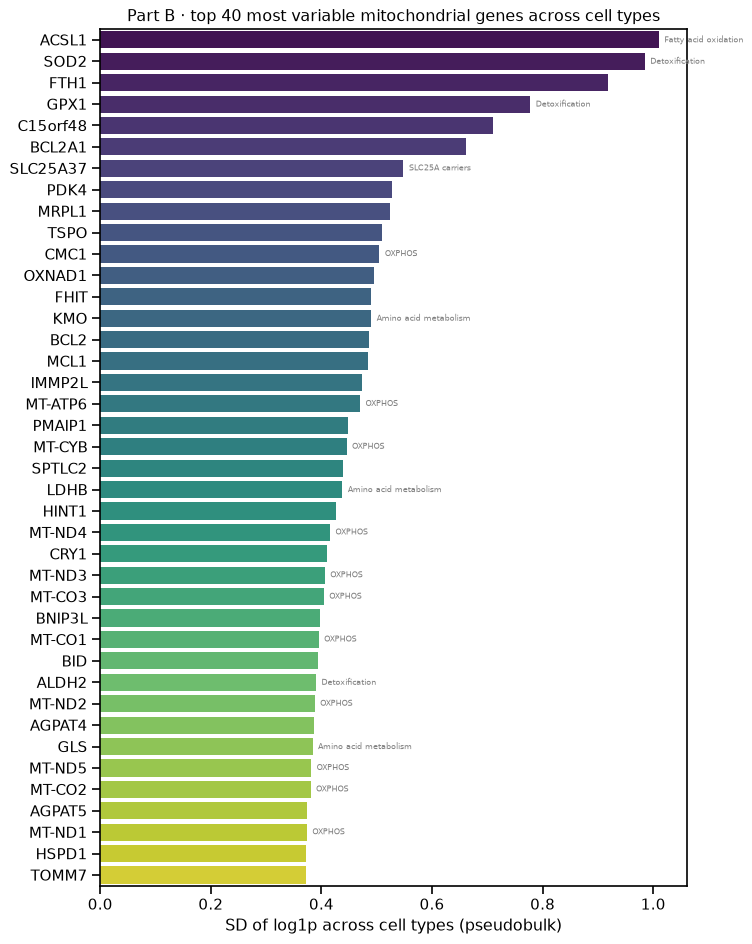

,gene,mean_log1p,sd_log1p,cv,pathways,argmax_celltype,argmin_celltype
0,ACSL1,1.187,1.010,0.851,Fatty acid oxidation,granulocyte,thymocyte
1,SOD2,1.659,0.985,0.593,Detoxification,mononuclear phagocyte (unspec.),gamma-delta T cell
2,FTH1,3.391,0.918,0.271,,mast cell,plasma cell
3,GPX1,1.349,0.778,0.576,Detoxification,microglial cell,gamma-delta T cell
4,C15orf48,0.386,0.710,1.841,,Langerhans cell,myeloid progenitor
5,BCL2A1,0.737,0.661,0.897,,granulocyte,myeloid progenitor
6,SLC25A37,0.607,0.548,0.903,SLC25A carriers,granulocyte,Langerhans cell
7,PDK4,0.366,0.528,1.445,,macrophage,plasmacytoid dendritic cell
8,MRPL1,0.662,0.525,0.793,,T cell (unspec.),granulocyte
9,TSPO,1.003,0.510,0.509,,monocyte,gamma-delta T cell


In [25]:
# B4 · most variable mitochondrial genes across pseudobulk cell types
gstats = pd.DataFrame({
    "gene": mito_sym_kept,
    "mean_log1p": pb_log.mean(0).to_numpy(),
    "sd_log1p":   pb_log.std(0).to_numpy(),
})
gstats["cv"] = gstats["sd_log1p"] / gstats["mean_log1p"].replace(0, np.nan)
gstats["pathways"] = gstats["gene"].map(lambda g: "; ".join(gene2path.get(g, [])))
gstats["argmax_celltype"] = pb_log.idxmax(0).to_numpy()
gstats["argmin_celltype"] = pb_log.idxmin(0).to_numpy()
hvg = gstats.sort_values("sd_log1p", ascending=False).reset_index(drop=True)
hvg.to_csv(OUT / "B4_variable_mito_genes.csv", index=False)

top = hvg.head(CONFIG["topN_hvg"])
fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(data=top, y="gene", x="sd_log1p", hue="gene", palette="viridis", legend=False, ax=ax)
ax.set(xlabel="SD of log1p across cell types (pseudobulk)", ylabel="",
       title=f"Part B · top {CONFIG['topN_hvg']} most variable mitochondrial genes across cell types")
for i, r in top.iterrows():
    if r["pathways"]:
        ax.text(r["sd_log1p"] + .01, i, r["pathways"], va="center", fontsize=6, color="grey")
plt.tight_layout(); plt.savefig(OUT / "B4_variable_mito_genes.png", dpi=150); plt.show()
top[["gene","mean_log1p","sd_log1p","cv","pathways","argmax_celltype","argmin_celltype"]].round(3)

C — for evry cell gorup understand mitochondrial expression



In [26]:
keep_d = n_by_donor > 0
pb_donor = pd.DataFrame(
    np.log1p(sum_raw_donor[keep_d] * (CONFIG["target_sum"] / tot_by_donor[keep_d, None])),
    index=[donor_names[i] for i in np.where(keep_d)[0]], columns=mito_sym_kept)

od = obs.loc[group_id >= 0].copy()
od["celltype"] = od["lineage"].map(COLLAPSE)
donor_meta = (od.groupby("donor", observed=True)
              .agg(n_cells=("organ", "size"), n_organs=("organ", "nunique"),
                   n_celltypes=("celltype", "nunique"),
                   top_organ=("organ", lambda s: s.value_counts().idxmax()),
                   top_celltype=("celltype", lambda s: s.value_counts().idxmax()))
              .reindex(pb_donor.index))

scoreD, scoreD_raw = score_pathways(pb_donor, pathway_local, PATHWAYS)
scoreD_full = donor_meta.join(scoreD).join(scoreD_raw)
scoreD_full.to_csv(OUT / "C_donor_pathway_scores.csv")
print("best donor by overall:", scoreD["overall"].idxmax())
scoreD_full[["n_cells","n_organs","n_celltypes","top_organ","top_celltype"] + PATHWAYS + ["overall"]].round(3)

best donor by overall: TSP9


,n_cells,n_organs,n_celltypes,top_organ,top_celltype,OXPHOS,SLC25A carriers,Fatty acid oxidation,Amino acid metabolism,Detoxification,Calcium homeostasis,Fusion,Fission,Trafficking,overall
TSP1,22438,5,13,Lung,macrophage,0.510,0.041,0.429,0.080,0.840,0.079,-0.167,0.049,-0.025,1.836
TSP2,64139,16,19,Blood,monocyte,0.457,0.259,0.228,0.209,0.209,0.327,0.514,0.364,-0.050,2.517
TSP3,26,1,4,Eye,microglial cell,-0.406,-0.394,-0.259,-0.165,-0.142,0.195,-0.644,-0.283,1.056,-1.043
TSP4,5503,2,11,Mammary,CD8 T cell,-0.215,0.059,-0.291,0.076,-0.224,0.030,0.001,0.251,-0.175,-0.487
TSP5,337,1,12,Eye,microglial cell,-0.003,0.073,-0.020,-0.084,-0.079,0.132,0.079,0.103,0.146,0.347
TSP6,6885,2,13,Trachea,granulocyte,-0.056,0.090,-0.216,-0.158,-0.173,-0.039,-0.202,-0.359,-0.204,-1.318
TSP7,40520,5,15,Lymph_Node,B cell,0.067,0.280,0.046,0.228,-0.153,0.181,0.601,0.343,-0.248,1.344
TSP8,7143,2,11,Blood,granulocyte,-0.539,-0.457,-0.390,-0.291,-0.089,-0.373,0.096,-0.458,-0.270,-2.771
TSP9,2714,1,7,Pancreas,macrophage,0.961,0.419,0.704,0.254,0.320,0.699,0.927,0.620,0.830,5.734
TSP10,10833,3,14,Fat,macrophage,0.008,0.334,0.087,0.101,0.213,0.347,0.224,0.162,0.296,1.773


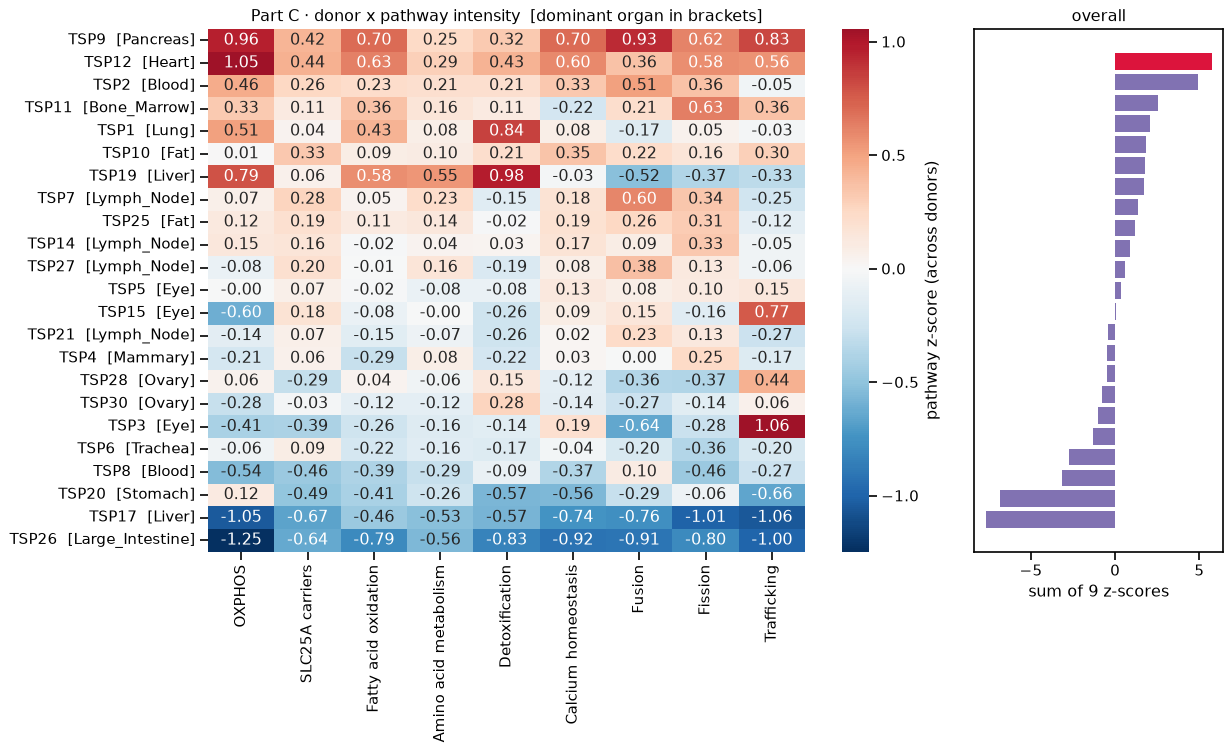

In [27]:
# C1 · donor x 9 pathways heatmap (z-scores), sorted by overall  +  overall bar
sd = scoreD_full.sort_values("overall", ascending=False)
lab = [f"{d}  [{donor_meta.loc[d,'top_organ']}]" for d in sd.index]
fig, axs = plt.subplots(1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [3, 1]})
sns.heatmap(sd[PATHWAYS].set_axis(lab), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axs[0], cbar_kws={"label": "pathway z-score (across donors)"})
axs[0].set_title("Part C · donor x pathway intensity  [dominant organ in brackets]")
axs[0].set_ylabel("")
colors = ["crimson" if i == 0 else "#8172B2" for i in range(len(sd))]
axs[1].barh(range(len(sd))[::-1], sd["overall"].values, color=colors)
axs[1].set_yticks([]); axs[1].set_title("overall"); axs[1].set_xlabel("sum of 9 z-scores")
axs[1].annotate("best donor", (sd["overall"].iloc[0], len(sd) - 1), fontsize=8, color="crimson",
                va="center", ha="right")
plt.tight_layout(); plt.savefig(OUT / "C1_donor_pathway_heatmap.png", dpi=150); plt.show()

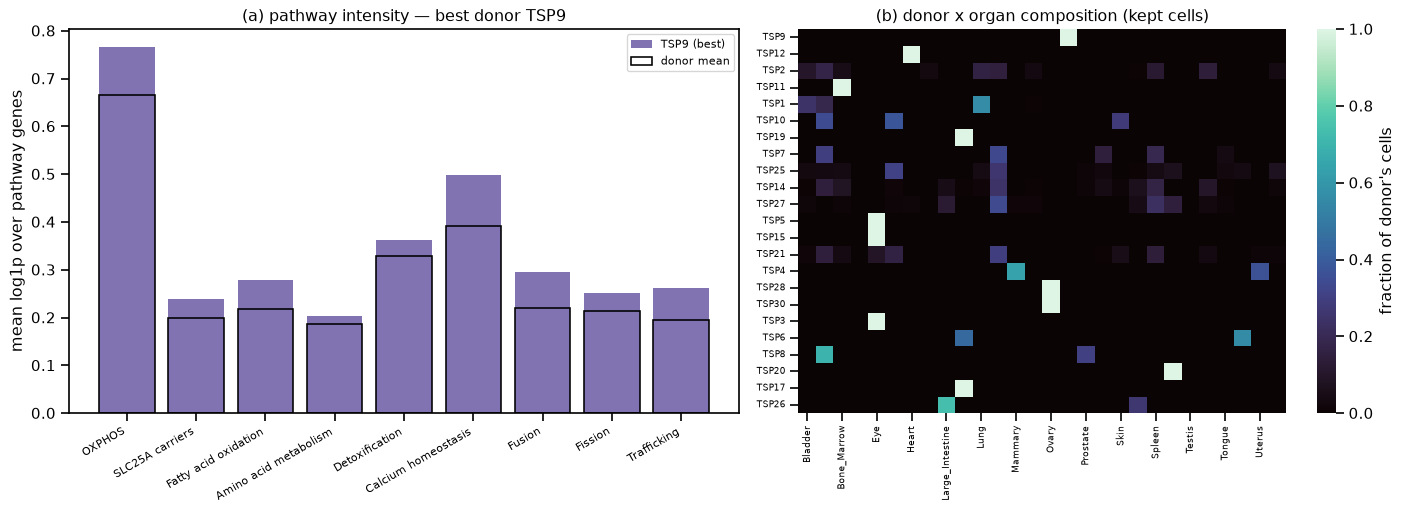

In [28]:
# C2 · best donor: pathway intensity bars (raw log1p pathway means, not z) + donor x organ context
best = scoreD["overall"].idxmax()
raw_means = {p: pb_donor.loc[:, [mito_sym_kept[j] for j in pathway_local[p]]].mean(1) for p in PATHWAYS}
rm = pd.DataFrame(raw_means)
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axs[0]
ax.bar(range(len(PATHWAYS)), rm.loc[best], color="#8172B2", label=f"{best} (best)")
ax.bar(range(len(PATHWAYS)), rm.mean(0), color="none", edgecolor="k", lw=1.2, label="donor mean")
ax.set_xticks(range(len(PATHWAYS))); ax.set_xticklabels(PATHWAYS, rotation=30, ha="right", fontsize=8)
ax.set(ylabel="mean log1p over pathway genes", title=f"(a) pathway intensity — best donor {best}")
ax.legend(fontsize=8)
do = obs.loc[group_id >= 0].groupby(["donor", "organ"], observed=True).size().unstack(fill_value=0)
do = do.loc[sd.index]
sns.heatmap(do.div(do.sum(1), axis=0), cmap="mako", ax=axs[1],
            cbar_kws={"label": "fraction of donor's cells"})
axs[1].set_title("(b) donor x organ composition (kept cells)"); axs[1].set_ylabel(""); axs[1].set_xlabel("")
axs[1].tick_params(axis="x", labelsize=7, rotation=90); axs[1].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.savefig(OUT / "C2_best_donor.png", dpi=150); plt.show()

PART D —  gene-level landscape

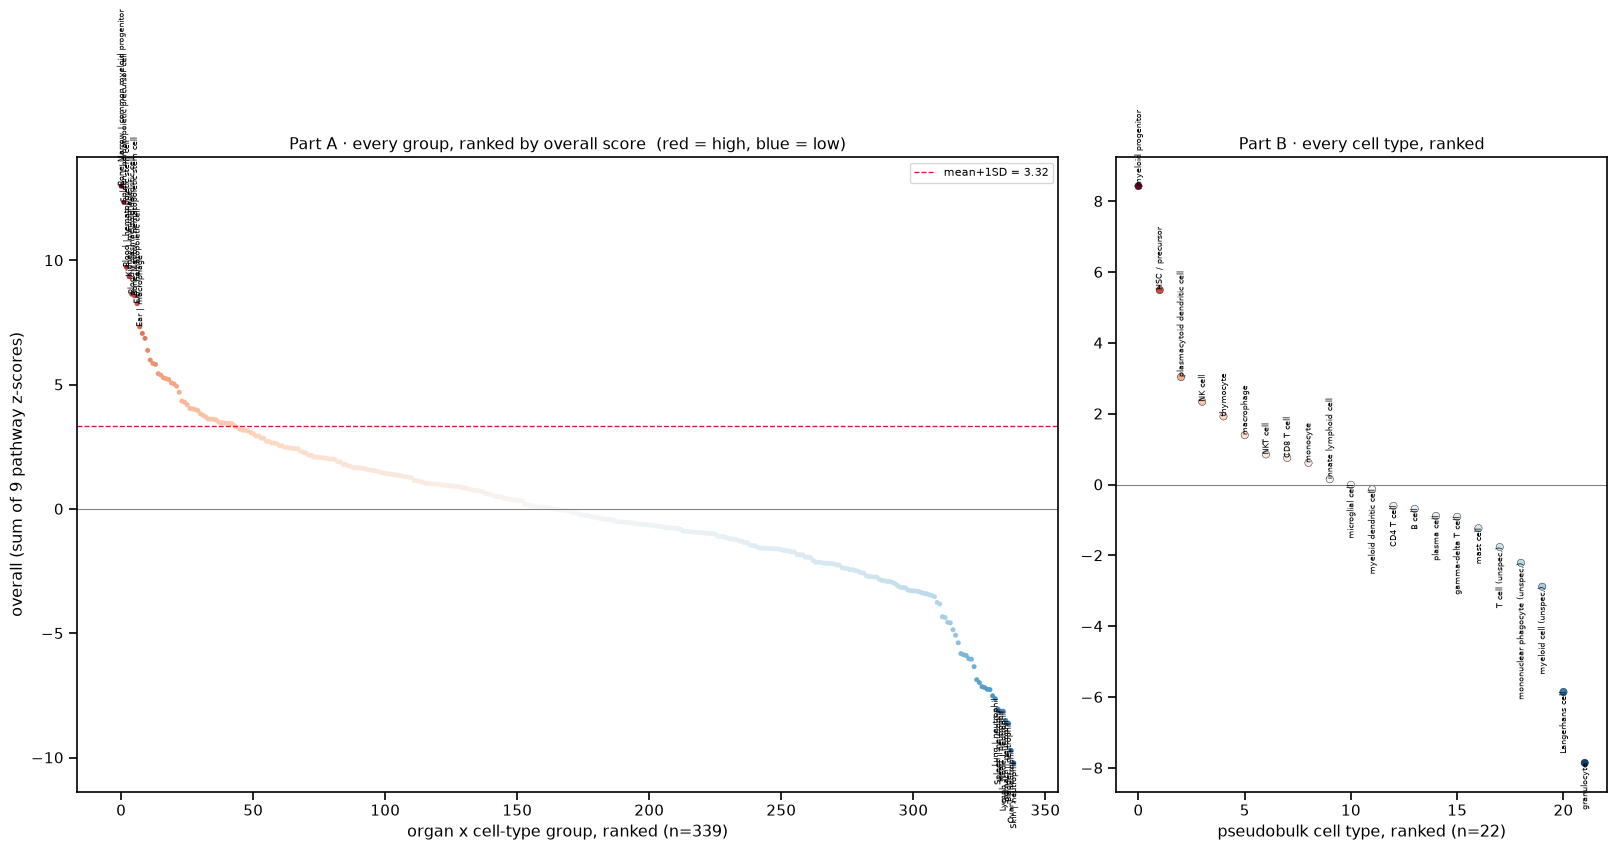

In [ ]:
# D1 · full ranked landscape of the 'overall' mitochondrial score 
fig, axs = plt.subplots(1, 2, figsize=(17, 9), gridspec_kw={"width_ratios": [2, 1]})

# (a) all G organ x cell-type groups (Part A), sorted high -> low
sA = scoreA_full.sort_values("overall", ascending=False)
x = np.arange(len(sA))
vmax = np.abs(sA["overall"]).max()
ax = axs[0]
ax.scatter(x, sA["overall"], c=sA["overall"], cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=14, edgecolor="none")
ax.axhline(0, color="grey", lw=.8)
ax.axhline(cut, color="crimson", ls="--", lw=1, label=f"mean+1SD = {cut:.2f}")
for i in list(range(8)) + list(range(len(sA) - 8, len(sA))):
    r = sA.iloc[i]
    ax.annotate(f"{r.organ} | {r.lineage}", (x[i], r["overall"]), fontsize=6, rotation=90,
                ha="center", va="bottom" if r["overall"] >= 0 else "top")
ax.set(xlabel=f"organ x cell-type group, ranked (n={len(sA)})", ylabel="overall (sum of 9 pathway z-scores)",
       title="Part A · every group, ranked by overall score  (red = high, blue = low)")
ax.legend(fontsize=8)

# (b) all pseudobulk cell types (Part B), sorted high -> low
sB = scoreB_full.sort_values("overall", ascending=False)
xb = np.arange(len(sB))
vmaxb = np.abs(sB["overall"]).max()
ax = axs[1]
ax.scatter(xb, sB["overall"], c=sB["overall"], cmap="RdBu_r", vmin=-vmaxb, vmax=vmaxb,
           s=30, edgecolor="k", linewidth=.3)
ax.axhline(0, color="grey", lw=.8)
for i, r in enumerate(sB.itertuples()):
    ax.annotate(r.Index, (xb[i], r.overall), fontsize=6, rotation=90,
                ha="center", va="bottom" if r.overall >= 0 else "top")
ax.set(xlabel=f"pseudobulk cell type, ranked (n={len(sB)})", title="Part B · every cell type, ranked")
plt.tight_layout(); plt.savefig(OUT / "D1_full_ranked_overall.png", dpi=150); plt.show()


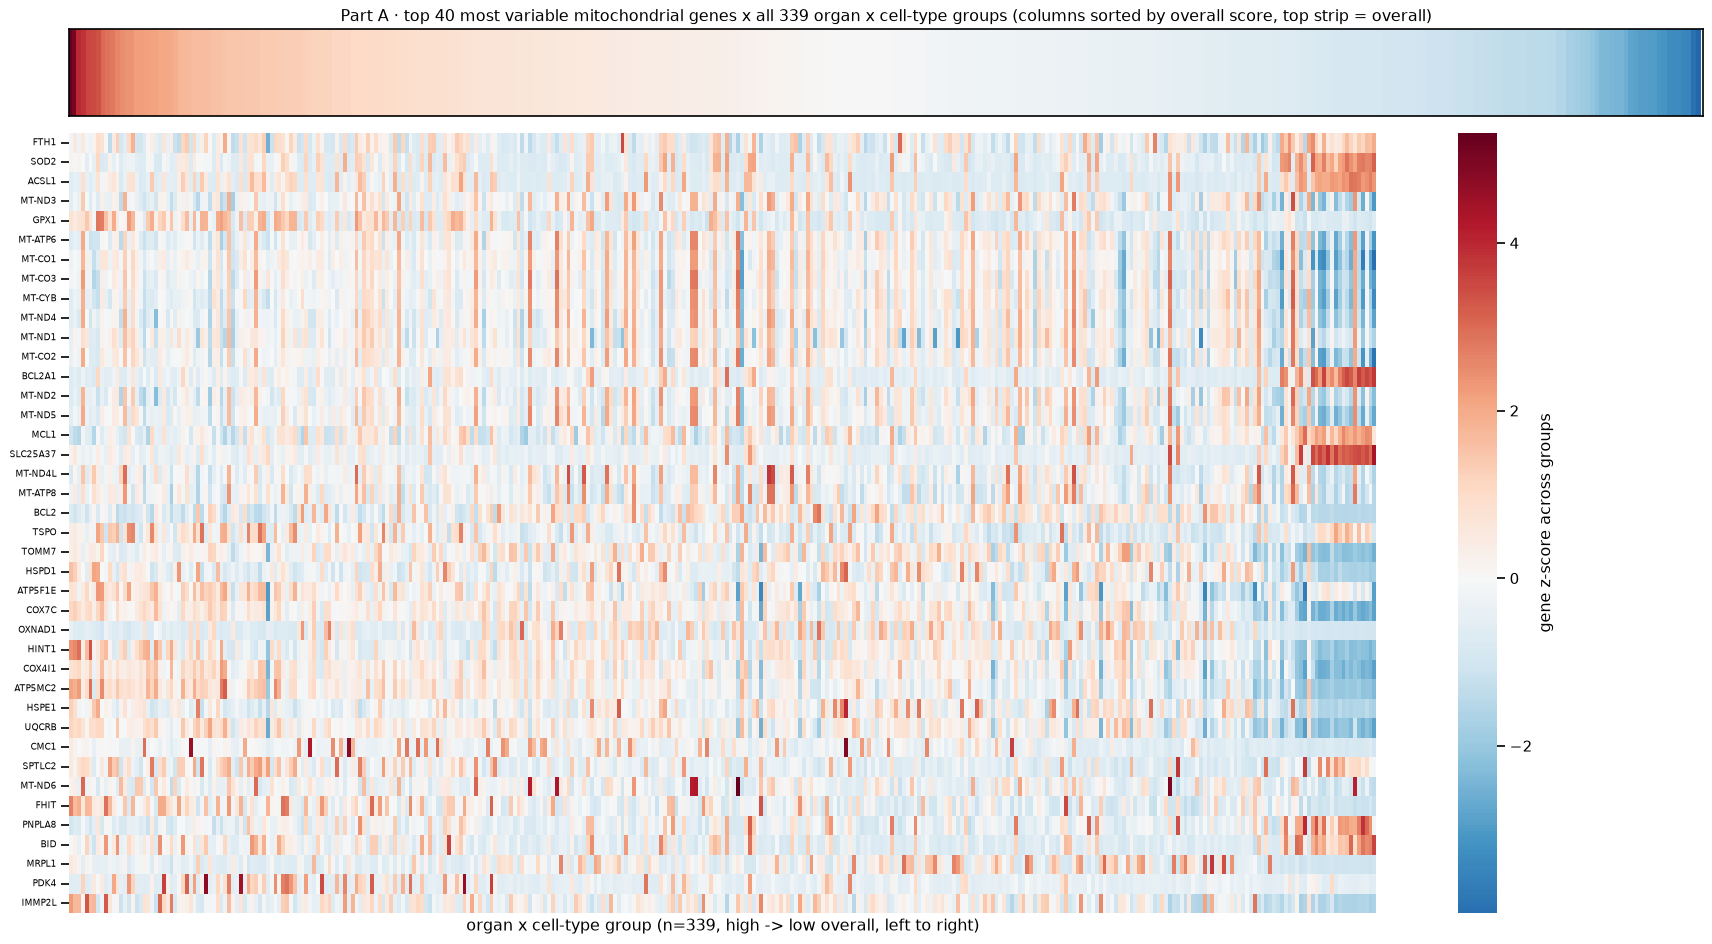

In [30]:
# D2 · most variable mitochondrial genes across ALL organ x cell-type groups (Part A), and the
# resulting genes x groups landscape (gene-level z-scores, columns = every group, sorted by overall)
gstatsA = pd.DataFrame({
    "gene": mito_sym_kept,
    "mean_log1p": grp_mean.mean(0).to_numpy(),
    "sd_log1p":   grp_mean.std(0).to_numpy(),
})
gstatsA["cv"] = gstatsA["sd_log1p"] / gstatsA["mean_log1p"].replace(0, np.nan)
gstatsA["pathways"] = gstatsA["gene"].map(lambda g: "; ".join(gene2path.get(g, [])))
gstatsA["argmax_group"] = grp_mean.idxmax(0).to_numpy()
gstatsA["argmin_group"] = grp_mean.idxmin(0).to_numpy()
hvgA = gstatsA.sort_values("sd_log1p", ascending=False).reset_index(drop=True)
hvgA.to_csv(OUT / "D2_variable_mito_genes_groups.csv", index=False)

topg = hvgA.head(CONFIG["topN_hvg"])["gene"].tolist()
order = scoreA_full.sort_values("overall", ascending=False).index          # all G groups, high -> low
Zg = (grp_mean[topg] - grp_mean[topg].mean(0)) / grp_mean[topg].std(0).replace(0, 1)
Zg = Zg.loc[order]

fig, axs = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={"height_ratios": [1, 9]}, sharex=True)
axs[0].imshow(scoreA_full.loc[order, "overall"].to_numpy()[None, :], aspect="auto", cmap="RdBu_r",
              vmin=-vmax, vmax=vmax)
axs[0].set_yticks([]); axs[0].set_xticks([])
axs[0].set_title("Part A · top %d most variable mitochondrial genes x all %d organ x cell-type groups "
                  "(columns sorted by overall score, top strip = overall)" % (len(topg), len(order)))
sns.heatmap(Zg.T, cmap="RdBu_r", center=0, ax=axs[1], cbar_kws={"label": "gene z-score across groups"},
            xticklabels=False)
axs[1].set_ylabel(""); axs[1].tick_params(axis="y", labelsize=7)
axs[1].set_xlabel("organ x cell-type group (n=%d, high -> low overall, left to right)" % len(order))
plt.tight_layout(); plt.savefig(OUT / "D2_full_gene_heatmap_groups.png", dpi=150); plt.show()


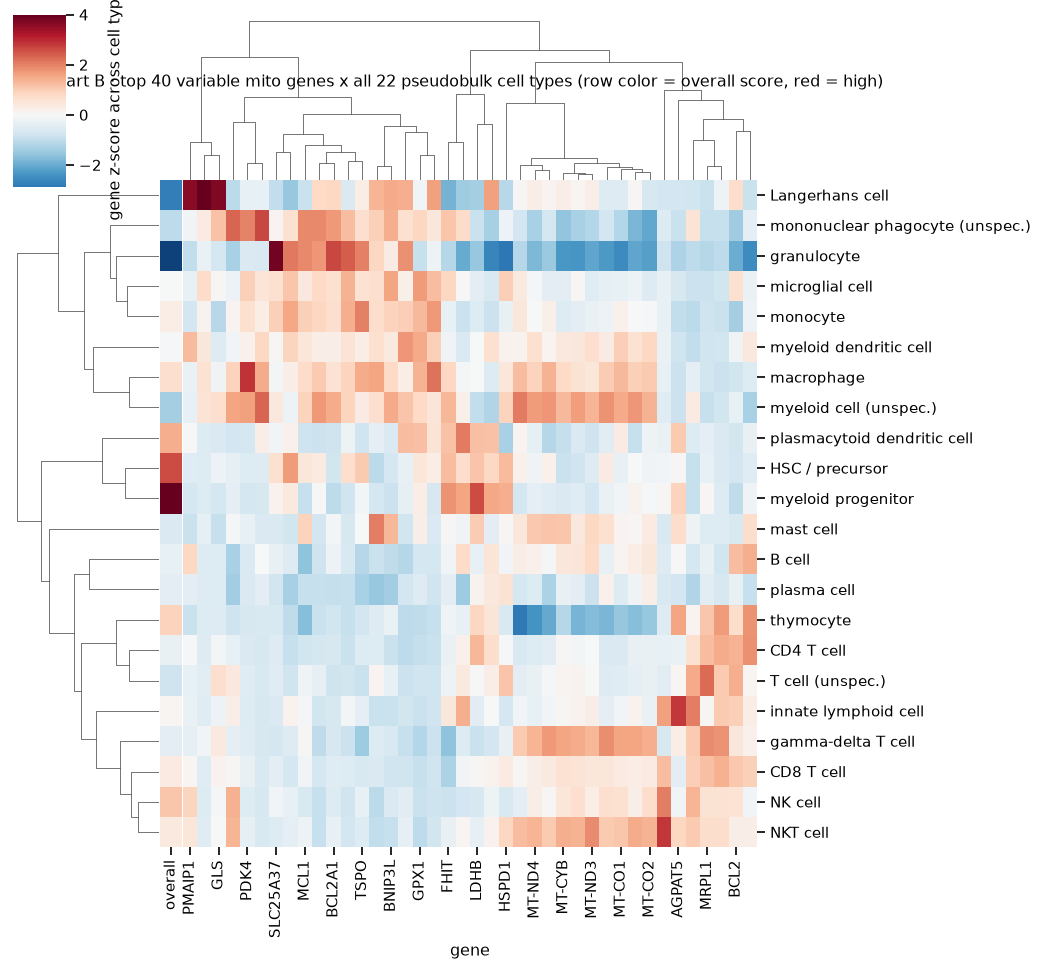

In [31]:
# D3 · full gene expression landscape across ALL pseudobulk cell types (both axes clustered)
topg_b = hvg.head(CONFIG["topN_hvg"])["gene"].tolist()
Zb = (pb_log[topg_b] - pb_log[topg_b].mean(0)) / pb_log[topg_b].std(0).replace(0, 1)
row_colors = scoreB_full.loc[Zb.index, "overall"].map(
    lambda v: plt.cm.RdBu_r((v - (-vmaxb)) / (2 * vmaxb)))
cg = sns.clustermap(Zb, cmap="RdBu_r", center=0, figsize=(11, 10), metric="correlation", method="average",
                    row_colors=row_colors, cbar_kws={"label": "gene z-score across cell types"})
cg.ax_heatmap.set_title("Part B · top %d variable mito genes x all %d pseudobulk cell types "
                         "(row color = overall score, red = high)" % (len(topg_b), len(Zb)), pad=70)
cg.ax_heatmap.set_xlabel("gene"); cg.ax_heatmap.set_ylabel("")
cg.savefig(OUT / "D3_full_gene_clustermap_celltypes.png", dpi=150); plt.show()


In [32]:
# D4 · extract EVERY group / cell type whose overall score is "high" (mean+1SD cut, from A2/B2) —
# not a fixed top-25 cut, so the count reflects how many actually stand out
highA = scoreA_full.loc[scoreA_full["overall"] > cut].sort_values("overall", ascending=False)
highB = scoreB_full.loc[scoreB_full["overall"] > cutb].sort_values("overall", ascending=False)
highA[["organ", "lineage", "n_cells", "n_donors"] + PATHWAYS + ["overall"]].round(3) \
    .to_csv(OUT / "D4_high_overall_groups.csv")
highB[["n_groups", "n_cells", "n_organs", "generic_label"] + PATHWAYS + ["overall"]].round(3) \
    .to_csv(OUT / "D4_high_overall_celltypes.csv")
print(f"Part A: {len(highA)}/{len(scoreA_full)} organ x cell-type groups above mean+1SD ({cut:.2f})")
print(f"Part B: {len(highB)}/{len(scoreB_full)} pseudobulk cell types above mean+1SD ({cutb:.2f})")
highB[["n_cells", "n_organs"] + PATHWAYS + ["overall"]].round(3)


Part A: 44/339 organ x cell-type groups above mean+1SD (3.32)
Part B: 2/22 pseudobulk cell types above mean+1SD (3.38)


,n_cells,n_organs,OXPHOS,SLC25A carriers,Fatty acid oxidation,Amino acid metabolism,Detoxification,Calcium homeostasis,Fusion,Fission,Trafficking,overall
celltype,,,,,,,,,,,,
myeloid progenitor,388,1,1.352,0.522,1.006,0.843,0.795,0.379,1.542,1.099,0.893,8.430
HSC / precursor,2825,8,0.733,0.346,0.805,0.479,0.712,0.388,0.797,0.578,0.657,5.495


PART E  surface markers for every cell type

the whole transcriptome is screened against the **SURFY surfaceome** (Bausch-Fluck et al., PNAS 2018,
`pnas.1808790115.sd01.xls`, sheet 11.7: 2,886 predicted cell-surface proteins, with CD numbers and Membranome class).

For each cell type (pseudobulk over all organs, same normalization as Part B), search for surface gene, a gene is said to be a **marker** when `pct_in ≥ 0.20`, `log2FC ≥ 1` and `pct_in − pct_out_mean ≥ 0.15`; markers are ranked by `Δpct × min(log2FC, 5)`. `n_types_pos` = how many cell types express it (≥20 % of cells) → **unique / restricted (≤3) / shared**.

A second streaming pass reads the raw counts once more, this time for the surfaceome ∪ ligand/receptor genes
(~4k columns) per `organ × cell type` group (sum of counts + number of cells with ≥1 UMI).

In [33]:
# E0 · gene universe: SURFY surfaceome  ∪  every ligand / receptor subunit of the LIANA "consensus" resource
import liana as li
SURFY = Path("../data/pnas.1808790115.sd01.xls")
CONFIG.update(min_pct_marker=0.20, min_lfc_marker=1.0, min_dpct_marker=0.15, top_markers=10, dot_markers=3,
              min_pct_lr=0.10, min_spec_lr=0.15)

surf = pd.read_excel(SURFY, sheet_name="11.7_Surfaceome", header=1)
surf = surf[surf["Surfaceome Label"].eq("surface")].reset_index(drop=True)
surf["ens_list"] = surf["Ensembl gene"].astype(str).str.replace(" ", "").str.split(";")
surf_ens = {e.split(".")[0] for l in surf["ens_list"] for e in l if e.startswith("ENSG")}
surf_sym = set(surf["UniProt gene"].dropna().astype(str))

lr_res = li.resource.select_resource("consensus").drop_duplicates().reset_index(drop=True)
lr_res["lig"] = lr_res["ligand"].str.split("_")
lr_res["rec"] = lr_res["receptor"].str.split("_")
lr_genes = {g for c in ("lig", "rec") for l in lr_res[c] for g in l}

want_sym = surf_sym | lr_genes
cand = np.where(np.isin(var_ens, list(surf_ens)) | np.isin(var_sym, list(want_sym)))[0]
print(f"surfaceome: {len(surf)} proteins · L-R resource: {len(lr_res)} pairs / {len(lr_genes)} genes · "
      f"candidate matrix columns: {len(cand)}")

surfaceome: 2886 proteins · L-R resource: 4624 pairs / 1877 genes · candidate matrix columns: 3685


In [34]:
# E1 · streaming pass #2 — per organ x cell-type group: sum of raw counts + number of cells with >=1 UMI
FORCE_E = False
npz_e = OUT / "stream_surface.npz"
if npz_e.exists() and not FORCE_E and np.array_equal(np.load(npz_e)["cand"], cand):
    ze = np.load(npz_e); raw_g, det_g = ze["raw_g"], ze["det_g"]
    print("loaded from cache:", npz_e.name)
else:
    S_ = len(cand)
    raw_g = np.zeros((G, S_), np.float64)
    det_g = np.zeros((G, S_), np.float64)
    CH = CONFIG["chunk"]
    with h5py.File(RAW, "r") as h:
        Xg = h["raw/X"]; indptr = Xg["indptr"]; data_ds = Xg["data"]; idx_ds = Xg["indices"]
        ncol = Xg.attrs["shape"][1]
        t0 = time.time()
        for a in range(0, n_cells_total, CH):
            b = min(a + CH, n_cells_total)
            gids = group_id[a:b]
            if (gids >= 0).sum() == 0:
                continue
            ip = indptr[a:b + 1].astype(np.int64); s, e = int(ip[0]), int(ip[-1])
            X = sp.csr_matrix((data_ds[s:e], idx_ds[s:e], ip - s), shape=(b - a, ncol))
            tot = np.asarray(X.sum(1)).ravel()
            v = (gids >= 0) & (tot > 0)                              # same mask as the mito pass
            Xs = X[v][:, cand].tocsr()
            M = sp.csr_matrix((np.ones(int(v.sum())), (gids[v], np.arange(int(v.sum())))), shape=(G, int(v.sum())))
            raw_g += (M @ Xs).toarray()
            det_g += (M @ (Xs > 0).astype(np.float64)).toarray()
            if (a // CH) % 5 == 0:
                print(f"  {b:>7,}/{n_cells_total:,}  ({time.time()-t0:5.1f}s)")
    np.savez_compressed(npz_e, cand=cand, raw_g=raw_g, det_g=det_g)
    print("saved:", npz_e.name)

# sanity: genes that are both MitoCarta and surfaceome/L-R must give exactly the counts of the first pass
mito_col = {int(p): j for j, p in enumerate(mito_pos)}
both = [(i, mito_col[int(c)]) for i, c in enumerate(cand) if int(c) in mito_col]
if both:
    ci, mj = map(np.array, zip(*both))
    assert np.allclose(raw_g[:, ci], sum_raw[:, mj]), "second pass disagrees with the first pass"
    print(f"consistency check vs pass #1 on {len(both)} shared mito genes: OK")

loaded from cache: stream_surface.npz
consistency check vs pass #1 on 9 shared mito genes: OK


In [35]:
# E2 · one column per gene symbol, SURFY annotation, pooled pseudobulk per cell type (same normalization as Part B)
gt = pd.DataFrame({"symbol": var_sym[cand], "ens": var_ens[cand], "col": np.arange(len(cand)),
                   "total": raw_g.sum(0), "surf_ens": np.isin(var_ens[cand], list(surf_ens))})
gt = (gt.sort_values(["symbol", "surf_ens", "total"], ascending=[True, False, False])
        .drop_duplicates("symbol").set_index("symbol"))          # duplicate symbols: SURFY Ensembl id first, then most counts

ANN = ["UniProt description", "CD number", "Membranome Almen main-class", "Membranome Almen sub-class",
       "SURFY score", "TM domains", "Surfaceome Label Source"]
se = surf.explode("ens_list").assign(ens=lambda d: d["ens_list"].str.split(".").str[0]).drop_duplicates("ens").set_index("ens")
ss = surf.dropna(subset=["UniProt gene"]).drop_duplicates("UniProt gene").set_index("UniProt gene")
ann_rows, is_surf = [], []
for sym_, ens_ in zip(gt.index, gt["ens"]):
    if ens_ in se.index:   ann_rows.append(se.loc[ens_, ANN].to_dict()); is_surf.append(True)
    elif sym_ in ss.index: ann_rows.append(ss.loc[sym_, ANN].to_dict()); is_surf.append(True)
    else:                  ann_rows.append({}); is_surf.append(False)
gt = gt.join(pd.DataFrame(ann_rows, index=gt.index, columns=ANN))
gt["is_surface"] = is_surf
print(f"genes with data: {len(gt)}  ·  surfaceome genes matched in Tabula: {int(gt.is_surface.sum())} / {len(surf)}"
      f"  ·  L-R genes matched: {len(lr_genes & set(gt.index))} / {len(lr_genes)}")

T = len(ct_index)
ct_of_group = meta_b["celltype"].map(ct2i).to_numpy()
Agrp = sp.csr_matrix((np.ones(G), (ct_of_group, np.arange(G))), shape=(T, G))
cols_ = gt["col"].to_numpy()
raw_ct = Agrp @ raw_g[:, cols_]
det_ct = Agrp @ det_g[:, cols_]
n_ct   = Agrp @ n_by_grp.astype(np.float64)
tot_ct = Agrp @ tot_by_grp
cpm  = pd.DataFrame(raw_ct / tot_ct[:, None] * CONFIG["target_sum"], index=ct_index, columns=gt.index)
expr = np.log1p(cpm)                                              # pseudobulk log1p(CPM x 1e4/1e6)
pct  = pd.DataFrame(det_ct / n_ct[:, None], index=ct_index, columns=gt.index)
generic = ct_meta.set_index("celltype").loc[ct_index, "generic_label"].to_numpy()
bg_ok = ~generic                                                  # background = non-generic cell types
CT_ORDER = [c for c in dict.fromkeys(COLLAPSE.values()) if c in ct_index]
DISP = {c: c + (" *" if g else "") for c, g in zip(ct_index, generic)}
assert set(CT_ORDER) == set(ct_index)
print(f"pooled per cell type: {T} types x {len(gt)} genes  ·  background for markers = {int(bg_ok.sum())} non-generic types (* = generic label)")

genes with data: 3683  ·  surfaceome genes matched in Tabula: 2768 / 2886  ·  L-R genes matched: 1868 / 1877
pooled per cell type: 22 types x 3683 genes  ·  background for markers = 19 non-generic types (* = generic label)


In [36]:
# E3 · marker statistics for every (cell type x surface gene)
surf_genes = gt.index[gt["is_surface"]]
P_ = pct[surf_genes].to_numpy(); C_ = cpm[surf_genes].to_numpy(); E_ = expr[surf_genes].to_numpy()
parts = []
for ti, t in enumerate(ct_index):
    oth = bg_ok.copy(); oth[ti] = False
    pct_out_mean = P_[oth].mean(0); pct_out_max = P_[oth].max(0); cpm_out = C_[oth].mean(0)
    n_pos = (P_[bg_ok] >= CONFIG["min_pct_marker"]).sum(0) + (generic[ti] & (P_[ti] >= CONFIG["min_pct_marker"]))
    parts.append(pd.DataFrame({
        "celltype": t, "gene": surf_genes, "pct_in": P_[ti], "pct_out_mean": pct_out_mean, "pct_out_max": pct_out_max,
        "dpct": P_[ti] - pct_out_mean, "cpm_in": C_[ti], "cpm_out_mean": cpm_out,
        "log2FC": np.log2((C_[ti] + 0.1) / (cpm_out + 0.1)), "expr_log1p": E_[ti], "n_types_pos": n_pos}))
mk_all = pd.concat(parts, ignore_index=True)
mk_all["is_marker"] = ((mk_all.pct_in >= CONFIG["min_pct_marker"]) & (mk_all.log2FC >= CONFIG["min_lfc_marker"])
                       & (mk_all.dpct >= CONFIG["min_dpct_marker"]))
mk_all["score"] = mk_all["dpct"] * mk_all["log2FC"].clip(upper=5)
mk_all["specificity"] = pd.cut(mk_all["n_types_pos"], [0, 1, 3, 99], labels=["unique", "restricted (2-3)", "shared (4+)"])
mk_all = mk_all.merge(gt[["ens", "CD number", "UniProt description", "Membranome Almen main-class",
                          "Membranome Almen sub-class", "SURFY score"]].rename(columns={"ens": "ensembl"}),
                      left_on="gene", right_index=True, how="left")
mk_all.round(4).to_csv(OUT / "E_surface_gene_stats_all.csv.gz", index=False)

mk = mk_all[mk_all.is_marker].sort_values(["celltype", "score"], ascending=[True, False]).reset_index(drop=True)
mk["rank"] = mk.groupby("celltype").cumcount() + 1
mk.round(4).to_csv(OUT / "E_markers_per_celltype.csv", index=False)
top_mk = mk[mk["rank"] <= CONFIG["top_markers"]]
top_mk.round(4).to_csv(OUT / "E_top_markers_per_celltype.csv", index=False)

cnt = (mk.groupby(["celltype", "specificity"], observed=False).size().unstack(fill_value=0)
         .reindex(CT_ORDER).fillna(0).astype(int))
print(f"surface genes tested: {len(surf_genes)}  ·  markers passing the filters: {len(mk):,} "
      f"(over {mk.celltype.nunique()}/{T} cell types)")
print("cell types with NO marker:", [c for c in CT_ORDER if c not in set(mk.celltype)] or "none")
cnt

surface genes tested: 2768  ·  markers passing the filters: 1,650 (over 22/22 cell types)
cell types with NO marker: none


specificity,unique,restricted (2-3),shared (4+)
celltype,,,
CD4 T cell,1,7,23
CD8 T cell,0,7,25
gamma-delta T cell,5,15,35
NKT cell,0,11,23
T cell (unspec.),0,6,18
thymocyte,5,9,24
NK cell,3,13,43
innate lymphoid cell,14,9,33
B cell,9,16,20


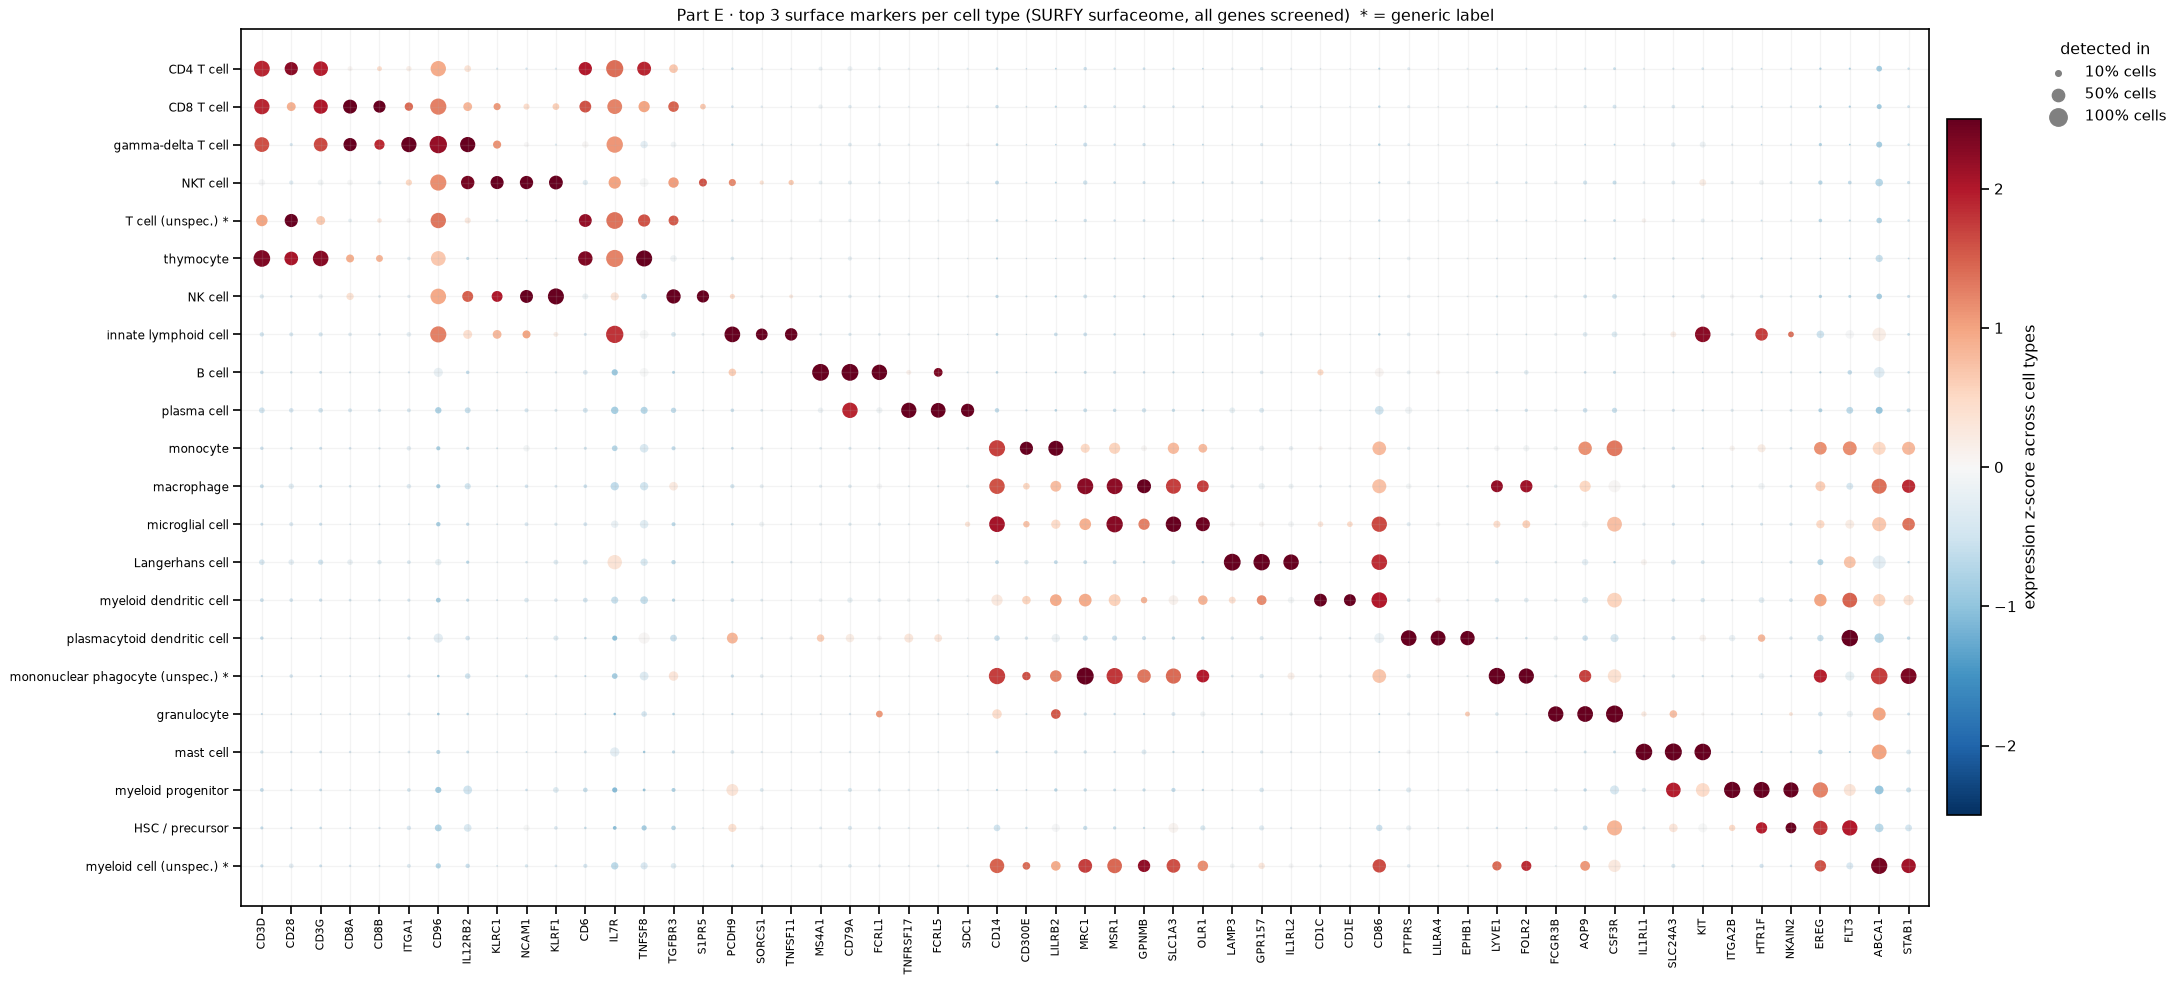

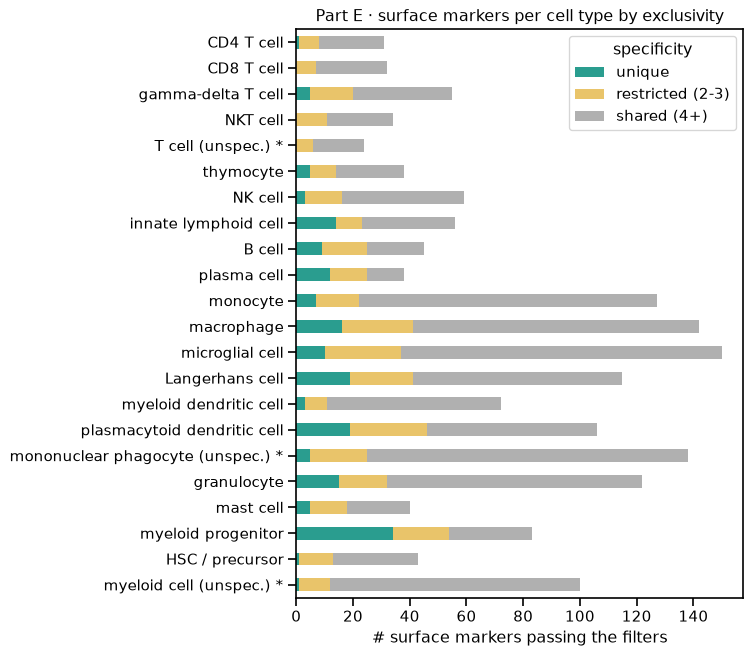

In [37]:
# E4 · dot plot: top surface markers of every cell type (dot size = % cells expressing, colour = z-score across types)
K = CONFIG["dot_markers"]
genes_dot = []
for t in CT_ORDER:
    for g in top_mk[top_mk.celltype == t].sort_values("rank")["gene"].head(K):
        if g not in genes_dot:
            genes_dot.append(g)
Zd = (expr[genes_dot] - expr[genes_dot].mean(0)) / expr[genes_dot].std(0).replace(0, 1)
Zd = Zd.loc[CT_ORDER]; Pd = pct.loc[CT_ORDER, genes_dot]
fig, ax = plt.subplots(figsize=(0.34 * len(genes_dot) + 3.5, 0.36 * len(CT_ORDER) + 2.5))
xx, yy = np.meshgrid(range(len(genes_dot)), range(len(CT_ORDER)))
sc = ax.scatter(xx.ravel(), yy.ravel(), s=Pd.to_numpy().ravel() * 170 + 1, c=Zd.to_numpy().ravel(),
                cmap="RdBu_r", vmin=-2.5, vmax=2.5, edgecolor="none")
ax.set_xticks(range(len(genes_dot))); ax.set_xticklabels(genes_dot, rotation=90, fontsize=8)
ax.set_yticks(range(len(CT_ORDER))); ax.set_yticklabels([DISP[c] for c in CT_ORDER], fontsize=9)
ax.invert_yaxis(); ax.set_xlim(-.7, len(genes_dot) - .3); ax.grid(alpha=.15)
ax.set_title(f"Part E · top {K} surface markers per cell type (SURFY surfaceome, all genes screened)  * = generic label")
cb = plt.colorbar(sc, ax=ax, fraction=.02, pad=.01); cb.set_label("expression z-score across cell types")
for p_ in (.1, .5, 1.0):
    ax.scatter([], [], s=p_ * 170 + 1, c="grey", label=f"{int(p_*100)}% cells")
ax.legend(loc="upper left", bbox_to_anchor=(1.06, 1), frameon=False, title="detected in")
plt.tight_layout(); plt.savefig(OUT / "E1_surface_marker_dotplot.png", dpi=150, bbox_inches="tight"); plt.show()

# E5 · how many markers per cell type, by exclusivity
fig, ax = plt.subplots(figsize=(8, 7))
cnt.rename(index=DISP).iloc[::-1].plot.barh(stacked=True, ax=ax, color=["#2a9d8f", "#e9c46a", "#b0b0b0"])
ax.set(xlabel="# surface markers passing the filters", ylabel="", title="Part E · surface markers per cell type by exclusivity")
plt.tight_layout(); plt.savefig(OUT / "E2_marker_counts_by_specificity.png", dpi=150); plt.show()

In [38]:
# E6 · the table: top markers per cell type (CD name in brackets when SURFY has one)
def _lab(r):
    cd = r["CD number"]
    return f"{r['gene']} ({cd})" if isinstance(cd, str) and cd and cd != r["gene"] else r["gene"]
top_mk = top_mk.assign(label=top_mk.apply(_lab, axis=1))
marker_tbl = (top_mk.sort_values(["celltype", "rank"]).groupby("celltype")["label"].apply(", ".join)
              .reindex(CT_ORDER).to_frame("top surface markers (best first)"))
marker_tbl.insert(0, "n_markers", mk.groupby("celltype").size().reindex(CT_ORDER).fillna(0).astype(int))
marker_tbl.insert(0, "n_cells", ct_meta.set_index("celltype").loc[CT_ORDER, "n_cells"])
marker_tbl.index = [DISP[c] for c in marker_tbl.index]
marker_tbl.to_csv(OUT / "E_marker_summary_table.csv")
pd.set_option("display.max_colwidth", 200)
marker_tbl

,n_cells,n_markers,top surface markers (best first)
CD4 T cell,106532,31,"CD3D (CD3d), CD28, CD3G (CD3g), ICOS (CD278), CD6, CD2, IL7R (CD127), CTLA4 (CD152), TNFSF8 (CD153), TRAT1"
CD8 T cell,75782,32,"CD8A (CD8a), CD8B (CD8b), CD3D (CD3d), CD2, CD3G (CD3g), CD96, CD6, CRTAM (CD355), TRGC2, GPR171"
gamma-delta T cell,1966,55,"ITGA1 (CD49a), CD96, IL12RB2, TIGIT, TRGC2, KIR2DL4 (CD158d), CD7, KLRC2 (CD159c), GPR171, CD8A (CD8a)"
NKT cell,5117,34,"KLRC1 (CD159a), NCAM1 (CD56), KLRF1, IL2RB (CD122), KLRB1 (CD161), IL12RB2, CD7, NCR1 (CD335), PTGDR, CD96"
T cell (unspec.) *,6049,24,"CD28, CD6, IL7R (CD127), ICOS (CD278), TRAT1, CCR4 (CD194), MPZL3, CD96, SLAMF1 (CD150), CTLA4 (CD152)"
thymocyte,5616,38,"CD3D (CD3d), TNFSF8 (CD153), CD3G (CD3g), CD6, CD28, CD5, TRABD2A, SLAMF1 (CD150), TRAT1, CCR9 (CDw199)"
NK cell,13434,59,"KLRF1, TGFBR3, S1PR5, PTGDR, KLRB1 (CD161), FCGR3A (CD16a), IL2RB (CD122), NCAM1 (CD56), NCR1 (CD335), CD7"
innate lymphoid cell,212,56,"PCDH9, SORCS1, TNFSF11 (CD254), IL7R (CD127), IL23R, KLRB1 (CD161), KIT (CD117), TNFRSF25, LPAR1, LDLRAD3"
B cell,111878,45,"MS4A1 (CD20), CD79A (CD79a), FCRL1 (CD307a), CD22, LY9 (CD229), CD79B (CD79b), ADAM28, TNFRSF13B (CD267), CD19, CNR2"
plasma cell,25838,38,"TNFRSF17 (CD269), FCRL5 (CD307e), SDC1 (CD138), CD27, SLAMF7 (CD319), CD79A (CD79a), TNFRSF13B (CD267), ABCB9, CD38, ITM2C"


Visual rapresenattion

In [39]:
# G0 · figure style + the 8 cell-type families (same colour for the same family in EVERY figure)
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle, PathPatch, Wedge
from matplotlib.path import Path as MPath
import textwrap
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
mpl.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2, "axes.edgecolor": "#c3c2b7", "axes.linewidth": .8,
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 96})
DIV = LinearSegmentedColormap.from_list("blue_grey_red", ["#1c5cab", "#f0efec", "#c93b3b"])
SEQ = LinearSegmentedColormap.from_list("blue_seq", ["#e8f1fc", "#9ec5f4", "#3987e5", "#1c5cab", "#0d366b"])
FAMILIES = [  # (name, colour, member cell types)  — order = categorical slot order
    ("T · CD4 / thymic / unspec.",   "#2a78d6", ["CD4 T cell", "T cell (unspec.)", "thymocyte"]),
    ("Cytotoxic T · CD8 / γδ / NKT", "#eb6834", ["CD8 T cell", "gamma-delta T cell", "NKT cell"]),
    ("NK / ILC",                     "#1baf7a", ["NK cell", "innate lymphoid cell"]),
    ("B lineage",                    "#eda100", ["B cell", "plasma cell"]),
    ("Monocyte / macrophage",        "#e87ba4", ["monocyte", "macrophage", "microglial cell",
                                                 "mononuclear phagocyte (unspec.)", "myeloid cell (unspec.)"]),
    ("Dendritic",                    "#008300", ["myeloid dendritic cell", "plasmacytoid dendritic cell", "Langerhans cell"]),
    ("Granulocyte / mast",           "#4a3aa7", ["granulocyte", "mast cell"]),
    ("Progenitors",                  "#e34948", ["myeloid progenitor", "HSC / precursor"]),
]
FAM_ORDER = [t for _, _, m in FAMILIES for t in m]
assert sorted(FAM_ORDER) == sorted(ct_index), "every cell type must belong to exactly one family"
FAM_OF  = {t: i for i, (_, _, m) in enumerate(FAMILIES) for t in m}
FAM_COL = {t: FAMILIES[FAM_OF[t]][1] for t in FAM_ORDER}
CD_OF   = mk_all.drop_duplicates("gene").set_index("gene")["CD number"].to_dict()
if "shared" not in globals():      # number of organs where both types have a group (>=10 cells); same definition as in F0
    _op = pd.crosstab(meta_b["celltype"], meta_b["organ"]).reindex(ct_index).gt(0).astype(int).to_numpy()
    shared = _op @ _op.T
shared_df = pd.DataFrame(shared, index=ct_index, columns=ct_index)

def _glabel(g):
    cd = CD_OF.get(g)
    return f"{g} ({cd})" if isinstance(cd, str) and cd and cd.lower() != g.lower() else g

def _title(ax_or_fig, title, sub, x=0.0, y=1.0, fig=None):
    fig = fig or ax_or_fig
    H = fig.get_figheight() * 72
    fig.text(x, y, title, fontsize=15, fontweight="bold", color=INK, ha="left", va="top")
    fig.text(x, y - 27 / H, sub, fontsize=9.5, color=INK2, ha="left", va="top", linespacing=1.35)

def _family_legend(fig, x=0.02, y=0.012, ncol=4):
    hs = [Rectangle((0, 0), 1, 1, color=c) for _, c, _ in FAMILIES]
    fig.legend(hs, [n for n, _, _ in FAMILIES], loc="lower left", bbox_to_anchor=(x, y), ncol=ncol, frameon=False,
               fontsize=9, handlelength=1.1, handleheight=1.1, columnspacing=1.6, title="cell-type family", title_fontsize=9,
               alignment="left")
print("families:", {n: len(m) for n, _, m in FAMILIES})

families: {'T · CD4 / thymic / unspec.': 3, 'Cytotoxic T · CD8 / γδ / NKT': 3, 'NK / ILC': 2, 'B lineage': 2, 'Monocyte / macrophage': 5, 'Dendritic': 3, 'Granulocyte / mast': 2, 'Progenitors': 2}


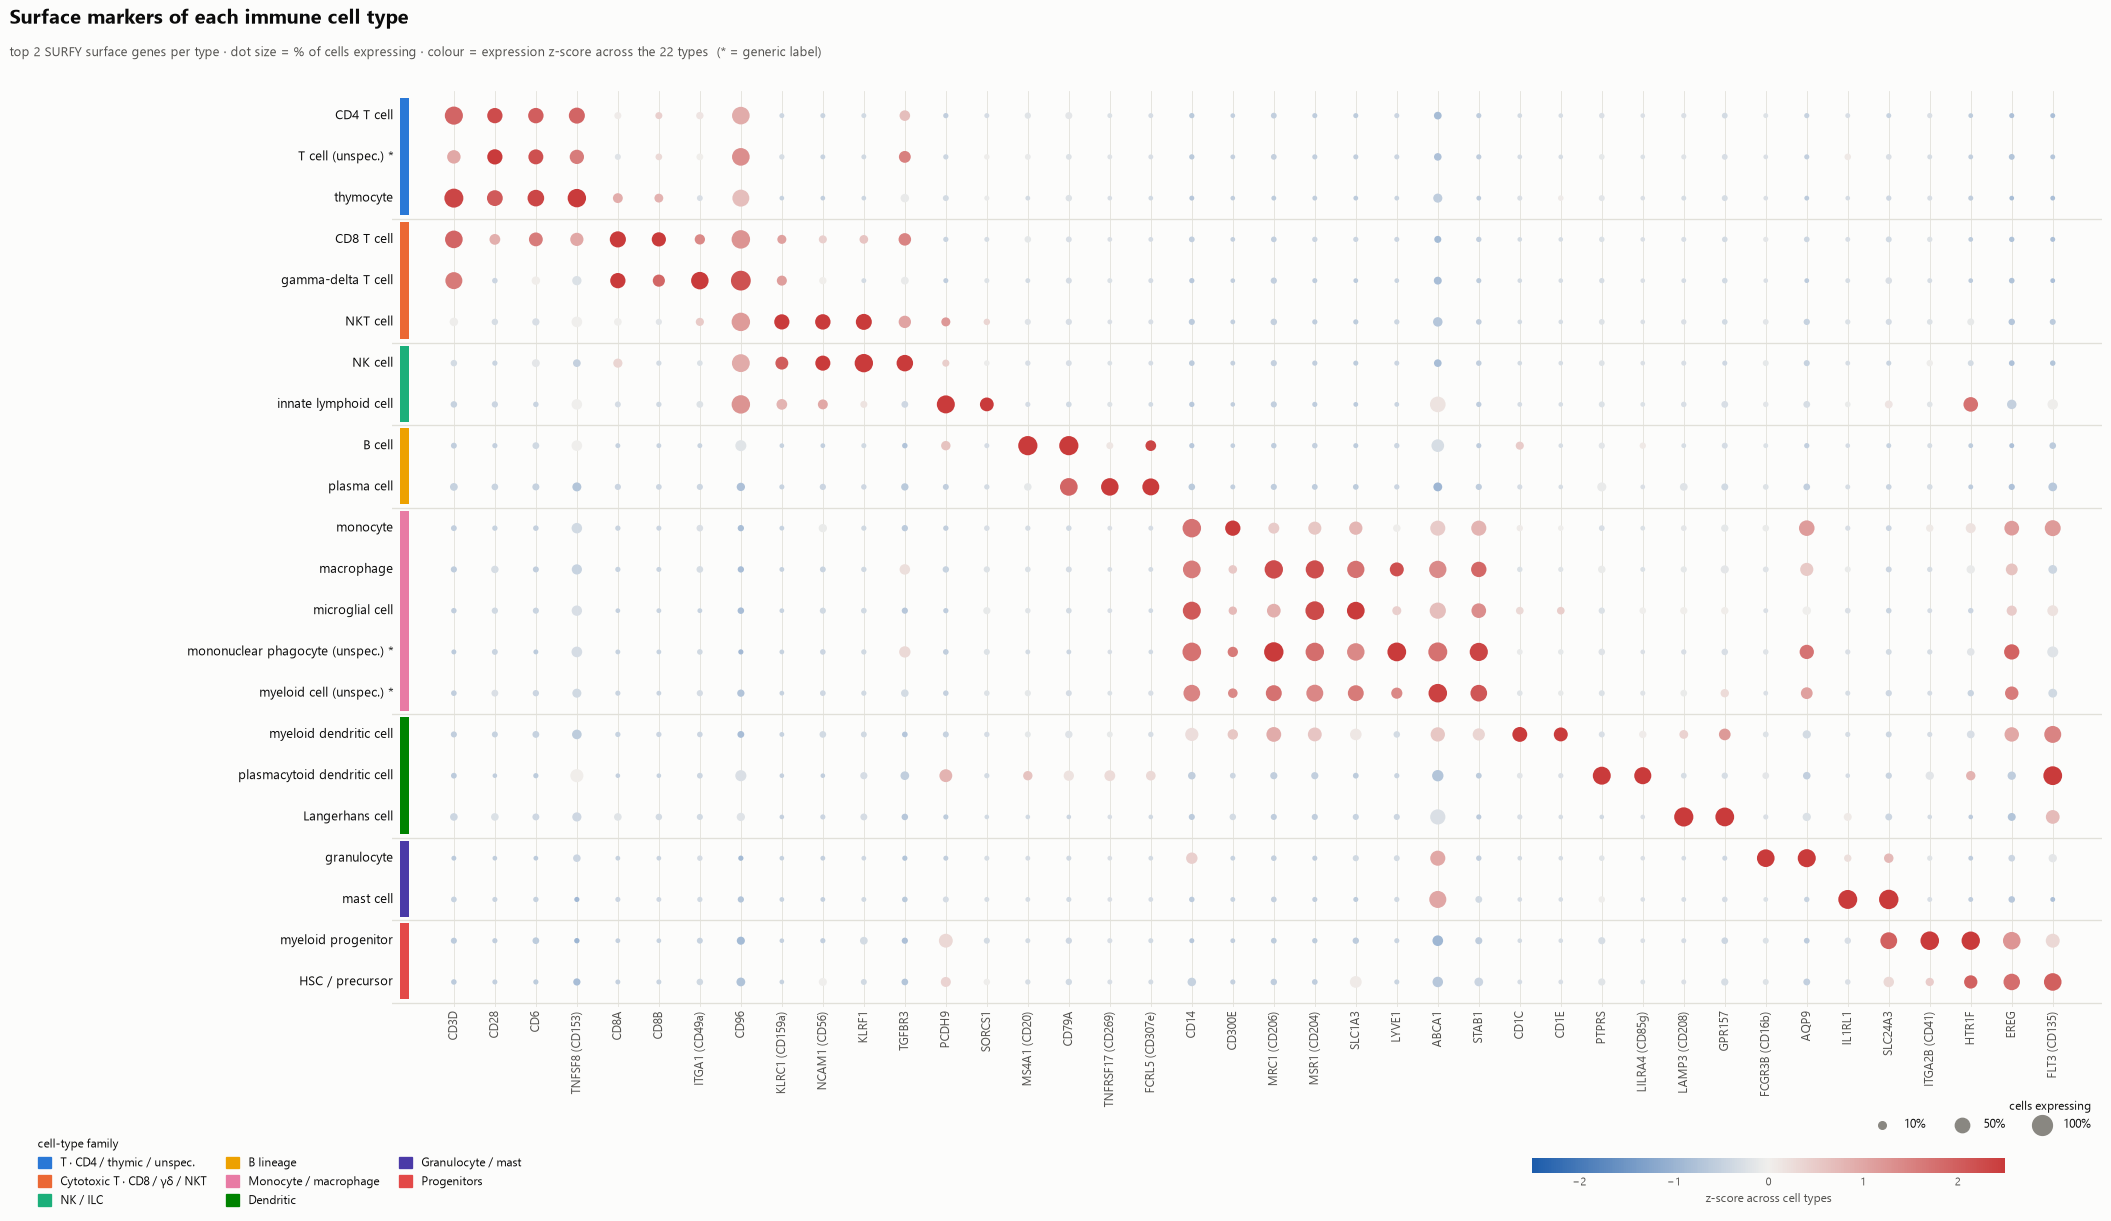

In [40]:
# E3 · dot plot by family — the 2 best surface markers of every cell type
def fig_E_dotplot(K=2, fname="E3_marker_dotplot_by_family.png"):
    genes = []
    for t in FAM_ORDER:
        for g in top_mk[top_mk.celltype == t].sort_values("rank")["gene"].head(K):
            if g not in genes:
                genes.append(g)
    ex = mk_all.pivot(index="celltype", columns="gene", values="expr_log1p").loc[FAM_ORDER, genes]
    pc = mk_all.pivot(index="celltype", columns="gene", values="pct_in").loc[FAM_ORDER, genes]
    z = (ex - ex.mean()) / ex.std().replace(0, 1)
    nT, nG = len(FAM_ORDER), len(genes)
    H_ = 0.42 * nT + 3.7
    fig, ax = plt.subplots(figsize=(0.40 * nG + 6.4, H_))
    xx, yy = np.meshgrid(range(nG), range(nT))
    sc = ax.scatter(xx.ravel(), yy.ravel(), s=12 + 210 * pc.to_numpy().ravel(), c=z.to_numpy().ravel(),
                    cmap=DIV, vmin=-2.5, vmax=2.5, edgecolor="none", zorder=3)
    ax.set_xlim(-1.5, nG + 0.2); ax.set_ylim(nT - .4, -.6)
    ax.set_xticks(range(nG)); ax.set_xticklabels([_glabel(g) for g in genes], rotation=90, fontsize=9)
    ax.set_yticks([]); ax.spines[["left", "bottom"]].set_visible(False); ax.tick_params(length=0)
    ax.grid(axis="x", color=GRID, lw=.6, zorder=0)
    row = 0
    for name, col, members in FAMILIES:
        ax.add_patch(Rectangle((-1.32, row - .42), .22, len(members) - .16, color=col, clip_on=False, lw=0))
        for k, t in enumerate(members):
            ax.text(-1.5 + 0.02, row + k, DISP[t], ha="right", va="center", fontsize=10, color=INK, clip_on=False)
        row += len(members)
        ax.axhline(row - .5, color=GRID, lw=1, zorder=1)
    _title(fig, "Surface markers of each immune cell type", f"top {K} SURFY surface genes per type · dot size = % of cells expressing · colour = expression z-score across the 22 types  (* = generic label)",
           x=0.012, y=0.985, fig=fig)
    cax = fig.add_axes([0.72, 0.62 / H_, 0.22, 0.012])
    cb = fig.colorbar(sc, cax=cax, orientation="horizontal"); cb.set_label("z-score across cell types", fontsize=9, color=INK2)
    cb.outline.set_visible(False); cax.tick_params(labelsize=8, length=0)
    hs = [ax.scatter([], [], s=12 + 210 * p_, color="#898781", label=f"{int(p_*100)}%") for p_ in (.1, .5, 1.0)]
    fig.legend(handles=hs, loc="lower right", bbox_to_anchor=(0.985, 0.95 / H_), ncol=3, frameon=False, fontsize=9,
               title="cells expressing", title_fontsize=9, alignment="right")
    _family_legend(fig, ncol=3)
    fig.subplots_adjust(left=0.19, right=0.985, top=1 - 1.05 / H_, bottom=2.35 / H_)
    fig.savefig(OUT / fname, dpi=150); plt.show()

fig_E_dotplot()

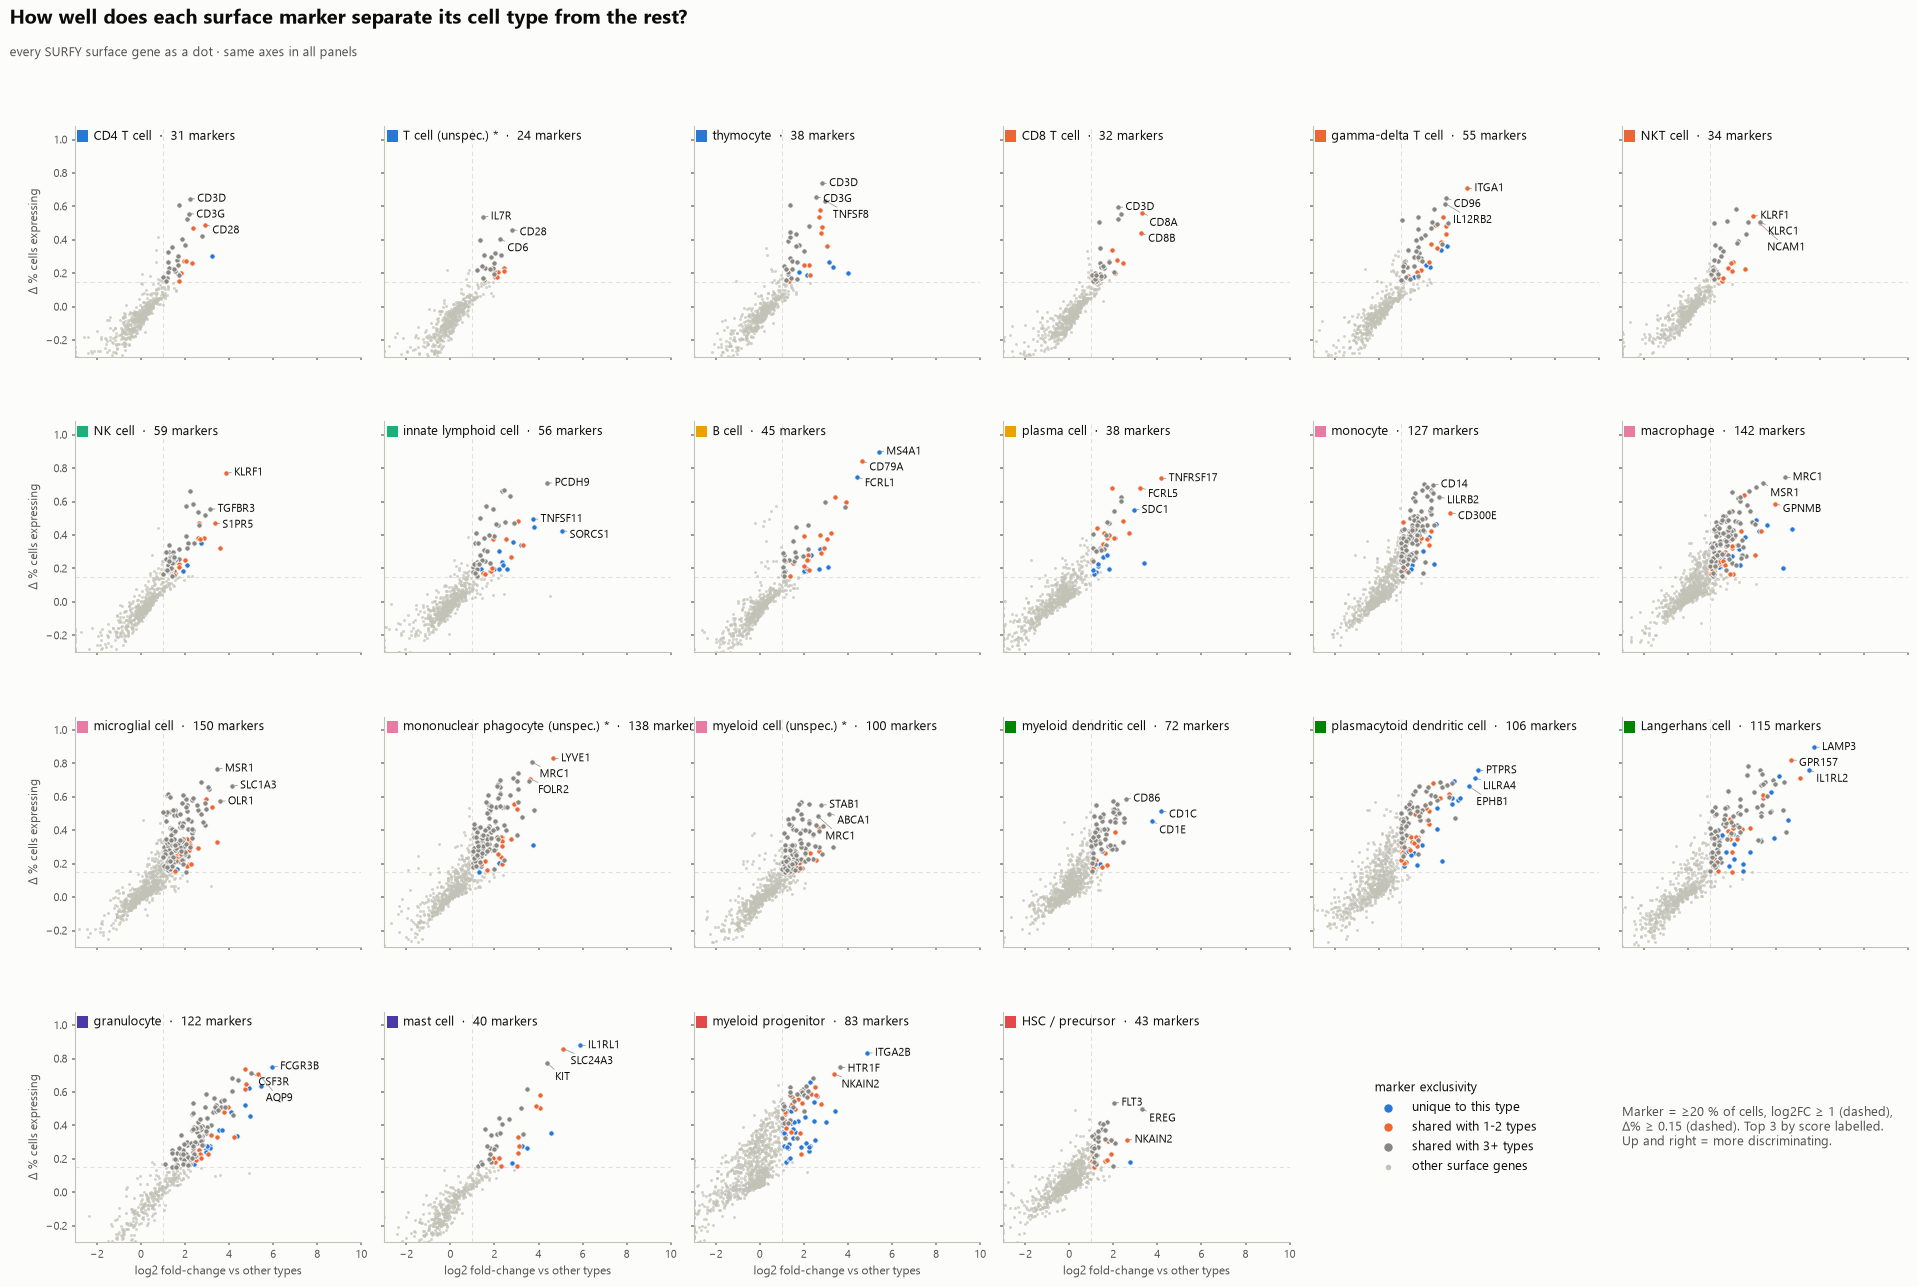

In [41]:
# E4 · how discriminating are the markers? one panel per cell type (all surface genes)
def fig_E_small_multiples(fname="E4_marker_discrimination_small_multiples.png"):
    CLS = {"unique": ("#2a78d6", "unique to this type"), "restricted (2-3)": ("#eb6834", "shared with 1-2 types"),
           "shared (4+)": ("#898781", "shared with 3+ types")}
    fig, axs = plt.subplots(4, 6, figsize=(20, 13.6), sharex=True, sharey=True)
    axl = axs.ravel()
    for ax, t in zip(axl, FAM_ORDER):
        d = mk_all[(mk_all.celltype == t) & (mk_all.pct_in >= 0.05)]
        ax.scatter(d.log2FC.clip(-3, 9), d.dpct, s=5, color="#c3c2b7", lw=0, alpha=.7, zorder=2)
        m = d[d.is_marker]
        for cls, (col, _) in CLS.items():
            mm = m[m.specificity == cls]
            ax.scatter(mm.log2FC.clip(-3, 9), mm.dpct, s=16, color=col, lw=.6, edgecolor=SURF, zorder=3)
        ax.axvline(1, color=GRID, lw=.8, ls=(0, (4, 3)), zorder=1); ax.axhline(.15, color=GRID, lw=.8, ls=(0, (4, 3)), zorder=1)
        pts = [(r.gene, (min(r.log2FC, 9), r.dpct)) for r in top_mk[top_mk.celltype == t].sort_values("rank").head(3).itertuples()]
        prev = None
        for g, (x, y) in sorted(pts, key=lambda p: -p[1][1]):
            yy = y if prev is None else min(y, prev - .095); prev = yy
            right = x < 6.2
            ax.annotate(g, (x, y), xytext=(x + (.35 if right else -.35), yy), fontsize=8, color=INK, va="center",
                        ha="left" if right else "right", arrowprops=dict(arrowstyle="-", lw=.5, color=MUTED, shrinkA=0, shrinkB=2))
        ax.add_patch(Rectangle((-2.9, .985), .5, .07, color=FAM_COL[t], lw=0, clip_on=False))
        ax.text(-2.15, 1.02, f"{DISP[t]}  ·  {int(m.shape[0])} markers", fontsize=9.5, color=INK, va="center", ha="left")
        ax.set_xlim(-3, 10); ax.set_ylim(-.3, 1.08)
        ax.grid(False); ax.tick_params(labelsize=8, length=2)
    for ax in axl[len(FAM_ORDER):]:
        ax.axis("off")
    for ax in axs[-1, :]:
        ax.set_xlabel("log2 fold-change vs other types", fontsize=9)
    for ax in axs[:, 0]:
        ax.set_ylabel("Δ % cells expressing", fontsize=9)
    leg = axl[len(FAM_ORDER)]
    hs = [leg.scatter([], [], s=28, color=c, label=l) for c, l in CLS.values()]
    hs.append(leg.scatter([], [], s=10, color="#c3c2b7", label="other surface genes"))
    leg.legend(handles=hs, loc="center", frameon=False, fontsize=10, title="marker exclusivity", title_fontsize=10, alignment="left")
    axl[len(FAM_ORDER) + 1].text(0, .5, "Marker = ≥20 % of cells, log2FC ≥ 1 (dashed),\nΔ% ≥ 0.15 (dashed). Top 3 by score labelled.\nUp and right = more discriminating.",
                                 fontsize=9.5, color=INK2, va="center", transform=axl[len(FAM_ORDER) + 1].transAxes)
    _title(fig, "How well does each surface marker separate its cell type from the rest?",
           "every SURFY surface gene as a dot · same axes in all panels", x=0.006, y=0.995, fig=fig)
    fig.subplots_adjust(left=0.04, right=0.995, top=0.905, bottom=0.05, hspace=.28, wspace=.08)
    fig.savefig(OUT / fname, dpi=140); plt.show()

fig_E_small_multiples()

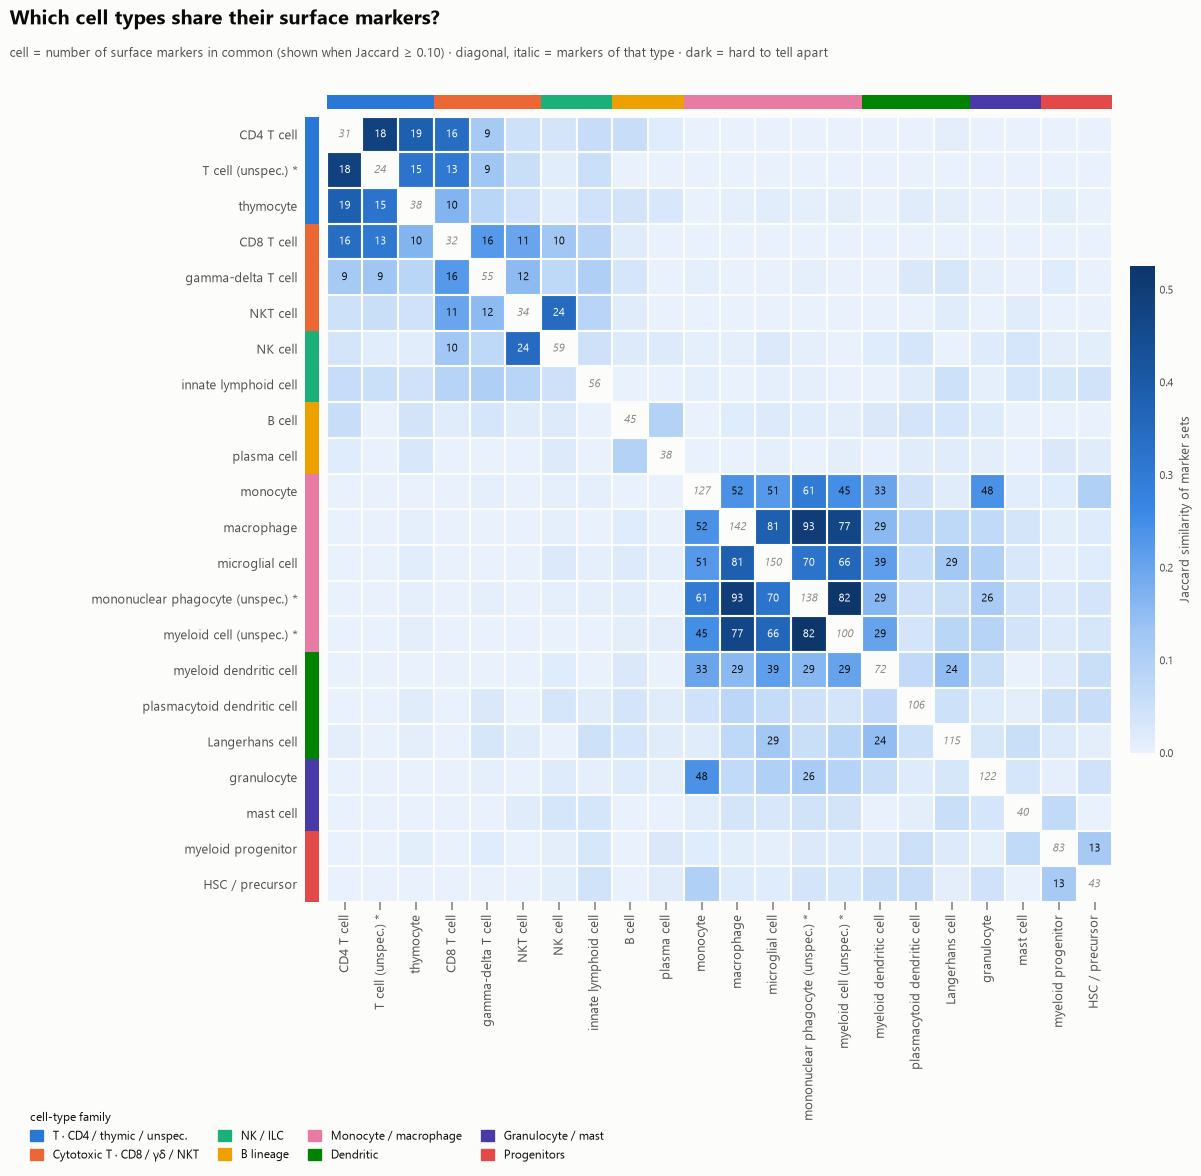

In [42]:
# E5 · which cell types are hard to tell apart by surface markers? marker-set overlap between types
def fig_E_overlap(fname="E5_marker_sharing_matrix.png"):
    sets = {t: set(mk[mk.celltype == t]["gene"]) for t in FAM_ORDER}
    n = len(FAM_ORDER)
    C = np.array([[len(sets[a] & sets[b]) for b in FAM_ORDER] for a in FAM_ORDER])
    J = np.array([[len(sets[a] & sets[b]) / max(1, len(sets[a] | sets[b])) for b in FAM_ORDER] for a in FAM_ORDER], float)
    np.fill_diagonal(J, np.nan)
    fig, ax = plt.subplots(figsize=(12.5, 12.4))
    vmax = np.nanmax(J)
    im = ax.imshow(J, cmap=SEQ, vmin=0, vmax=vmax, aspect="equal")
    ax.set_xticks(range(n)); ax.set_xticklabels([DISP[t] for t in FAM_ORDER], rotation=90, fontsize=9.5)
    ax.set_yticks(range(n)); ax.set_yticklabels([DISP[t] for t in FAM_ORDER], fontsize=9.5)
    ax.tick_params(length=0, axis="y", pad=22); ax.spines[["left", "bottom"]].set_visible(False)
    ax.set_xticks(np.arange(-.5, n), minor=True); ax.set_yticks(np.arange(-.5, n), minor=True)
    ax.grid(which="minor", color=SURF, lw=1.6); ax.tick_params(which="minor", length=0)
    for i in range(n):
        for j in range(n):
            if i == j:
                ax.text(j, i, f"{len(sets[FAM_ORDER[i]])}", ha="center", va="center", fontsize=8, color=MUTED, style="italic")
            elif J[i, j] >= .1:
                ax.text(j, i, f"{C[i, j]}", ha="center", va="center", fontsize=8.5,
                        color="white" if J[i, j] > .55 * vmax else INK)
    for i, t in enumerate(FAM_ORDER):
        for pos in (-1.05, ):
            ax.add_patch(Rectangle((-1.1, i - .5), .38, 1, color=FAM_COL[t], clip_on=False, lw=0))
            ax.add_patch(Rectangle((i - .5, -1.1), 1, .38, color=FAM_COL[t], clip_on=False, lw=0))
    cb = fig.colorbar(im, ax=ax, fraction=.032, pad=.02, shrink=.62); cb.set_label("Jaccard similarity of marker sets", fontsize=9.5, color=INK2)
    cb.outline.set_visible(False); cb.ax.tick_params(labelsize=8.5, length=0)
    _title(fig, "Which cell types share their surface markers?",
           "cell = number of surface markers in common (shown when Jaccard ≥ 0.10) · diagonal, italic = markers of that type · dark = hard to tell apart",
           x=0.012, y=0.985, fig=fig)
    _family_legend(fig, y=0.008, ncol=4)
    fig.subplots_adjust(left=0.22, right=0.97, top=0.895, bottom=0.235)
    fig.savefig(OUT / fname, dpi=150); plt.show()

fig_E_overlap()

PART F  with which other cells can each cell type "talk" / recognise?

Ligand–receptor screening on the same pooled pseudobulk, using the **LIANA consensus** resource (curated union of
CellPhoneDB, CellChat, ICELLNET, connectomeDB, …; complexes = weakest subunit). 

In [43]:
# F0 · build every active sender -> receiver ligand-receptor interaction
lrt = lr_res[lr_res["lig"].map(lambda l: all(g in gt.index for g in l)) &
             lr_res["rec"].map(lambda l: all(g in gt.index for g in l))].reset_index(drop=True)
print(f"L-R pairs: {len(lr_res)} in resource -> {len(lrt)} fully measurable in Tabula")

expr_np = {g: expr[g].to_numpy() for g in gt.index}; pct_np = {g: pct[g].to_numpy() for g in gt.index}
surf_set = set(surf_genes)
org_pres = pd.crosstab(meta_b["celltype"], meta_b["organ"]).reindex(ct_index).gt(0).astype(int)
shared = org_pres.to_numpy() @ org_pres.to_numpy().T              # T x T: number of shared organs
thr = CONFIG["min_pct_lr"]; bgv = bg_ok.astype(float); nbg = bgv.sum()

def _spec(p):                                                      # p[t] - mean of p over the non-generic *other* types
    return p - (p[bg_ok].sum() - p * bgv) / (nbg - bgv)

chunks = []
for k, (lig, rec) in enumerate(zip(lrt["lig"], lrt["rec"])):
    Lp = np.min([pct_np[g] for g in lig], 0);  Rp = np.min([pct_np[g] for g in rec], 0)
    Le = np.min([expr_np[g] for g in lig], 0); Re = np.min([expr_np[g] for g in rec], 0)
    snd = np.where(Lp >= thr)[0]; rcv = np.where(Rp >= thr)[0]
    if len(snd) == 0 or len(rcv) == 0:
        continue
    a_, b_ = np.meshgrid(snd, rcv, indexing="ij"); a_, b_ = a_.ravel(), b_.ravel()
    ok = shared[a_, b_] > 0
    a_, b_ = a_[ok], b_[ok]
    if len(a_) == 0:
        continue
    Ls, Rs = _spec(Lp), _spec(Rp)
    chunks.append(np.column_stack([np.full(len(a_), k), a_, b_, Lp[a_], Rp[b_], Le[a_], Re[b_], Ls[a_], Rs[b_], shared[a_, b_]]))
arr = np.vstack(chunks)
inter = pd.DataFrame(arr, columns=["pair", "s", "r", "pct_L", "pct_R", "expr_L", "expr_R", "spec_L", "spec_R", "shared_organs"])
inter[["pair", "s", "r", "shared_organs"]] = inter[["pair", "s", "r", "shared_organs"]].astype(int)
inter["sender"] = np.array(ct_index)[inter["s"]]; inter["receiver"] = np.array(ct_index)[inter["r"]]
inter["ligand"] = lrt["ligand"].to_numpy()[inter["pair"]]; inter["receptor"] = lrt["receptor"].to_numpy()[inter["pair"]]
mode_pair = np.array(["membrane" if any(g in surf_set for g in l) else "soluble" for l in lrt["lig"]])
inter["mode"] = mode_pair[inter["pair"]]
inter["strength"] = np.sqrt(inter["expr_L"] * inter["expr_R"])
inter["characteristic"] = (inter["spec_L"] >= CONFIG["min_spec_lr"]) & (inter["spec_R"] >= CONFIG["min_spec_lr"])
inter.drop(columns=["s", "r"]).round(4).to_csv(OUT / "F_interactions_all.csv.gz", index=False)
ch = inter[inter.characteristic]
print(f"active interactions (sender->receiver x L-R pair): {len(inter):,}  ·  characteristic: {len(ch):,}  "
      f"·  membrane {int((inter['mode']=='membrane').sum()):,} / soluble {int((inter['mode']=='soluble').sum()):,}")
inter.groupby("mode").agg(n=("pair", "size"), characteristic=("characteristic", "sum"), mean_strength=("strength", "mean")).round(3)

L-R pairs: 4624 in resource -> 4594 fully measurable in Tabula


active interactions (sender->receiver x L-R pair): 90,468  ·  characteristic: 8,903  ·  membrane 28,380 / soluble 62,088


,n,characteristic,mean_strength
mode,,,
membrane,28380,3278,0.655
soluble,62088,5625,0.657


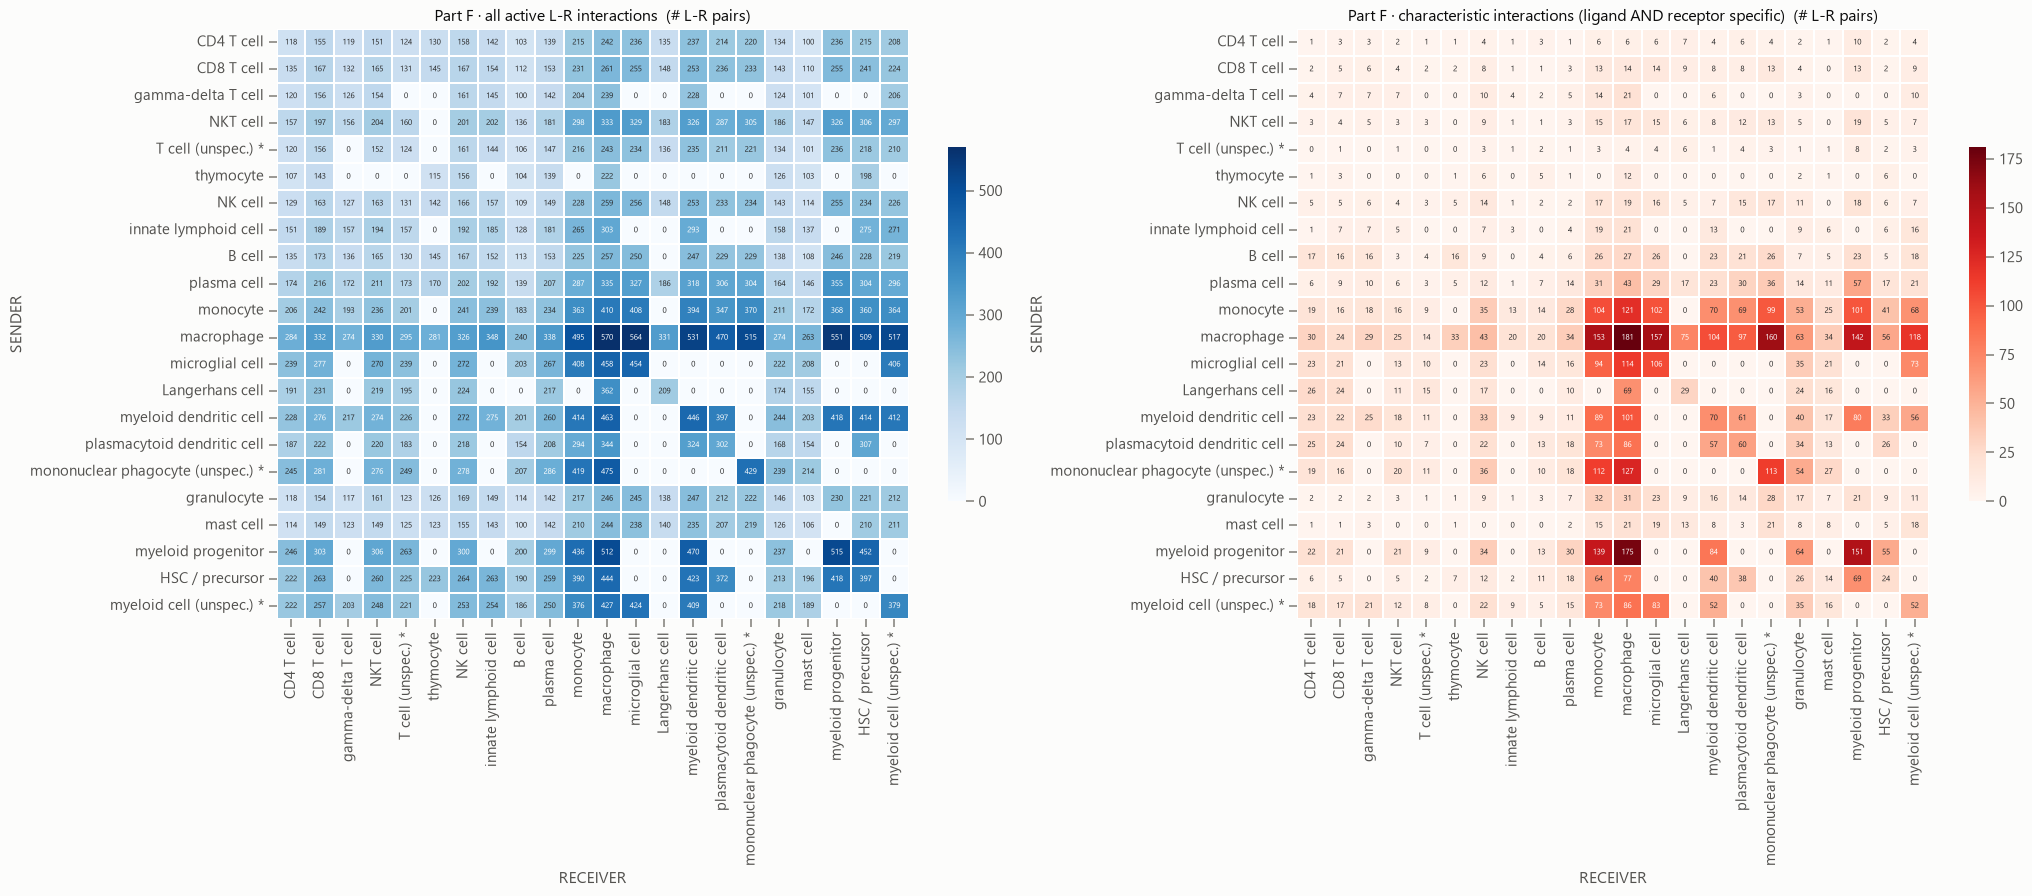

In [44]:
# F1 · sender x receiver matrices: all active interactions vs characteristic ones
def sr(df, val=None):
    m = df.groupby(["sender", "receiver"]).size() if val is None else df.groupby(["sender", "receiver"])[val].sum()
    return m.unstack().reindex(index=CT_ORDER, columns=CT_ORDER).fillna(0)
n_all, n_char, s_char = sr(inter), sr(ch), sr(ch, "strength")
for nm, m in (("all_active", n_all), ("characteristic", n_char), ("characteristic_strength", s_char)):
    m.to_csv(OUT / f"F_sender_receiver_{nm}.csv")
fig, axs = plt.subplots(1, 2, figsize=(22, 9.5))
for ax, m, cm, ttl in ((axs[0], n_all, "Blues", "all active L-R interactions"),
                       (axs[1], n_char, "Reds", "characteristic interactions (ligand AND receptor specific)")):
    mm = m.astype(int).rename(index=DISP, columns=DISP)
    sns.heatmap(mm, cmap=cm, annot=True, fmt="d", annot_kws={"size": 6}, cbar_kws={"shrink": .6}, ax=ax, linewidths=.3, linecolor="white")
    ax.set(xlabel="RECEIVER", ylabel="SENDER", title=f"Part F · {ttl}  (# L-R pairs)")
plt.tight_layout(); plt.savefig(OUT / "F1_sender_receiver_matrices.png", dpi=150); plt.show()

In [45]:
# F2 · per cell type: best partners (as sender / as receiver) and the L-R pairs that characterise it
def _top_partners(mat, t, axis, n=3):
    v = (mat.loc[t] if axis == "out" else mat[t]).drop(t)
    v = v[v > 0].sort_values(ascending=False).head(n)
    return ", ".join(f"{DISP[i]} ({x:.0f})" for i, x in v.items())

def _top_pairs(df, t, role, n=5):
    d = df[df[role] == t].copy()
    d["lab"] = d["ligand"] + "->" + d["receptor"] + (" [" + d["mode"].str[:1] + "]")
    d = d.groupby("lab").agg(w=("strength", "max"), n=("strength", "size")).sort_values(["n", "w"], ascending=False).head(n)
    return ", ".join(f"{i} x{r.n}" for i, r in d.iterrows())

rows = []
for t in CT_ORDER:
    rows.append({"celltype": DISP[t],
                 "n_shared_organs_max": int(shared[ct2i[t]][[i for i in range(T) if i != ct2i[t]]].max()),
                 "talks to (top receivers, strength)": _top_partners(s_char, t, "out"),
                 "listened to by / receives from (top senders)": _top_partners(s_char, t, "in"),
                 "characteristic pairs it SENDS ([m]embrane/[s]oluble, xN receivers)": _top_pairs(ch, t, "sender"),
                 "characteristic pairs it RECEIVES (xN senders)": _top_pairs(ch, t, "receiver")})
partners = pd.DataFrame(rows)
partners.to_csv(OUT / "F_partners_per_celltype.csv", index=False)
partners

,celltype,n_shared_organs_max,"talks to (top receivers, strength)",listened to by / receives from (top senders),"characteristic pairs it SENDS ([m]embrane/[s]oluble, xN receivers)",characteristic pairs it RECEIVES (xN senders)
0,CD4 T cell,26,"Langerhans cell (6), monocyte (6), myeloid progenitor (6)","Langerhans cell (32), macrophage (32), myeloid dendritic cell (29)","MAML2->NOTCH2 [s] x8.0, CD48->CD2 [m] x7.0, CD28->CD86 [m] x7.0, LTB->TNFRSF1A [s] x7.0, CD40LG->ITGA5_ITGB1 [m] x7.0","HLA-DRA->CD4 [m] x11.0, ALCAM->CD6 [m] x10.0, HLA-DRB1->CD4 [m] x10.0, LGALS1->CD69 [s] x9.0, HLA-DPB1->CD4 [m] x8.0"
1,CD8 T cell,26,"macrophage (12), mononuclear phagocyte (unspec.) * (12), microglial cell (12)","Langerhans cell (26), macrophage (25), myeloid dendritic cell (23)","IFNG->IFNGR1_IFNGR2 [s] x9.0, SPON2->ITGB2 [s] x8.0, TIGIT->NECTIN2 [m] x8.0, CD48->CD2 [m] x7.0, SPON2->ITGA4 [s] x7.0","HLA-DRA->LAG3 [m] x11.0, ALCAM->CD6 [m] x10.0, HLA-DRB1->LAG3 [m] x10.0, LGALS1->CD69 [s] x9.0, NECTIN2->CD96 [m] x8.0"
2,gamma-delta T cell,2,"macrophage (20), monocyte (14), NK cell (12)","macrophage (32), myeloid dendritic cell (27), monocyte (23)","TGFB1->CXCR4 [s] x6.0, TFF3->CXCR4 [s] x6.0, CLEC2D->KLRB1 [m] x5.0, GZMB->IGF2R [s] x4.0, ADAM28->ITGA4 [m] x4.0","CD48->CD2 [m] x7.0, LGALS1->CD69 [s] x5.0, ADAM28->ITGA4 [m] x5.0, HLA-DRA->LAG3 [m] x5.0, HLA-DRB1->LAG3 [m] x5.0"
3,NKT cell,18,"macrophage (15), monocyte (14), microglial cell (13)","macrophage (29), mononuclear phagocyte (unspec.) * (23), monocyte (22)","IFNG->IFNGR1_IFNGR2 [s] x9.0, SPON2->ITGB2 [s] x8.0, TIGIT->NECTIN2 [m] x8.0, SPON2->ITGA4 [s] x7.0, SPON2->ITGA5 [s] x7.0","LGALS1->CD69 [s] x9.0, NECTIN2->CD96 [m] x8.0, IL18->IL18R1_IL18RAP [s] x8.0, IL18->IL18_IL18R1_IL18RAP [s] x8.0, NECTIN2->TIGIT [m] x8.0"
4,T cell (unspec.) *,17,"Langerhans cell (6), myeloid progenitor (5), NK cell (4)","Langerhans cell (18), macrophage (16), myeloid dendritic cell (14)","CD28->CD86 [m] x7.0, CD40LG->ITGA5_ITGB1 [m] x7.0, CD40LG->ITGAM_ITGB2 [m] x6.0, CD40LG->CD9 [m] x5.0, CLEC2D->KLRB1 [m] x4.0","ALCAM->CD6 [m] x10.0, LGALS1->CD69 [s] x9.0, NECTIN2->CD96 [m] x8.0, S100A8->CD69 [s] x7.0, CD58->CD2 [m] x7.0"
5,thymocyte,1,"macrophage (10), NK cell (6), B cell (6)","macrophage (35), B cell (16), HSC / precursor (9)","CD48->CD2 [m] x4.0, CD40LG->ITGAM_ITGB2 [m] x3.0, MIF->CD44_CD74 [s] x2.0, MAML2->NOTCH2 [s] x2.0, ADAM23->ITGA4 [m] x2.0","CD48->CD2 [m] x5.0, S100A8->CD69 [s] x3.0, HLA-DRA->CD4 [m] x3.0, BSG->SLC16A7 [m] x3.0, LGALS1->CD69 [s] x2.0"
6,NK cell,22,"monocyte (20), macrophage (20), mononuclear phagocyte (unspec.) * (19)","macrophage (51), monocyte (47), mononuclear phagocyte (unspec.) * (45)","CD47->SIRPA [m] x9.0, IFNG->IFNGR1_IFNGR2 [s] x9.0, SPON2->ITGB2 [s] x8.0, SELPLG->ITGB2 [m] x8.0, SPON2->ITGA4 [s] x7.0","LGALS1->CD69 [s] x9.0, SIRPA->CD47 [m] x9.0, S100A9->ITGB2 [s] x8.0, NECTIN2->CD96 [m] x8.0, ITGB2->CD226 [m] x8.0"
7,innate lymphoid cell,3,"monocyte (19), macrophage (18), myeloid cell (unspec.) * (15)","macrophage (24), monocyte (15), myeloid cell (unspec.) * (11)","ADAM10->IL6R [m] x6.0, MAML2->NOTCH2 [s] x5.0, ADAM10->NOTCH2 [m] x5.0, ADAM10->TSPAN5 [m] x5.0, SPON2->ITGB2 [s] x5.0","S100A8->CD69 [s] x5.0, LGALS1->CD69 [s] x5.0, CLEC2D->KLRB1 [m] x4.0, ICAM1->IL2RA [m] x4.0, NECTIN2->CD96 [m] x4.0"
8,B cell,24,"microglial cell (23), macrophage (23), mononuclear phagocyte (unspec.) * (23)","macrophage (24), monocyte (20), mononuclear phagocyte (unspec.) * (16)","HLA-DRA->CD4 [m] x9.0, HLA-DRB1->CD4 [m] x9.0, HLA-DPB1->CD4 [m] x9.0, HLA-DPA1->CD4 [m] x9.0, HLA-DQA1->CD4 [m] x9.0","LGALS1->CD69 [s] x8.0, LGALS9->PTPRK [s] x8.0, S100A8->CD69 [s] x7.0, CXCL8->CD79A [s] x7.0, APP->CD74 [m] x6.0"
9,plasma cell,22,"macrophage (27), myeloid progenitor (26), mononuclear phagocyte (unspec.) * (25)","macrophage (27), monocyte (22), mononuclear phagocyte (unspec.) * (18)","LGALS1->CD69 [s] x11.0, HLA-DOB->CD4 [m] x9.0, ANXA2->TLR2 [s] x8.0, CD38->PECAM1 [m] x8.0, MIF->CD44_CD74

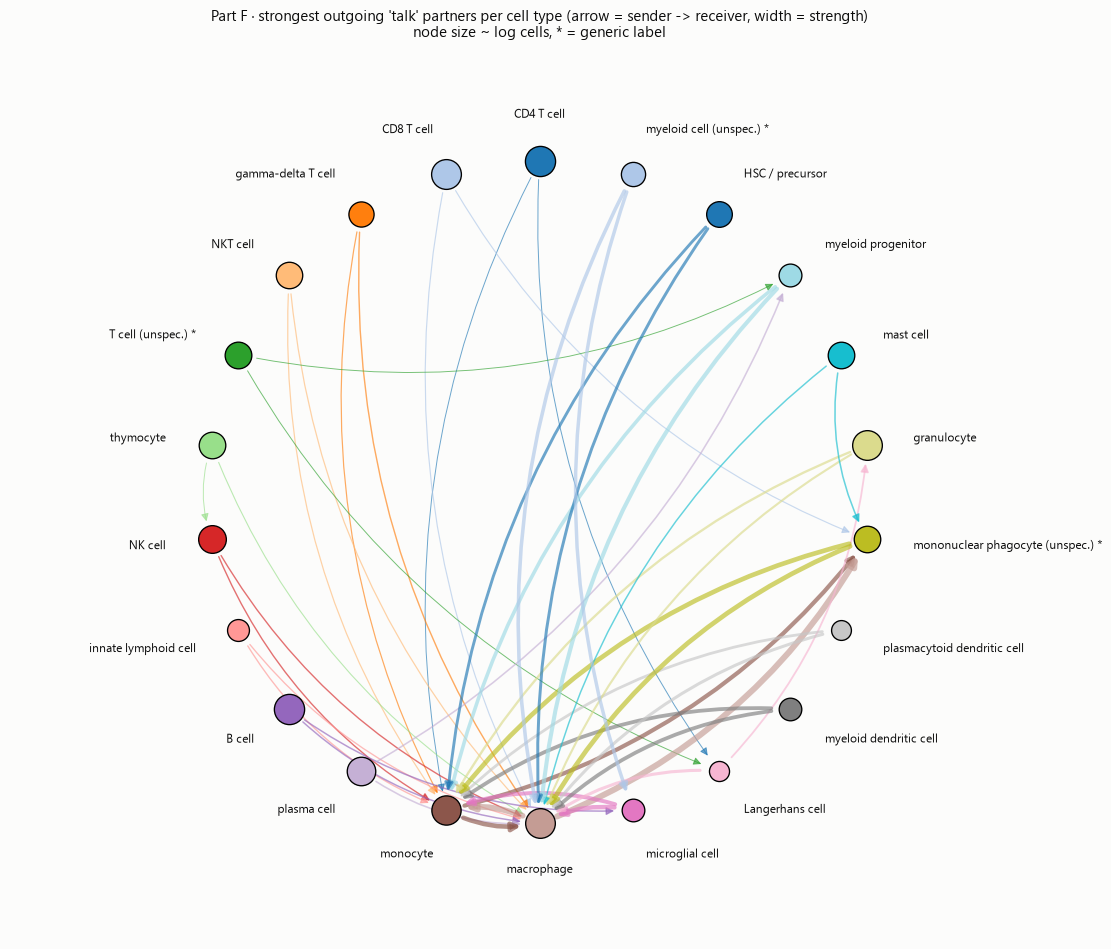

In [46]:
# F3 · network: each cell type's 2 strongest outgoing partners (characteristic interactions, excluding autocrine)
from matplotlib.patches import FancyArrowPatch
ang = np.linspace(0, 2 * np.pi, T, endpoint=False) + np.pi / 2
xy = {t: (np.cos(a), np.sin(a)) for t, a in zip(CT_ORDER, ang)}
smax = s_char.to_numpy().max() or 1
fig, ax = plt.subplots(figsize=(12, 12)); ax.set_aspect("equal"); ax.axis("off")
pal = sns.color_palette("tab20", T)
for i, t in enumerate(CT_ORDER):
    v = s_char.loc[t].drop(t).sort_values(ascending=False).head(2)
    for u, w in v.items():
        if w <= 0:
            continue
        ax.add_patch(FancyArrowPatch(xy[t], xy[u], connectionstyle="arc3,rad=0.18", arrowstyle="-|>", mutation_scale=12,
                                     lw=.6 + 4 * w / smax, color=pal[i], alpha=.65, shrinkA=14, shrinkB=14))
nc = ct_meta.set_index("celltype").loc[CT_ORDER, "n_cells"].to_numpy()
for i, t in enumerate(CT_ORDER):
    ax.scatter(*xy[t], s=60 + 90 * np.log10(nc[i]), color=pal[i], edgecolor="k", zorder=3)
    x, y = xy[t]; ax.text(1.14 * x, 1.14 * y, DISP[t], ha="left" if x > 0.05 else "right" if x < -0.05 else "center",
                          va="center", fontsize=9)
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.35, 1.35)
ax.set_title("Part F · strongest outgoing 'talk' partners per cell type (arrow = sender -> receiver, width = strength)\n"
             "node size ~ log cells, * = generic label", fontsize=11)
plt.tight_layout(); plt.savefig(OUT / "F2_network_top_partners.png", dpi=150); plt.show()

In [47]:
# F4 · link E and F: for the top surface markers of each cell type, who is the counterpart?
#   marker as RECEPTOR -> which cell types send the ligand;   marker as LIGAND (membrane-bound) -> which types carry the receptor
rows = []
inter_by_recv = {r_: d for r_, d in inter.groupby("receiver")}
inter_by_send = {s_: d for s_, d in inter.groupby("sender")}
pairs_rec, pairs_lig = {}, {}
for k, (lig, rec) in enumerate(zip(lrt["lig"], lrt["rec"])):
    for g in rec: pairs_rec.setdefault(g, []).append(k)
    for g in lig: pairs_lig.setdefault(g, []).append(k)
for t in CT_ORDER:
    for _, m in top_mk[top_mk.celltype == t].sort_values("rank").iterrows():
        g = m["gene"]
        for role, pairs, tbl, other, lab in (("receptor", pairs_rec, inter_by_recv, "sender", "receives from"),
                                            ("ligand", pairs_lig, inter_by_send, "receiver", "acts on")):
            if g not in pairs or t not in tbl:
                continue
            d = tbl[t]; d = d[d["pair"].isin(pairs[g])]
            if d.empty:
                continue
            for k, dd in d.groupby("pair"):
                dd = dd[dd[other] != t] if (dd[other] != t).any() else dd
                dd = dd.sort_values("strength", ascending=False)
                rows.append({"celltype": DISP[t], "marker": g, "CD": m["CD number"], "marker_rank": m["rank"], "role": role,
                             "counterpart": lrt["ligand"][k] if role == "receptor" else lrt["receptor"][k],
                             "mode": mode_pair[k], "relation": lab, "n_partner_types": dd[other].nunique(),
                             "partner_types (strongest first)": ", ".join(DISP[x] for x in dd[other].head(4)),
                             "best_strength": dd["strength"].max()})
mp = pd.DataFrame(rows)
mp = (mp.sort_values(["celltype", "marker_rank", "role", "best_strength"], ascending=[True, True, True, False])
        .groupby(["celltype", "marker", "role"], sort=False).head(3).reset_index(drop=True))
mp.round(3).to_csv(OUT / "F_marker_partners.csv", index=False)
print(f"{mp['marker'].nunique()} distinct top markers take part in >=1 L-R pair; {len(mp)} rows written")
mp.round(3).head(40)

93 distinct top markers take part in >=1 L-R pair; 281 rows written


,celltype,marker,CD,marker_rank,role,counterpart,mode,relation,n_partner_types,partner_types (strongest first),best_strength
0,B cell,CD79A,CD79a,2,receptor,CXCL8,soluble,receives from,13,"mononuclear phagocyte (unspec.) *, myeloid cell (unspec.) *, granulocyte, macrophage",2.824
1,B cell,CD79A,CD79a,2,receptor,FN1,soluble,receives from,3,"macrophage, mononuclear phagocyte (unspec.) *, plasmacytoid dendritic cell",1.845
2,B cell,CD79A,CD79a,2,receptor,BTLA,membrane,receives from,4,"plasmacytoid dendritic cell, thymocyte, plasma cell, myeloid dendritic cell",0.857
3,B cell,FCRL1,CD307a,3,receptor,TNFSF9,soluble,receives from,5,"CD8 T cell, NKT cell, myeloid dendritic cell, macrophage",0.744
4,B cell,CD22,CD22,4,ligand,PTPRC,membrane,acts on,20,"gamma-delta T cell, granulocyte, T cell (unspec.) *, CD8 T cell",2.043
5,B cell,CD22,CD22,4,receptor,ST6GAL1,soluble,receives from,19,"plasma cell, microglial cell, plasmacytoid dendritic cell, NK cell",1.577
6,B cell,CD22,CD22,4,receptor,HP,soluble,receives from,6,"NKT cell, granulocyte, macrophage, monocyte",1.245
7,B cell,ADAM28,NaN,7,ligand,ITGA4,membrane,acts on,19,"gamma-delta T cell, myeloid progenitor, NK cell, NKT cell",1.866
8,B cell,TNFRSF13B,CD267,8,receptor,TNFSF13B,membrane,receives from,11,"monocyte, granulocyte, HSC / precursor, myeloid dendritic cell",0.926
9,B cell,TNFRSF13B,CD267,8,receptor,CD70,membrane,receives from,1,plasma cell,0.470


## F · final figures (PNG)

Same families and colours as Part E. Interaction strength = `sqrt(expr_ligand · expr_receptor)` on the pooled
pseudobulk; only **characteristic** interactions (ligand and receptor both specific) unless stated otherwise.

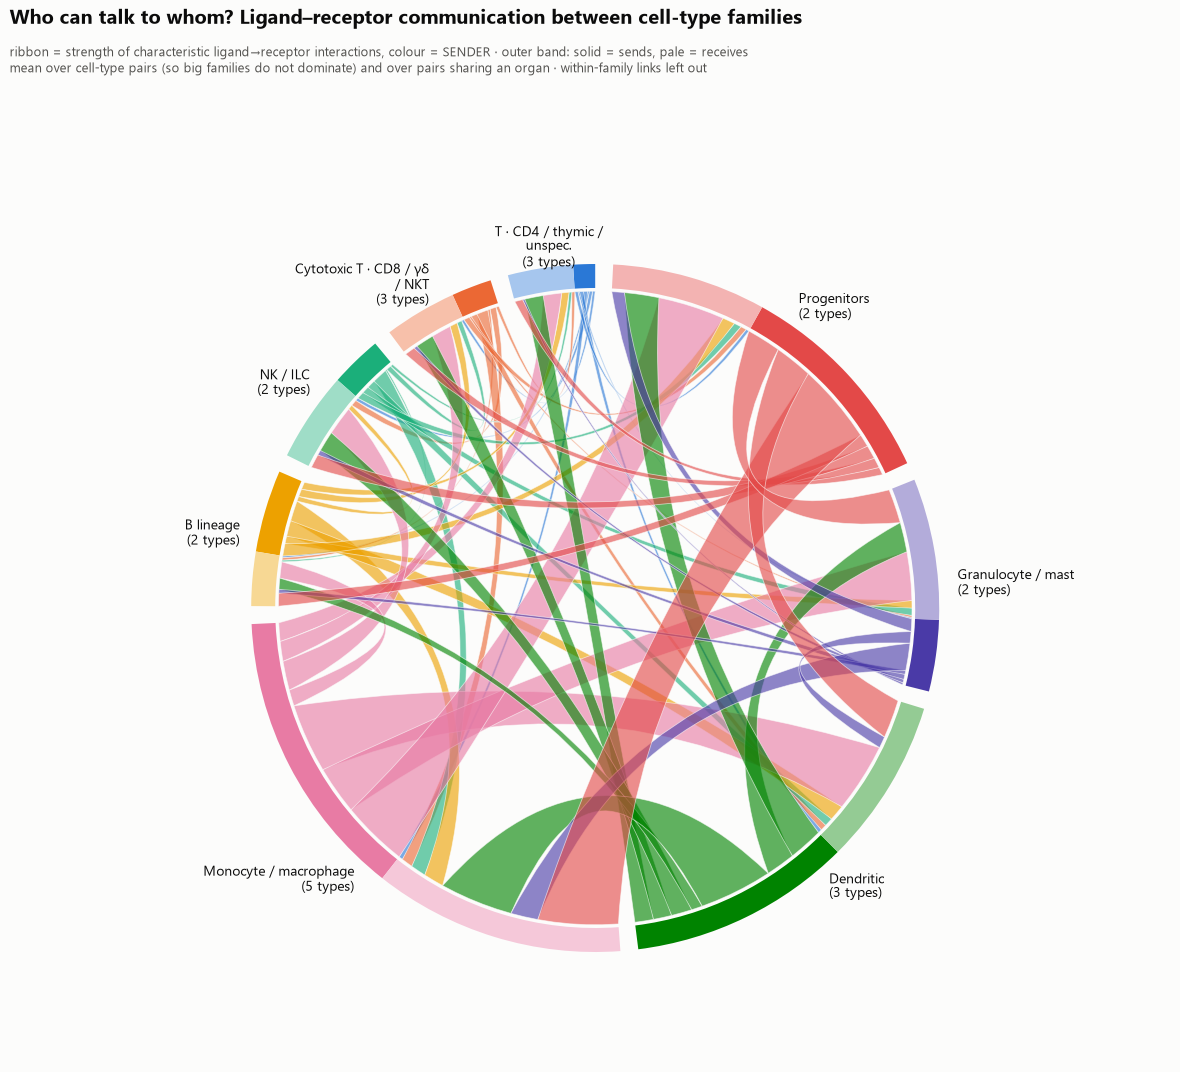

In [48]:
# F3 · chord diagram between the 8 families (who talks to whom, hub-corrected by averaging per cell-type pair)
def _arc(r, a0, a1):
    n = max(3, int(abs(a1 - a0) / 3) + 2); th = np.radians(np.linspace(a0, a1, n))
    return np.column_stack([r * np.cos(th), r * np.sin(th)])

def _ribbon(ax, a0, a1, b0, b1, r, color):
    p1, p2 = _arc(r, a0, a1), _arc(r, b0, b1)
    ma, mb = np.radians((a0 + a1) / 2), np.radians((b0 + b1) / 2)
    c = .18 * r * np.array([np.cos(ma) + np.cos(mb), np.sin(ma) + np.sin(mb)])
    verts = [tuple(v) for v in p1] + [tuple(c), tuple(p2[0])] + [tuple(v) for v in p2[1:]] + [tuple(c), tuple(p1[0])]
    codes = ([MPath.MOVETO] + [MPath.LINETO] * (len(p1) - 1) + [MPath.CURVE3] * 2 + [MPath.LINETO] * (len(p2) - 1) + [MPath.CURVE3] * 2)
    ax.add_patch(PathPatch(MPath(verts, codes), facecolor=color, edgecolor=SURF, lw=.6, alpha=.62, zorder=2))

def fig_F_chord(fname="F3_chord_family_talk.png"):
    nF = len(FAMILIES)
    M = np.zeros((nF, nF))
    for i, (_, _, mi) in enumerate(FAMILIES):
        for j, (_, _, mj) in enumerate(FAMILIES):
            if i == j:
                continue
            ok = shared_df.loc[mi, mj].to_numpy() > 0            # only pairs that co-occur in an organ
            v = s_char.loc[mi, mj].to_numpy()
            M[i, j] = v[ok].mean() if ok.any() else 0.0
    out_, in_ = M.sum(1), M.sum(0)
    gap = 3.0; scale = (360 - nF * gap) / (out_.sum() + in_.sum())
    fig, ax = plt.subplots(figsize=(12.5, 11.4)); ax.set_aspect("equal"); ax.axis("off")
    R, W = 1.0, .075
    start = 90.0; seg = {}
    for i in range(nF):
        a = start; o = {}; inn = {}
        for j in range(nF):
            if j != i:
                o[j] = (a, a + M[i, j] * scale); a += M[i, j] * scale
        a_out_end = a
        for j in range(nF):
            if j != i:
                inn[j] = (a, a + M[j, i] * scale); a += M[j, i] * scale
        seg[i] = dict(out=o, inn=inn, span=(start, a), out_end=a_out_end)
        start = a + gap
    for i, j in [(i, j) for i in range(nF) for j in range(nF) if i != j and M[i, j] > 0]:
        a0, a1 = seg[i]["out"][j]; b0, b1 = seg[j]["inn"][i]
        _ribbon(ax, a0, a1, b0, b1, R - .01, FAMILIES[i][1])
    for i, (name, col, members) in enumerate(FAMILIES):
        s0, s1 = seg[i]["span"]; so = seg[i]["out_end"]
        ax.add_patch(Wedge((0, 0), R + W, s0, so, width=W, color=col, lw=0, zorder=3))
        light = np.array(mpl.colors.to_rgb(col)) * .42 + .58
        ax.add_patch(Wedge((0, 0), R + W, so, s1, width=W, color=light, lw=0, zorder=3))
        mid = np.radians((s0 + s1) / 2); rr = R + W + .06
        lab = "\n".join(textwrap.wrap(name, 22))
        ax.text(rr * np.cos(mid), rr * np.sin(mid), f"{lab}\n({len(members)} types)", fontsize=10.5, color=INK, va="center",
                ha="left" if np.cos(mid) > .15 else "right" if np.cos(mid) < -.15 else "center", linespacing=1.15)
    ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.42, 1.42)
    _title(fig, "Who can talk to whom? Ligand–receptor communication between cell-type families",
           "ribbon = strength of characteristic ligand→receptor interactions, colour = SENDER · outer band: solid = sends, pale = receives\n"
           "mean over cell-type pairs (so big families do not dominate) and over pairs sharing an organ · within-family links left out",
           x=0.012, y=0.985, fig=fig)
    fig.subplots_adjust(left=.02, right=.98, top=.865, bottom=.01)
    fig.savefig(OUT / fname, dpi=150); plt.show()
    return M

M_fam = fig_F_chord()

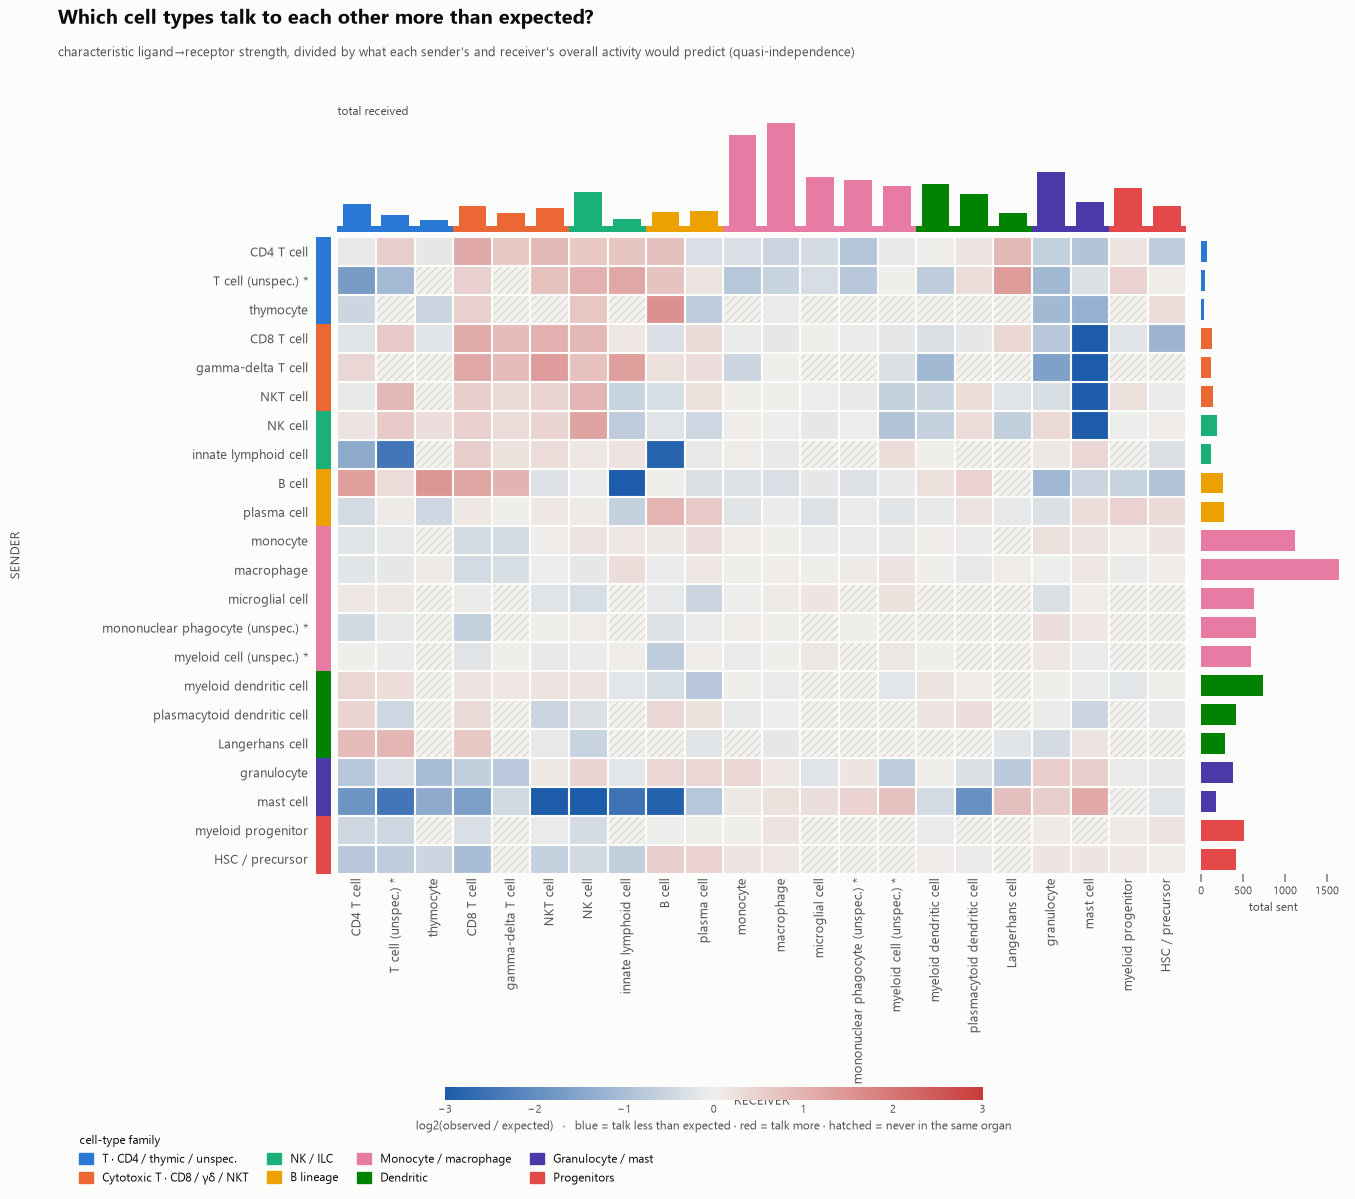

In [49]:
# F4 · sender x receiver: observed vs expected (removes the "everything talks to macrophages" hub effect)
def _ipf(O, valid, it=200):
    rs, cs = np.nansum(O, 1), np.nansum(O, 0)
    a, b = np.ones(len(rs)), np.ones(len(cs))
    for _ in range(it):
        a = rs / np.maximum((valid * b).sum(1), 1e-12); b = cs / np.maximum((valid * a[:, None]).sum(0), 1e-12)
    return np.outer(a, b) * valid

def fig_F_matrix(fname="F4_sender_receiver_obs_vs_expected.png"):
    n = len(FAM_ORDER)
    valid = (shared_df.loc[FAM_ORDER, FAM_ORDER].to_numpy() > 0).astype(float)
    O = np.where(valid > 0, s_char.loc[FAM_ORDER, FAM_ORDER].to_numpy(), np.nan)
    Ex = _ipf(np.nan_to_num(O), valid)
    eps = .02 * np.nanmean(O[valid > 0])
    R = np.log2((np.nan_to_num(O) + eps) / (Ex + eps)); R = np.clip(R, -3, 3); R[valid == 0] = np.nan
    fig = plt.figure(figsize=(14, 12.6))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, .17], height_ratios=[.17, 1], hspace=.03, wspace=.03,
                          left=.22, right=.97, top=.895, bottom=.27)
    ax, axt, axr = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 1])
    cm = DIV.copy(); cm.set_bad("#f3f2ee")
    im = ax.imshow(np.ma.masked_invalid(R), cmap=cm, vmin=-3, vmax=3, aspect="auto")
    for i in range(n):
        for j in range(n):
            if valid[i, j] == 0:
                ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False, hatch="////", edgecolor="#d9d8d2", lw=0))
    ax.set_xticks(range(n)); ax.set_xticklabels([DISP[t] for t in FAM_ORDER], rotation=90, fontsize=9.5)
    ax.set_yticks(range(n)); ax.set_yticklabels([DISP[t] for t in FAM_ORDER], fontsize=9.5)
    ax.set_xticks(np.arange(-.5, n), minor=True); ax.set_yticks(np.arange(-.5, n), minor=True)
    ax.grid(which="minor", color=SURF, lw=1.6); ax.tick_params(which="both", length=0); ax.tick_params(axis="y", pad=22)
    ax.spines[["left", "bottom"]].set_visible(False)
    ax.set_xlabel("RECEIVER", fontsize=10, color=INK2, labelpad=8); ax.set_ylabel("SENDER", fontsize=10, color=INK2, labelpad=60)
    for i, t in enumerate(FAM_ORDER):
        ax.add_patch(Rectangle((-1.05, i - .5), .38, 1, color=FAM_COL[t], clip_on=False, lw=0))
        ax.add_patch(Rectangle((i - .5, -1.05), 1, .38, color=FAM_COL[t], clip_on=False, lw=0))
    sent, recv = np.nansum(O, 1), np.nansum(O, 0)
    axr.barh(range(n), sent, color=[FAM_COL[t] for t in FAM_ORDER], height=.72); axr.set_ylim(n - .5, -.5)
    axt.bar(range(n), recv, color=[FAM_COL[t] for t in FAM_ORDER], width=.72); axt.set_xlim(-.5, n - .5)
    for a_ in (axr, axt):
        a_.set_xticks([]) if a_ is axt else a_.set_yticks([]); a_.spines[["left", "bottom"]].set_visible(False)
        a_.tick_params(labelsize=8)
    axt.set_yticks([]); axt.set_xticks([]); axr.set_xlabel("total sent", fontsize=9)
    axt.set_title("total received", fontsize=9, color=INK2, loc="left", pad=2)
    cax = fig.add_axes([0.30, 0.083, 0.40, 0.011])
    cb = fig.colorbar(im, cax=cax, orientation="horizontal"); cb.outline.set_visible(False); cax.tick_params(labelsize=8.5, length=0)
    cb.set_label("log2(observed / expected)   ·   blue = talk less than expected · red = talk more · hatched = never in the same organ", fontsize=9, color=INK2)
    _title(fig, "Which cell types talk to each other more than expected?",
           "characteristic ligand→receptor strength, divided by what each sender's and receiver's overall activity would predict (quasi-independence)",
           x=0.012, y=0.985, fig=fig)
    _family_legend(fig, y=0.004, ncol=4)
    fig.savefig(OUT / fname, dpi=150); plt.show()

fig_F_matrix()

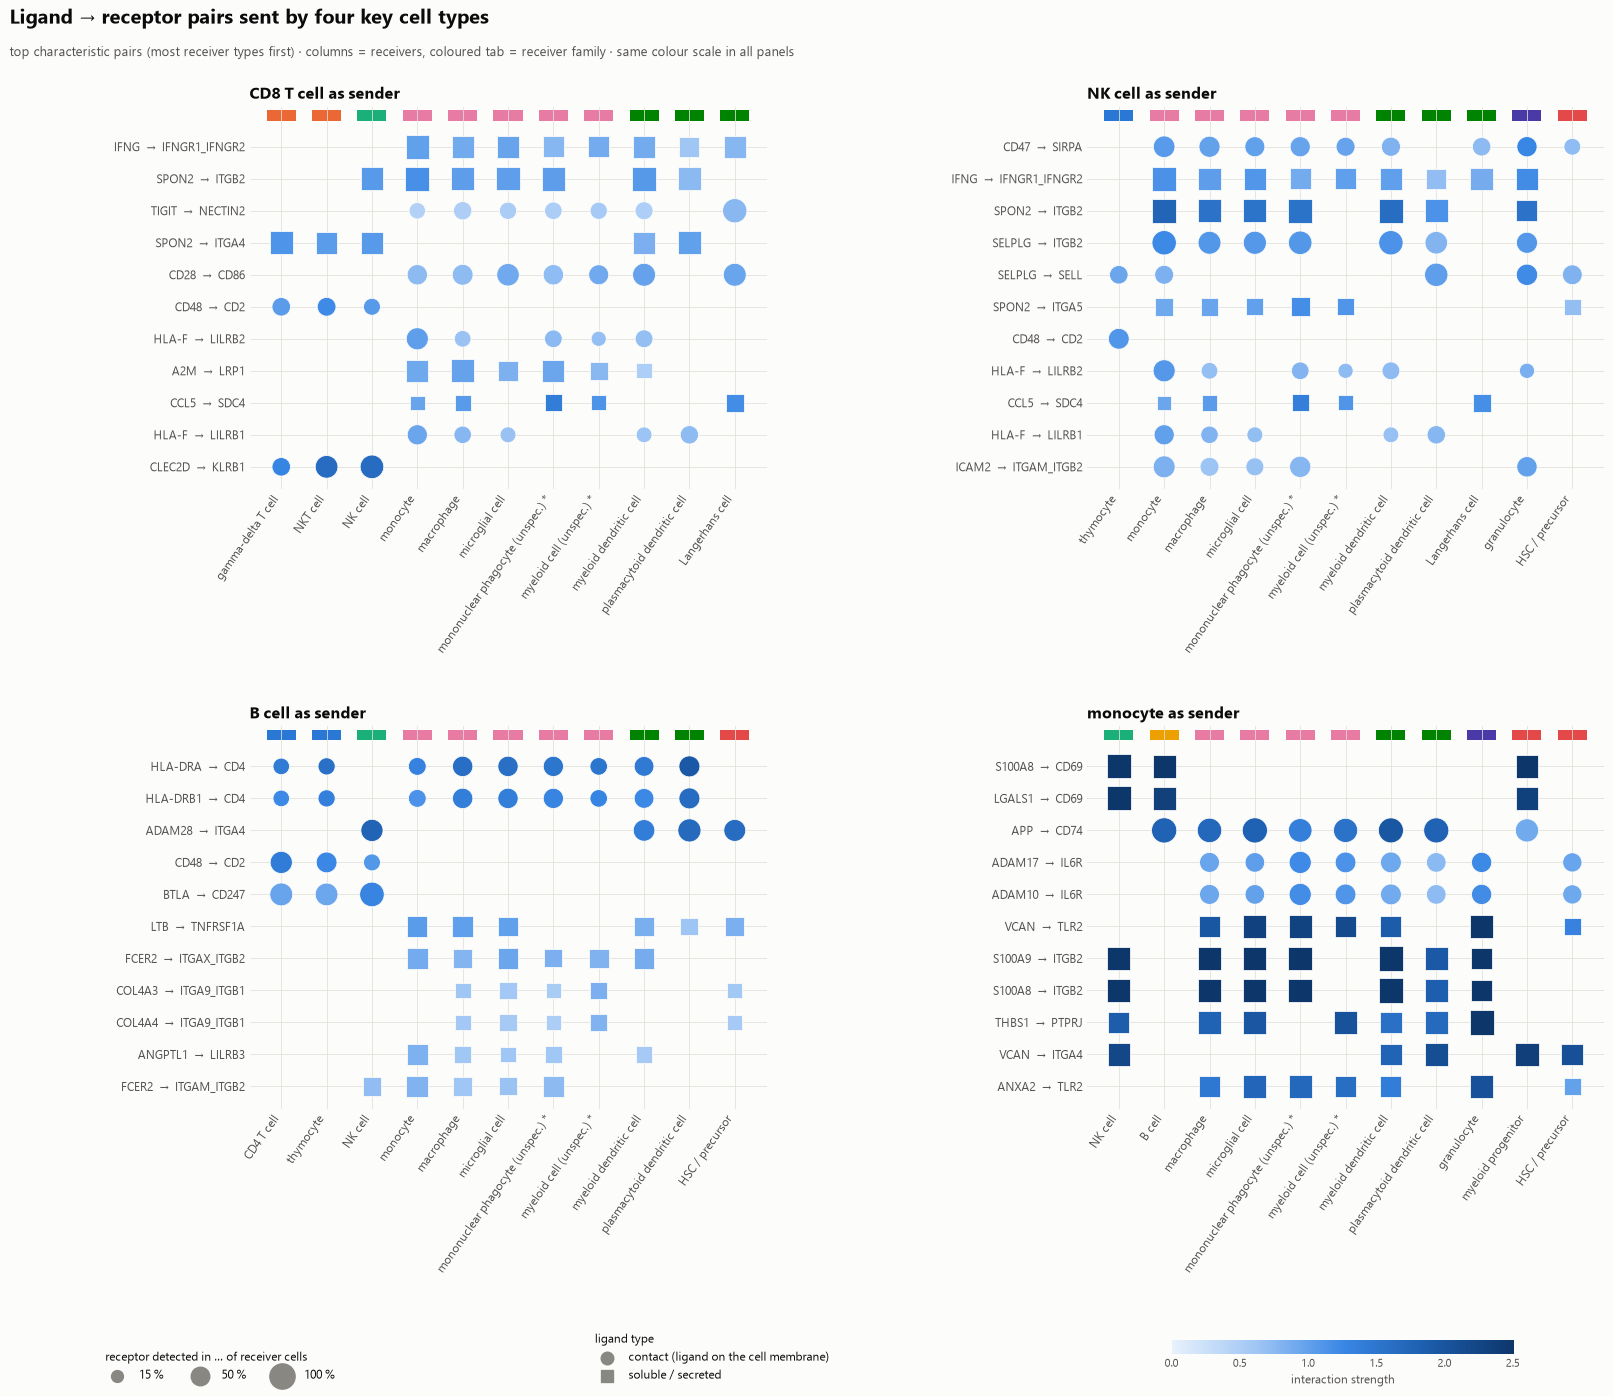

In [50]:
# F5 · ligand -> receptor dot plots for four focus cell types (as SENDER): which pairs, towards which receivers
FOCUS_LR = ["CD8 T cell", "NK cell", "B cell", "monocyte"]
def _lr_panel(ax, t, vmax, n_pairs=11, n_recv=11):
    d = ch[(ch.sender == t) & (ch.receiver != t)].copy()
    d["lab"] = d["ligand"] + "  →  " + d["receptor"]
    cand = (d.groupby("lab").agg(n=("receiver", "nunique"), s=("strength", "max"), mode=("mode", "first"),
                                 lig=("ligand", "first"), rec=("receptor", "first"))
              .sort_values(["n", "s"], ascending=False))
    keep, cl, cr = [], {}, {}
    for lab, r in cand.iterrows():                    # at most 2 pairs per ligand and per receptor -> less redundancy
        if cl.get(r.lig, 0) >= 2 or cr.get(r.rec, 0) >= 2:
            continue
        keep.append(lab); cl[r.lig] = cl.get(r.lig, 0) + 1; cr[r.rec] = cr.get(r.rec, 0) + 1
        if len(keep) == n_pairs:
            break
    agg = cand.loc[keep]
    dd = d[d.lab.isin(agg.index)]
    recv = dd.groupby("receiver").size().sort_values(ascending=False).head(n_recv).index
    recv = [r for r in FAM_ORDER if r in set(recv)]
    labs = list(agg.index)
    for mode, mk_ in (("membrane", "o"), ("soluble", "s")):
        x = dd[(dd["mode"] == mode) & dd.receiver.isin(recv)]
        ax.scatter([recv.index(r) for r in x.receiver], [labs.index(l) for l in x.lab], s=30 + 330 * x["pct_R"].clip(upper=1),
                   c=x["strength"], cmap=SEQ, vmin=0, vmax=vmax, marker=mk_, edgecolor=SURF, lw=.6, zorder=3)
    ax.set_xlim(-.7, len(recv) - .3); ax.set_ylim(len(labs) - .3, -1.25)
    ax.set_xticks(range(len(recv))); ax.set_xticklabels([DISP[r] for r in recv], rotation=55, ha="right", fontsize=9)
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=9)
    ax.tick_params(length=0); ax.spines[["left", "bottom"]].set_visible(False); ax.grid(color=GRID, lw=.6, zorder=0)
    for k, r in enumerate(recv):
        ax.add_patch(Rectangle((k - .32, -1.15), .64, .34, color=FAM_COL[r], lw=0))
    ax.set_title(f"{DISP[t]} as sender", loc="left", fontsize=12, fontweight="bold", color=INK, pad=6)

def fig_F_lr_dotplots(fname="F5_lr_dotplots_focus_types.png"):
    vmax = ch[ch.sender.isin(FOCUS_LR)]["strength"].quantile(.98)
    fig, axs = plt.subplots(2, 2, figsize=(17, 14.6))
    for ax, t in zip(axs.ravel(), FOCUS_LR):
        _lr_panel(ax, t, vmax)
    sm = plt.cm.ScalarMappable(cmap=SEQ, norm=mpl.colors.Normalize(0, vmax))
    cax = fig.add_axes([0.72, 0.035, 0.21, 0.010]); cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cb.set_label("interaction strength", fontsize=9, color=INK2); cb.outline.set_visible(False); cax.tick_params(labelsize=8, length=0)
    hs = [plt.scatter([], [], s=30 + 330 * p_, color="#898781") for p_ in (.15, .5, 1.)]
    hm = [plt.scatter([], [], s=90, color="#898781", marker="o"), plt.scatter([], [], s=90, color="#898781", marker="s")]
    fig.legend(hs, ["15 %", "50 %", "100 %"], loc="lower left", bbox_to_anchor=(0.06, 0.008), ncol=3, frameon=False, fontsize=9,
               title="receptor detected in … of receiver cells", title_fontsize=9, alignment="left")
    fig.legend(hm, ["contact (ligand on the cell membrane)", "soluble / secreted"], loc="lower left", bbox_to_anchor=(0.36, 0.008),
               ncol=1, frameon=False, fontsize=9, title="ligand type", title_fontsize=9, alignment="left")
    _title(fig, "Ligand → receptor pairs sent by four key cell types",
           "top characteristic pairs (most receiver types first) · columns = receivers, coloured tab = receiver family · same colour scale in all panels",
           x=0.008, y=0.995, fig=fig)
    fig.subplots_adjust(left=.155, right=.985, top=.925, bottom=.21, hspace=.62, wspace=.62)
    fig.savefig(OUT / fname, dpi=140); plt.show()

fig_F_lr_dotplots()

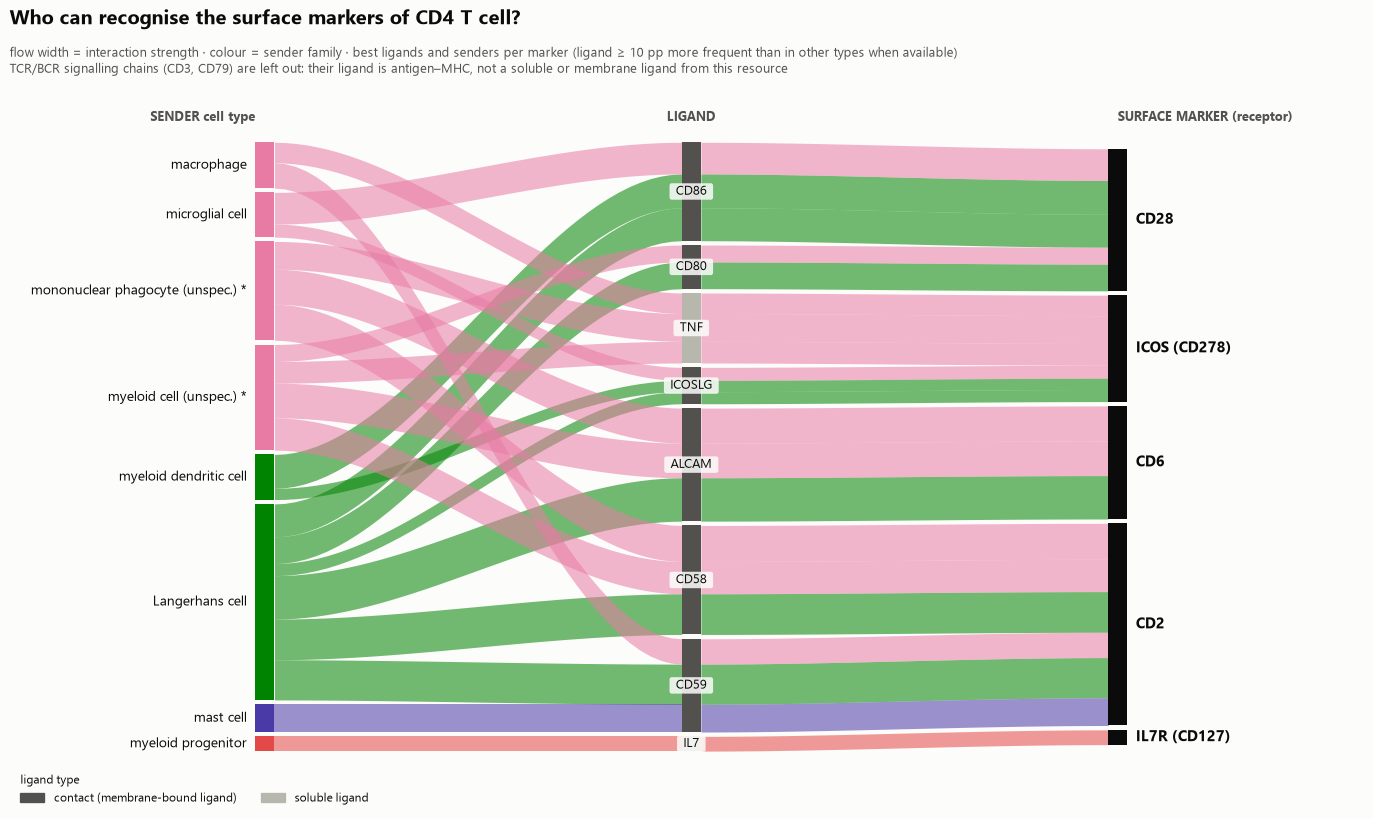

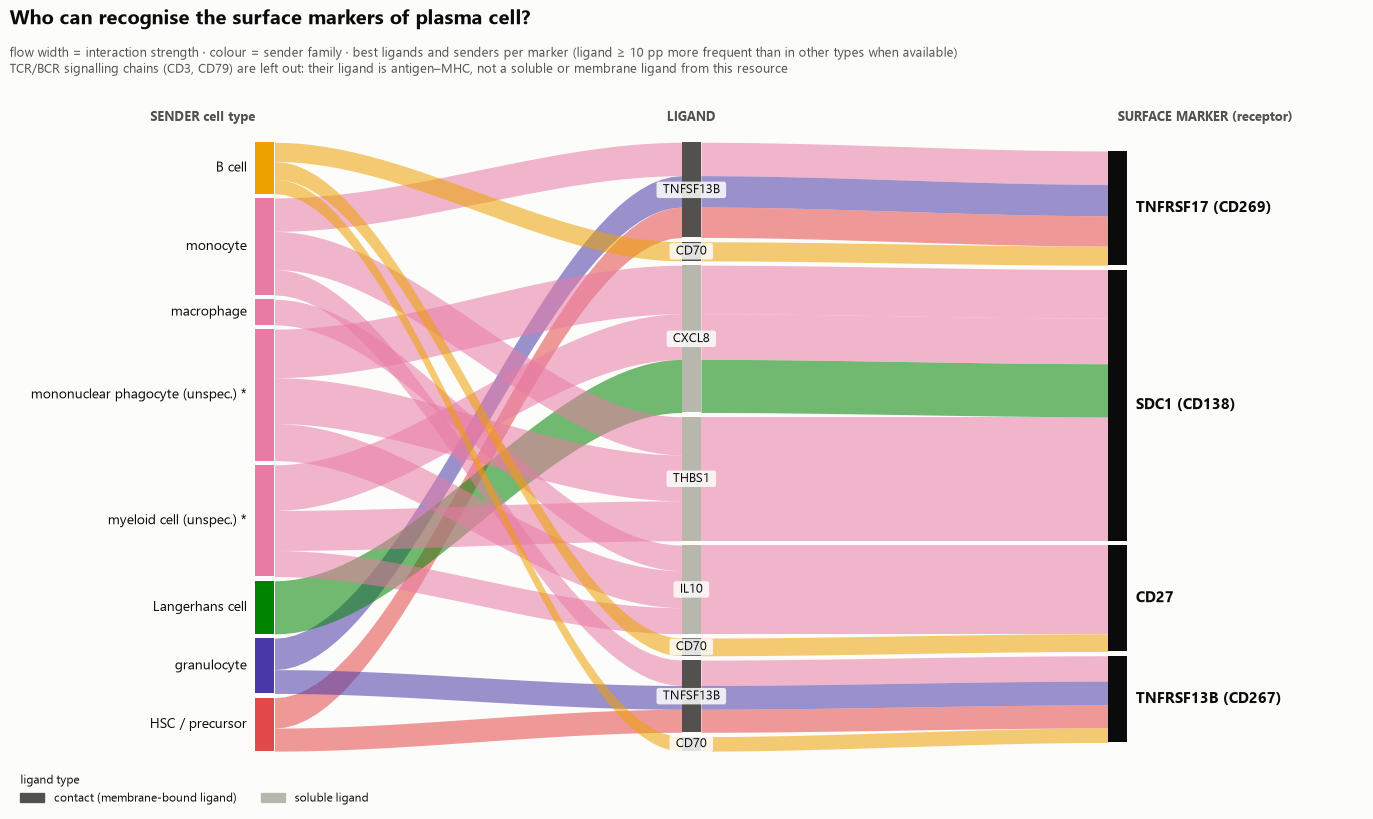

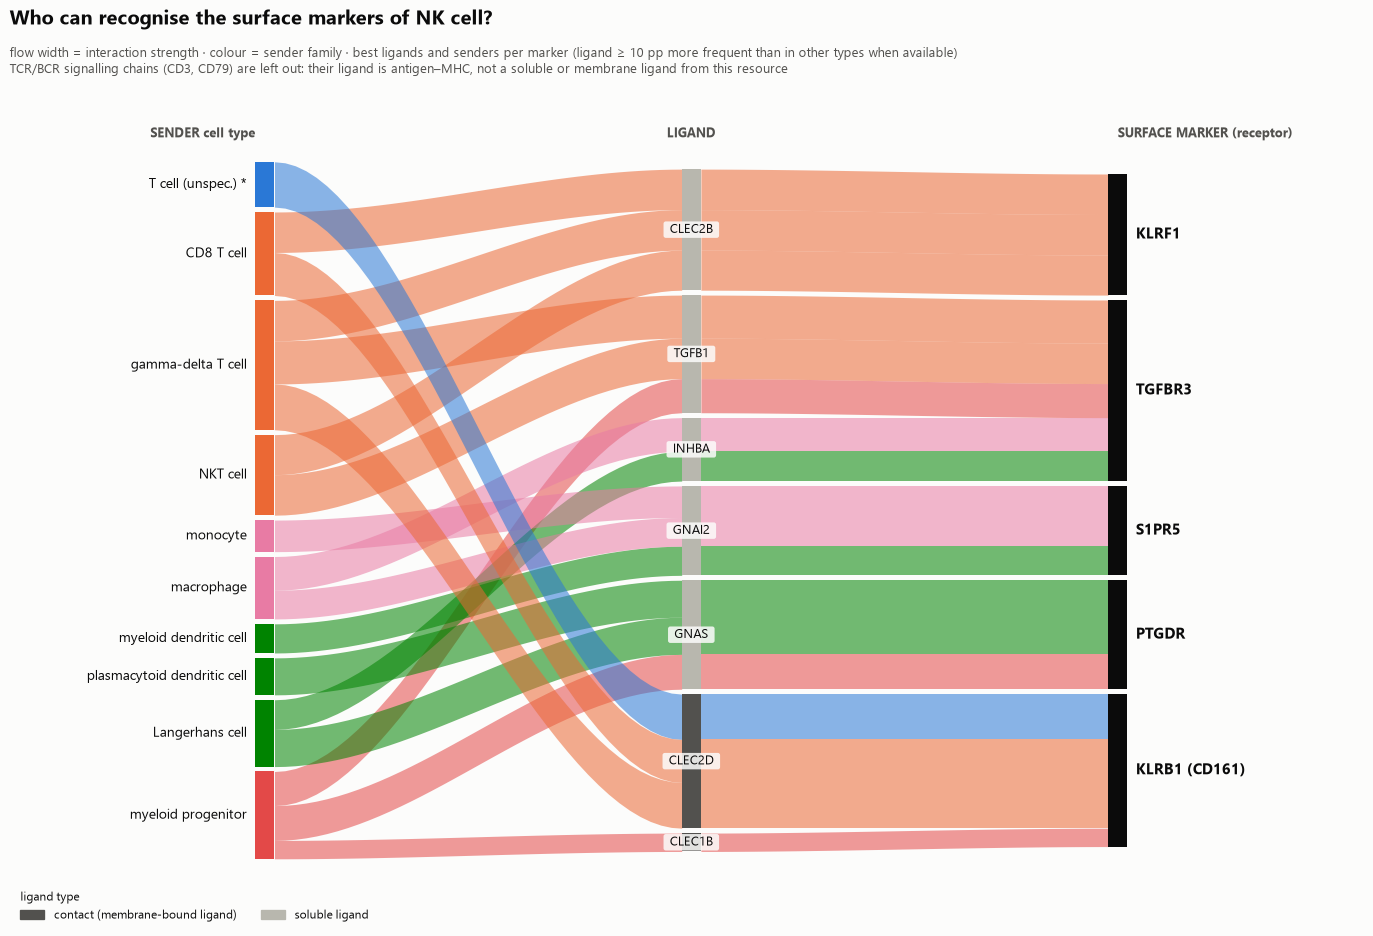

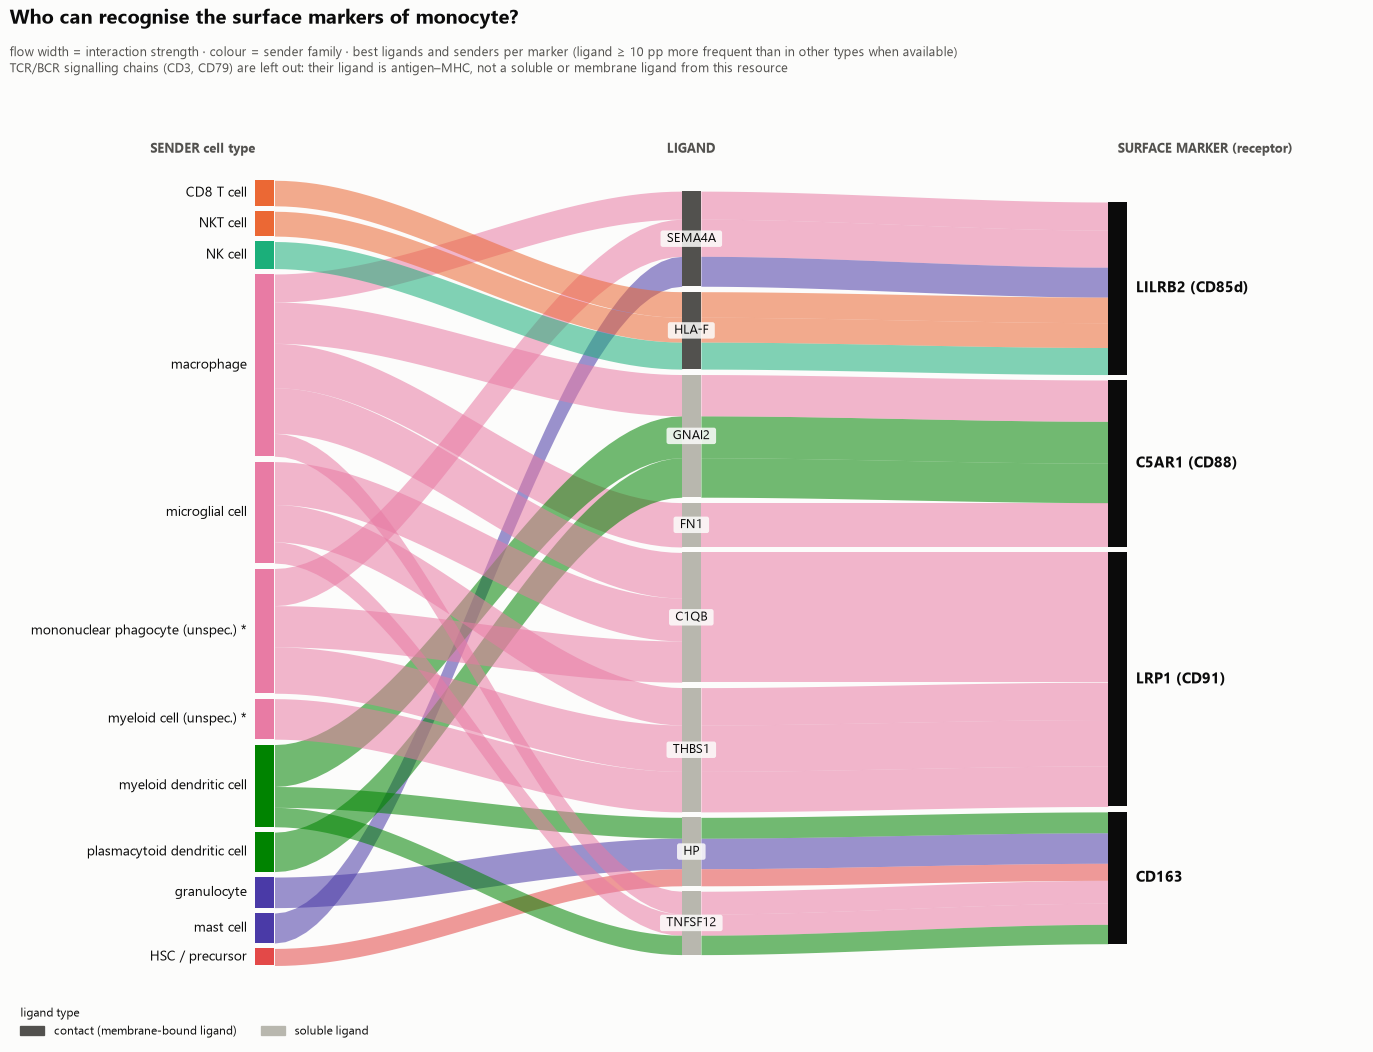

In [51]:
# F6 · alluvial (Sankey) — senders -> ligand -> the surface marker (receptor) of a focus cell type
def _bez(x0, x1, ya, yb, h, ax, color, alpha=.55):
    u = np.linspace(0, 1, 40); s = 3 * u ** 2 - 2 * u ** 3
    x = x0 + (x1 - x0) * u; top = ya + (yb - ya) * s
    ax.fill_between(x, top, top + h, color=color, alpha=alpha, lw=0, zorder=2)

def fig_F_alluvial(t, n_markers=5, n_lig=2, n_send=3, fname=None):
    d = inter[(inter.receiver == t) & (inter.sender != t)]
    tm = top_mk[top_mk.celltype == t].sort_values("rank")
    paths = []
    for _, m in tm.iterrows():
        g = m["gene"]
        if g in {"CD3D", "CD3E", "CD3G", "CD247", "CD79A", "CD79B"}:      # TCR/BCR signalling chains: ligand = peptide-MHC / antigen
            continue
        dm = d[d.receptor.str.split("_").apply(lambda l: g in l)]
        if dm.empty:
            continue
        dm2 = dm[dm.spec_L >= .10]; dm = dm2 if len(dm2) else dm
        ligs = dm.groupby("ligand")["strength"].max().sort_values(ascending=False).head(n_lig).index
        for l in ligs:
            for _, r in dm[dm.ligand == l].sort_values("strength", ascending=False).head(n_send).iterrows():
                paths.append(dict(marker=g, ligand=l, sender=r["sender"], v=r["strength"], mode=r["mode"]))
        if len({p["marker"] for p in paths}) >= n_markers:
            break
    if not paths:
        print("no flows for", t); return
    P = pd.DataFrame(paths)
    mk_order = list(dict.fromkeys(P.marker)); P["mi"] = P.marker.map(mk_order.index)
    lig_key = P.groupby(["mi", "ligand"])["v"].sum().reset_index().sort_values(["mi", "v"], ascending=[True, False])
    lig_order = [(a, b) for a, b in zip(lig_key.mi, lig_key.ligand)]
    P["li"] = [lig_order.index((a, b)) for a, b in zip(P.mi, P.ligand)]
    send_order = [s for s in FAM_ORDER if s in set(P.sender)]; P["si"] = P.sender.map(send_order.index)
    gap = .045 * P["v"].sum() / 6

    def place(col, key_nodes, node_of, sortkey):
        y, nodes, off = 0.0, {}, {}
        for nd in key_nodes:
            sub = P[node_of == nd].sort_values(sortkey); y0 = y
            for i, r in sub.iterrows():
                off[i] = y; y += r["v"]
            nodes[nd] = (y0, y); y += gap
        return nodes, off
    nS, oS = place(0, range(len(send_order)), P["si"], ["li", "mi", "si"])
    nL, oL = place(1, range(len(lig_order)), P["li"], ["mi", "si"])
    nM, oM = place(2, range(len(mk_order)), P["mi"], ["li", "si"])
    H = max(nS[max(nS)][1], nL[max(nL)][1], nM[max(nM)][1])
    fig, ax = plt.subplots(figsize=(14.5, 0.62 * len(send_order) + 3.6))
    xs = [0.0, 1.0, 2.0]; nw = .045
    for i, r in P.iterrows():
        c = FAM_COL[r["sender"]]
        cS = (H - nS[max(nS)][1]) / 2; cL = (H - nL[max(nL)][1]) / 2; cM = (H - nM[max(nM)][1]) / 2
        _bez(xs[0] + nw, xs[1], oS[i] + cS, oL[i] + cL, r["v"], ax, c)
        _bez(xs[1] + nw, xs[2], oL[i] + cL, oM[i] + cM, r["v"], ax, c)
    cS = (H - nS[max(nS)][1]) / 2; cL = (H - nL[max(nL)][1]) / 2; cM = (H - nM[max(nM)][1]) / 2
    for k, s in enumerate(send_order):
        y0, y1 = nS[k]; ax.add_patch(Rectangle((xs[0], y0 + cS), nw, y1 - y0, color=FAM_COL[s], lw=0, zorder=3))
        ax.text(xs[0] - .02, (y0 + y1) / 2 + cS, DISP[s], ha="right", va="center", fontsize=10.5, color=INK)
    for k, (mi, l) in enumerate(lig_order):
        y0, y1 = nL[k]; mode = P[P.ligand == l]["mode"].iloc[0]
        ax.add_patch(Rectangle((xs[1], y0 + cL), nw, y1 - y0, color="#52514e" if mode == "membrane" else "#b8b7ae", lw=0, zorder=3))
        ax.text(xs[1] + nw / 2, (y0 + y1) / 2 + cL, f" {l} ", ha="center", va="center", fontsize=9.5, color=INK, zorder=4,
                bbox=dict(boxstyle="round,pad=0.18", fc=SURF, ec="none", alpha=.85))
    for k, g in enumerate(mk_order):
        y0, y1 = nM[k]; ax.add_patch(Rectangle((xs[2], y0 + cM), nw, y1 - y0, color=INK, lw=0, zorder=3))
        ax.text(xs[2] + nw + .02, (y0 + y1) / 2 + cM, _glabel(g), ha="left", va="center", fontsize=11, fontweight="bold", color=INK)
    for x_, lab in zip(xs, ["SENDER cell type", "LIGAND", "SURFACE MARKER (receptor)"]):
        ax.text(x_ + (nw if x_ else 0) / 2, -H * .035, lab, ha="left" if x_ == 2 else "center" if x_ == 1 else "right",
                fontsize=9.5, color=INK2, fontweight="bold")
    ax.set_xlim(-.55, 2.6); ax.set_ylim(H * 1.03, -H * .07); ax.axis("off")
    hs = [Rectangle((0, 0), 1, 1, color="#52514e"), Rectangle((0, 0), 1, 1, color="#b8b7ae")]
    fig.legend(hs, ["contact (membrane-bound ligand)", "soluble ligand"], loc="lower left", bbox_to_anchor=(0.012, 0.004), ncol=2,
               frameon=False, fontsize=9, title="ligand type", title_fontsize=9, alignment="left")
    _title(fig, f"Who can recognise the surface markers of {DISP[t]}?",
           "flow width = interaction strength · colour = sender family · best ligands and senders per marker (ligand ≥ 10 pp more frequent than in other types when available)\n"
           "TCR/BCR signalling chains (CD3, CD79) are left out: their ligand is antigen–MHC, not a soluble or membrane ligand from this resource",
           x=0.012, y=0.985, fig=fig)
    fig.subplots_adjust(left=.02, right=.985, top=.875, bottom=.06)
    fname = fname or f"F6_alluvial_{t.replace(' ', '_').replace('/', '-')}.png"
    fig.savefig(OUT / fname, dpi=150); plt.show()

for _t in ["CD4 T cell", "plasma cell", "NK cell", "monocyte"]:
    fig_F_alluvial(_t)

## Outputs written to `processing/out_tabula_mito/`

| file | content |
|---|---|
| `S1_tabula_overview.png` · `S1b_group_matrix.png` | dataset census: organ / cell-type / assay / donor×organ; organ×cell-type group matrix |
| `S2_pathway_sizes_overlap.png` | pathway sizes (MitoCarta vs measured) + shared-gene heatmap |
| `pathway_coverage.csv` | n genes per pathway (MitoCarta vs measured) |
| `A_group_mean_log1p.csv` | mean log1p per organ×cell-type group × 1138 mito genes |
| `A_pathway_scores_by_group.csv` | 9 scores + overall + metadata/flags per group |
| `A1_pathway_correlation.{csv,png}` · `A1b_group_clustermap.png` | pathway–pathway correlation, groups × pathways (Part A) |
| `A2_overall_distribution.png` · `A2b_pathway_distributions.png` | overall score distribution; per-pathway histograms |
| `A3_top25_groups.csv` · `A3b_top25_heatmap.png` | **top 25** organ×cell-type groups: table + heatmap |
| `A4_crossorgan_SD_by_lineage.{csv,png}` | SD of the same cell type across organs, per pathway |
| `B_pseudobulk_log1p.csv` / `B_celltype_meta.csv` | pseudobulk per collapsed cell type |
| `B_pathway_scores_by_celltype.csv` | 9 scores + overall per cell type |
| `B1_pathway_correlation.{csv,png}` · `B1b_celltype_clustermap.png` | correlation / clustering (Part B) |
| `B2_overall_distribution.png` · `B2b_pathway_spread.png` | distribution; per-pathway spread across cell types |
| `B3_top25_celltypes.csv` · `B3b_celltype_heatmap.png` | **top 25** cell types: table + heatmap |
| `B4_variable_mito_genes.{csv,png}` | most variable mitochondrial genes across cell types |
| `C_donor_pathway_scores.csv` | per-donor pseudobulk: 9 scores + overall + organ/cell-type mix |
| `C1_donor_pathway_heatmap.png` | donor × pathway intensity, best donor highlighted |
| `C2_best_donor.png` | best donor pathway bars + donor × organ composition |
| `D1_full_ranked_overall.png` | overall score, ranked, for **every** group (Part A, n=339) and cell type (Part B, n=22) — no top-25 cut |
| `D2_variable_mito_genes_groups.csv` / `D2_full_gene_heatmap_groups.png` | most variable mito genes across all groups; gene x group z-score heatmap (all 339 groups, sorted by overall) |
| `D3_full_gene_clustermap_celltypes.png` | gene x cell-type clustermap, all 22 pseudobulk cell types, row color = overall score |
| `D4_high_overall_groups.csv` / `D4_high_overall_celltypes.csv` | **every** group / cell type above the mean+1SD cut (not capped at 25) |
| `E_surface_gene_stats_all.csv.gz` | every surface gene x 22 cell types: pct_in/out, log2FC, n_types_pos, specificity, CD number, SURFY class |
| `E_markers_per_celltype.csv` · `E_top_markers_per_celltype.csv` · `E_marker_summary_table.csv` | **surface markers** passing the filters (ranked) · top 10 per type · one-line summary per type |
| `E1_surface_marker_dotplot.png` · `E2_marker_counts_by_specificity.png` | dot plot of top-3 markers x 22 types; # markers per type (unique / restricted / shared) |
| `stream_surface.npz` | cache of streaming pass #2 (sum of counts + detection per organ x cell-type group, surfaceome ∪ L-R genes) |
| `F_interactions_all.csv.gz` | every active sender->receiver x ligand-receptor interaction (shared organ required), strength, specificity, mode |
| `F_sender_receiver_{all_active,characteristic,characteristic_strength}.csv` · `F1_sender_receiver_matrices.png` | 22x22 sender/receiver matrices |
| `F_partners_per_celltype.csv` · `F2_network_top_partners.png` | who each cell type talks to / listens to + characteristic L-R pairs · network of the 2 strongest partners |
| `F_marker_partners.csv` | top surface markers that are ligands/receptors -> counterpart gene and partner cell types |
| `E3_marker_dotplot_by_family.png` | **figure E-1** dot plot: 2 best surface markers per cell type, rows grouped by family |
| `E4_marker_discrimination_small_multiples.png` | **figure E-2** one panel per cell type: log2FC vs Δ% cells for every surface gene, marker exclusivity coloured |
| `E5_marker_sharing_matrix.png` | **figure E-3** number of shared surface markers between cell types (Jaccard) |
| `F3_chord_family_talk.png` | **figure F-1** chord diagram of ligand-receptor communication between the 8 families |
| `F4_sender_receiver_obs_vs_expected.png` | **figure F-2** sender x receiver log2(observed/expected) with total sent/received bars (hub effect removed) |
| `F5_lr_dotplots_focus_types.png` | **figure F-3** ligand->receptor dot plots for CD8 T, NK, B, monocyte as senders |
| `F6_alluvial_{CD4_T_cell,plasma_cell,NK_cell,monocyte}.png` | **alluvial**: sender -> ligand -> surface marker (receptor) of the focus cell type |